# Evaluate and calibrate models

This notebook loads completed training runs, runs validation/test evaluation, fits temperature scaling on the
validation split, and writes evaluation metrics/plots back to each run directory.


In [1]:
import sys
from pathlib import Path

# Prefer local src/ over any installed package to ensure using the local code.
sys.path.insert(0, str((Path("..").resolve() / "src")))

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

from config import TrainConfig
from data.datamodule import DataModule
from models.builder import build_model
from validation import evaluate, reliability_bins
from validation.calibration import TemperatureScaler

RUNS_ROOT = Path("../training_runs")
RUNS_ROOT.mkdir(exist_ok=True)

# Leave None to auto-pick the most recent training session (prefix before _<modelname>), or set explicitly.
SESSION_TAG = None

EXPERIMENTS = {
    "resnet18": {},
    "resnet34": {},
    "resnet50": {},
    "efficientnet_b1": {},
    "efficientnet_b2": {},
    "convnext_tiny": {},
    "convnext_small": {},
    "custom_cnn": {},
}

def resolve_session_tag():
    if SESSION_TAG:
        return SESSION_TAG
    candidates = []
    for exp in EXPERIMENTS:
        for path in RUNS_ROOT.glob(f"*_{exp}"):
            prefix = path.name[: -len(f"_{exp}")]
            candidates.append((path.stat().st_mtime, prefix))
    if not candidates:
        raise FileNotFoundError("No training runs found. Set SESSION_TAG manually if needed.")
    candidates.sort()
    return candidates[-1][1]

SESSION_PREFIX = resolve_session_tag()
print(f"Evaluating session prefix: {SESSION_PREFIX}")

Evaluating session prefix: resampled_20251206-154401


In [3]:
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

PLOTS_DIR = None  # set per run


def set_plot_dir(path: Path):
    global PLOTS_DIR
    PLOTS_DIR = path
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    return PLOTS_DIR


def save_fig(fig, name: str, prefix: str = "eval"):
    assert PLOTS_DIR is not None, "PLOTS_DIR not set; call set_plot_dir(...) first."
    path = PLOTS_DIR / f"{prefix}_{name}.pdf"
    fig.savefig(path, bbox_inches="tight", format="pdf")
    print(f"Saved figure to {path}")
    return path


## Helper functions

Loads configs/checkpoints, evaluates on val/test, fits temperature scaling on validation logits, and logs plots.


In [4]:
from typing import Dict


def resolve_run_dir(exp_name: str, session_prefix: str) -> Path:
    run_dir = RUNS_ROOT / f"{session_prefix}_{exp_name}"
    if not run_dir.exists():
        raise FileNotFoundError(f"Run directory not found: {run_dir}")
    return run_dir


def load_config(run_dir: Path) -> TrainConfig:
    cfg_dict = json.loads((run_dir / "config.json").read_text())
    return TrainConfig(**cfg_dict)


def load_model(cfg: TrainConfig, ckpt_path: Path):
    model = build_model(cfg)
    state = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state["model_state"])
    return model


def build_loaders(cfg: TrainConfig):
    datamodule = DataModule(cfg)
    datamodule.setup()
    return datamodule.val_dataloader(), datamodule.test_dataloader(), datamodule.train_dataset.classes


def plot_metric_bars(split: str, tag: str, metrics: Dict, model_name: str):
    keys = [
        ("accuracy", "Accuracy"),
        ("macro_precision", "Macro Precision"),
        ("macro_recall", "Macro Recall"),
        ("macro_f1", "Macro F1"),
        ("brier", "Brier"),
        ("ece", "ECE"),
    ]
    values = []
    labels = []
    for key, label in keys:
        if key in metrics:
            labels.append(label)
            values.append(metrics[key])
    if not values:
        return
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    bars = ax.bar(labels, values, color=plt.get_cmap("tab10")(range(len(values))))
    ax.set_ylabel("Score")
    ax.set_ylim(bottom=0)
    ax.set_title(f"{model_name} | {split} ({tag}) metrics")
    ax.grid(axis="y", alpha=0.25)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, val, f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    plt.xticks(rotation=20)
    plt.tight_layout()
    save_fig(fig, f"{split}_{tag}_metrics")
    plt.show()


def plot_outputs(split: str, tag: str, outputs: Dict, class_names, cfg: TrainConfig, model_name: str):
    probs = outputs["probs"]
    labels = outputs["labels"].cpu().numpy()
    preds = probs.argmax(axis=1)

    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{model_name} | {split} Confusion ({tag})")
    fig.tight_layout()
    save_fig(fig, f"{split}_{tag}_confusion")
    plt.show()

    pos_scores = probs[:, 1] if probs.shape[1] > 1 else probs[:, 0]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for label_val, label_name in enumerate(class_names):
        ax.hist(pos_scores[labels == label_val], bins=20, alpha=0.6, label=label_name, density=True)
    ax.set_xlabel("Predicted probability (class 1)")
    ax.set_ylabel("Density")
    ax.set_title(f"{model_name} | {split} Score Histogram ({tag})")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    save_fig(fig, f"{split}_{tag}_score_hist")
    plt.show()

    bin_conf, bin_acc, bin_count = reliability_bins(probs, labels, n_bins=cfg.reliability_bins)
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
    ax.bar(bin_conf, bin_acc, width=1.0 / cfg.reliability_bins, alpha=0.65, align="center", label="Observed")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{model_name} | {split} Reliability ({tag})")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    save_fig(fig, f"{split}_{tag}_reliability")
    plt.show()


def evaluate_run(exp_name: str, session_prefix: str = SESSION_PREFIX, calibrate: bool = True, skip_if_exists: bool = True):
    run_dir = resolve_run_dir(exp_name, session_prefix)
    eval_metrics_path = run_dir / "eval_metrics.json"
    plots_dir = run_dir / "eval_plots"
    set_plot_dir(plots_dir)

    if skip_if_exists and eval_metrics_path.exists():
        print(f"Found existing eval metrics in {run_dir}, loading from disk.")
        return json.loads(eval_metrics_path.read_text())

    cfg = load_config(run_dir)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_name = cfg.model_name

    val_loader, test_loader, class_names = build_loaders(cfg)
    ckpt_path = run_dir / "artifacts" / "checkpoints" / "best.pt"
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    model = load_model(cfg, ckpt_path).to(device)

    val_metrics_raw, val_outputs_raw = evaluate(model, val_loader, device, cfg, temperature=None)
    plot_metric_bars("val", "raw", val_metrics_raw, model_name)
    plot_outputs("val", "raw", val_outputs_raw, class_names, cfg, model_name)

    test_metrics_raw, test_outputs_raw = evaluate(model, test_loader, device, cfg, temperature=None)
    plot_metric_bars("test", "raw", test_metrics_raw, model_name)
    plot_outputs("test", "raw", test_outputs_raw, class_names, cfg, model_name)

    eval_metrics = {
        "val_raw": val_metrics_raw,
        "test_raw": test_metrics_raw,
    }

    temperature_value = None
    if calibrate:
        temperature = TemperatureScaler().to(device)
        temperature.fit(val_outputs_raw["logits"].to(device), val_outputs_raw["labels"].to(device))
        temperature_value = float(temperature.temperature.item())

        val_metrics_cal, val_outputs_cal = evaluate(model, val_loader, device, cfg, temperature=temperature)
        plot_metric_bars("val", "calibrated", val_metrics_cal, model_name)
        plot_outputs("val", "calibrated", val_outputs_cal, class_names, cfg, model_name)

        test_metrics_cal, test_outputs_cal = evaluate(model, test_loader, device, cfg, temperature=temperature)
        plot_metric_bars("test", "calibrated", test_metrics_cal, model_name)
        plot_outputs("test", "calibrated", test_outputs_cal, class_names, cfg, model_name)

        temp_path = run_dir / "artifacts" / "temperature_eval.pt"
        temperature.save(str(temp_path))

        eval_metrics.update(
            {
                "val_calibrated": val_metrics_cal,
                "test_calibrated": test_metrics_cal,
                "temperature": temperature_value,
            }
        )

    eval_metrics_path.write_text(json.dumps(eval_metrics, indent=2))
    print(f"Saved eval metrics to {eval_metrics_path}")
    if temperature_value is not None:
        print(f"Fitted temperature: {temperature_value:.4f}")
    print("Test metrics (raw):", test_metrics_raw)
    if calibrate and "test_calibrated" in eval_metrics:
        print("Test metrics (calibrated):", eval_metrics["test_calibrated"])

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return eval_metrics


Saved figure to ../training_runs/resampled_20251206-154401_resnet18/eval_plots/eval_val_raw_confusion.pdf


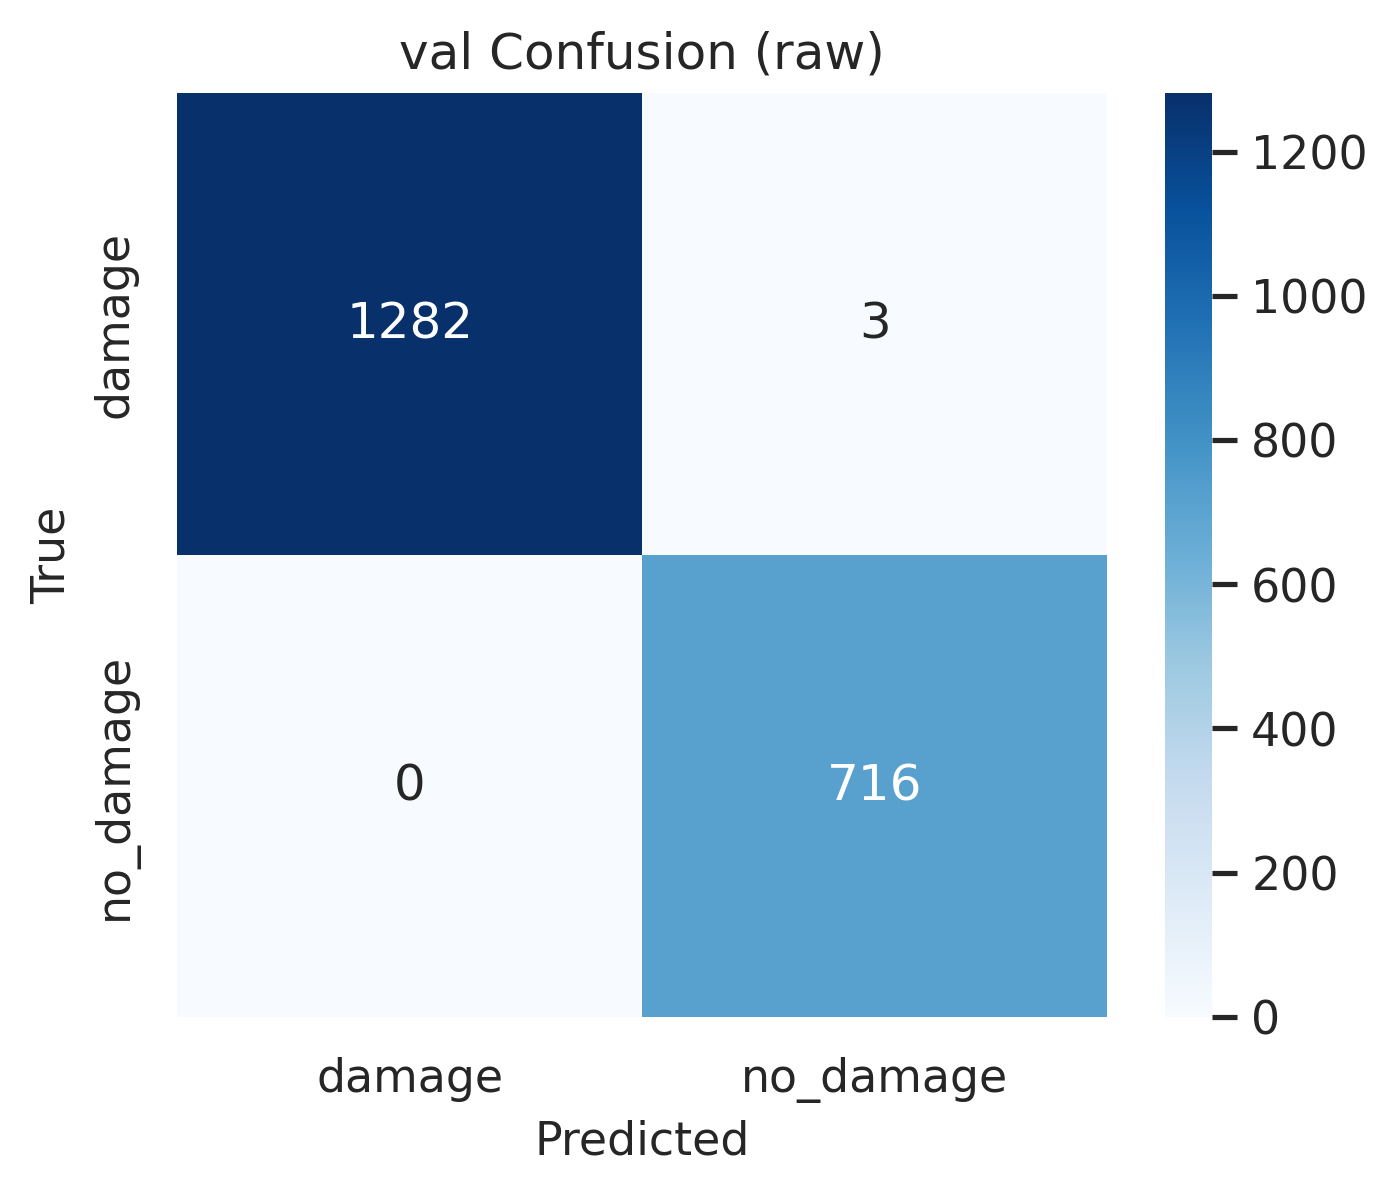

Saved figure to ../training_runs/resampled_20251206-154401_resnet18/eval_plots/eval_val_raw_score_hist.pdf


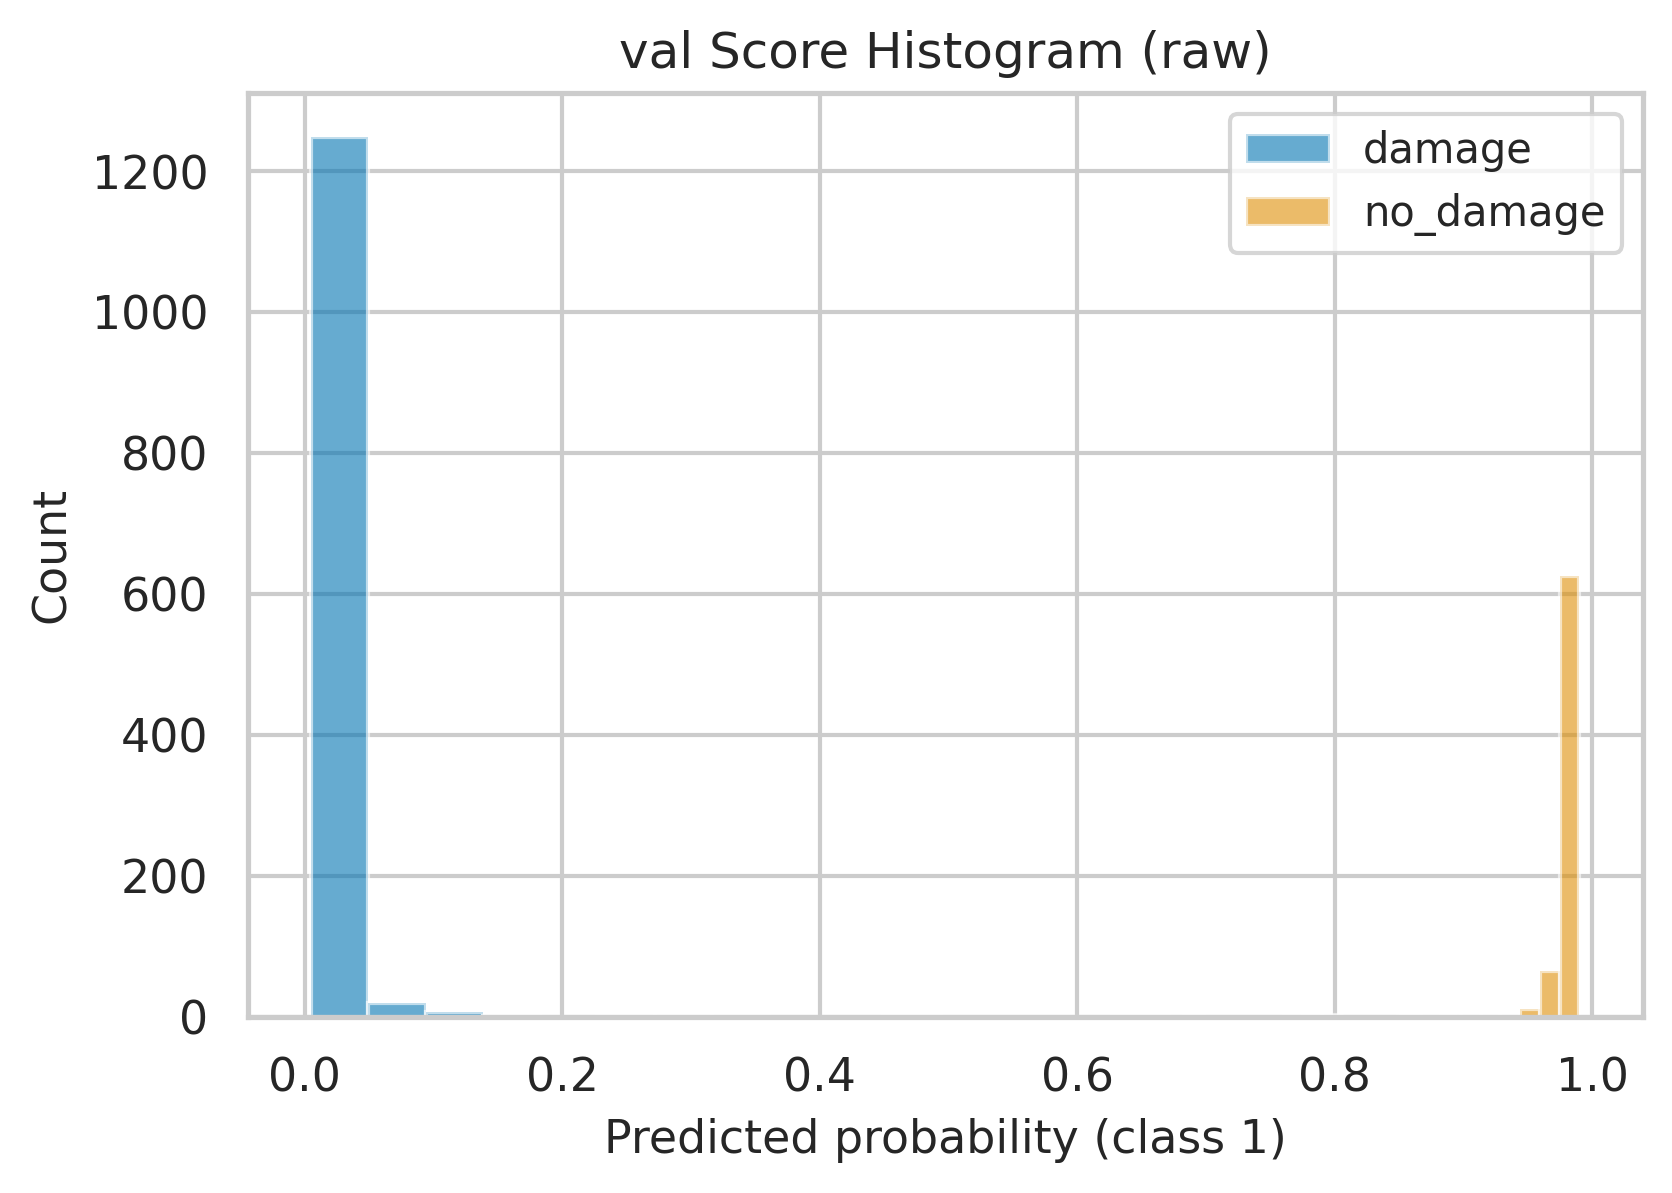

Saved figure to ../training_runs/resampled_20251206-154401_resnet18/eval_plots/eval_val_raw_reliability.pdf


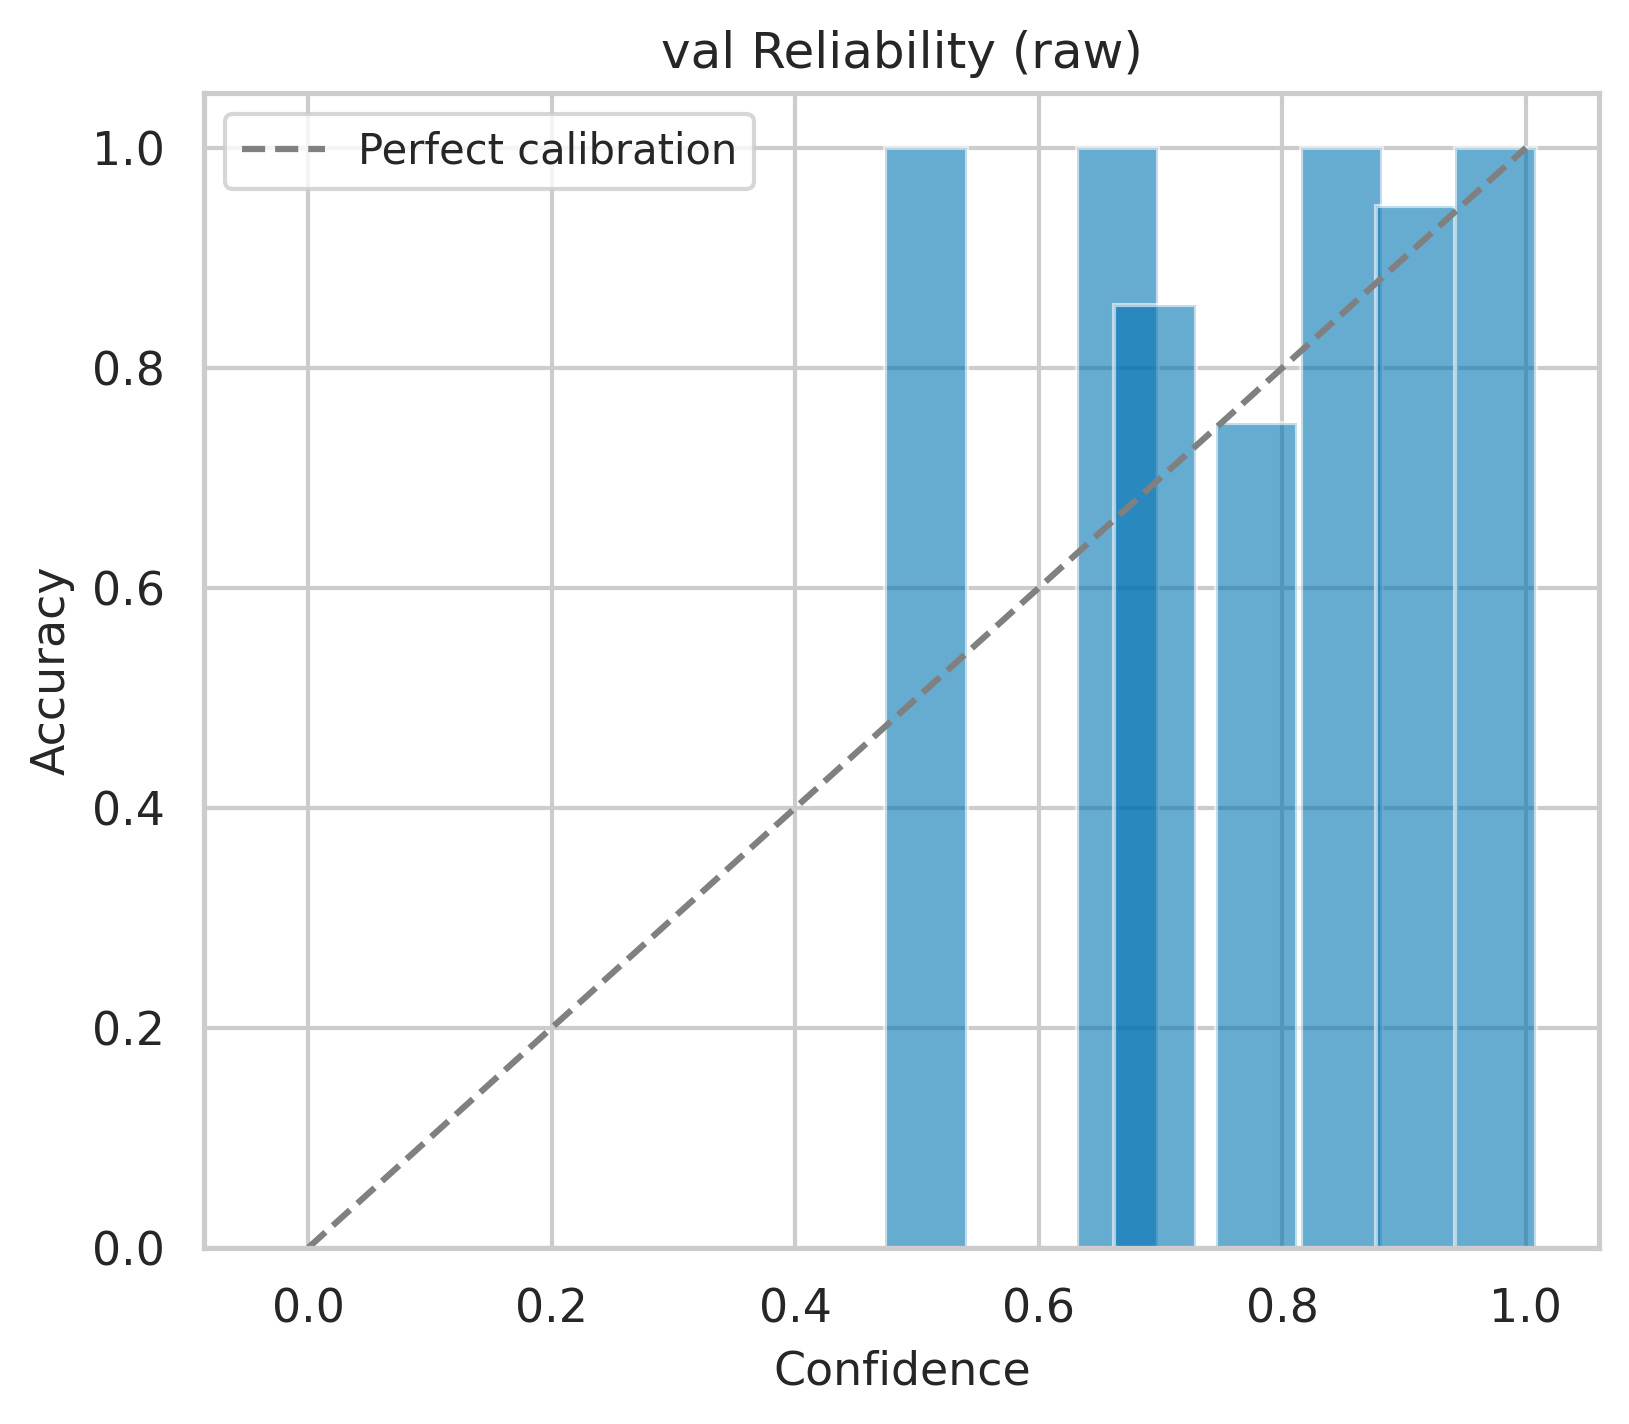

Saved figure to ../training_runs/resampled_20251206-154401_resnet18/eval_plots/eval_test_raw_confusion.pdf


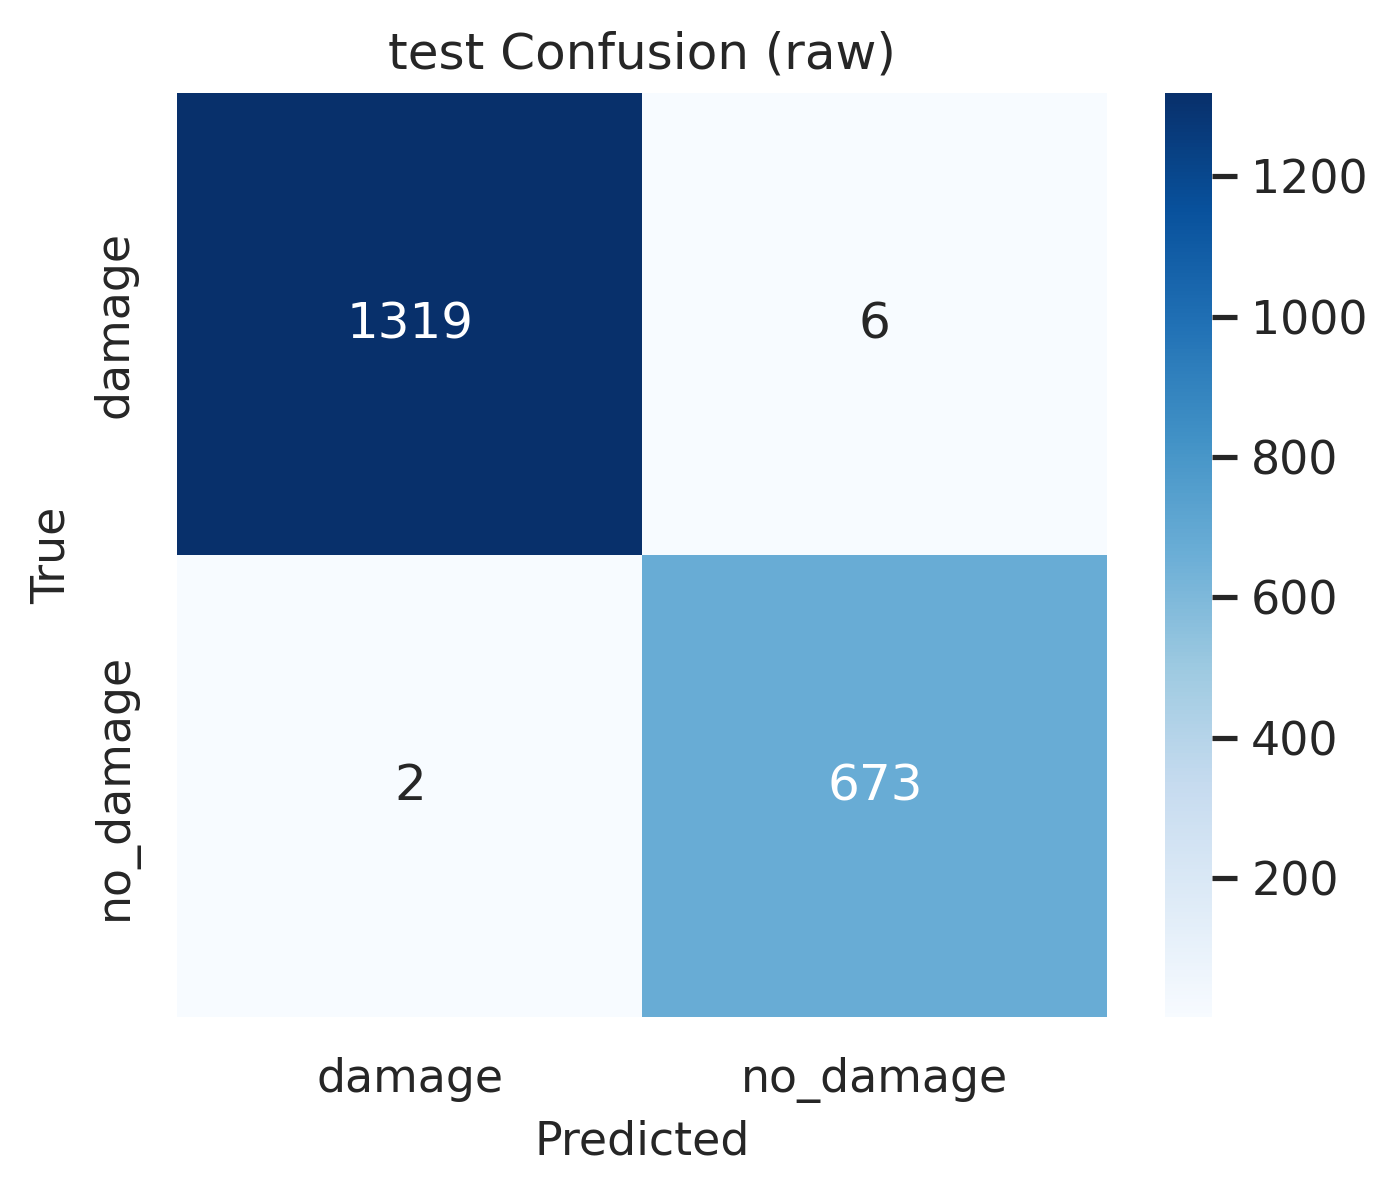

Saved figure to ../training_runs/resampled_20251206-154401_resnet18/eval_plots/eval_test_raw_score_hist.pdf


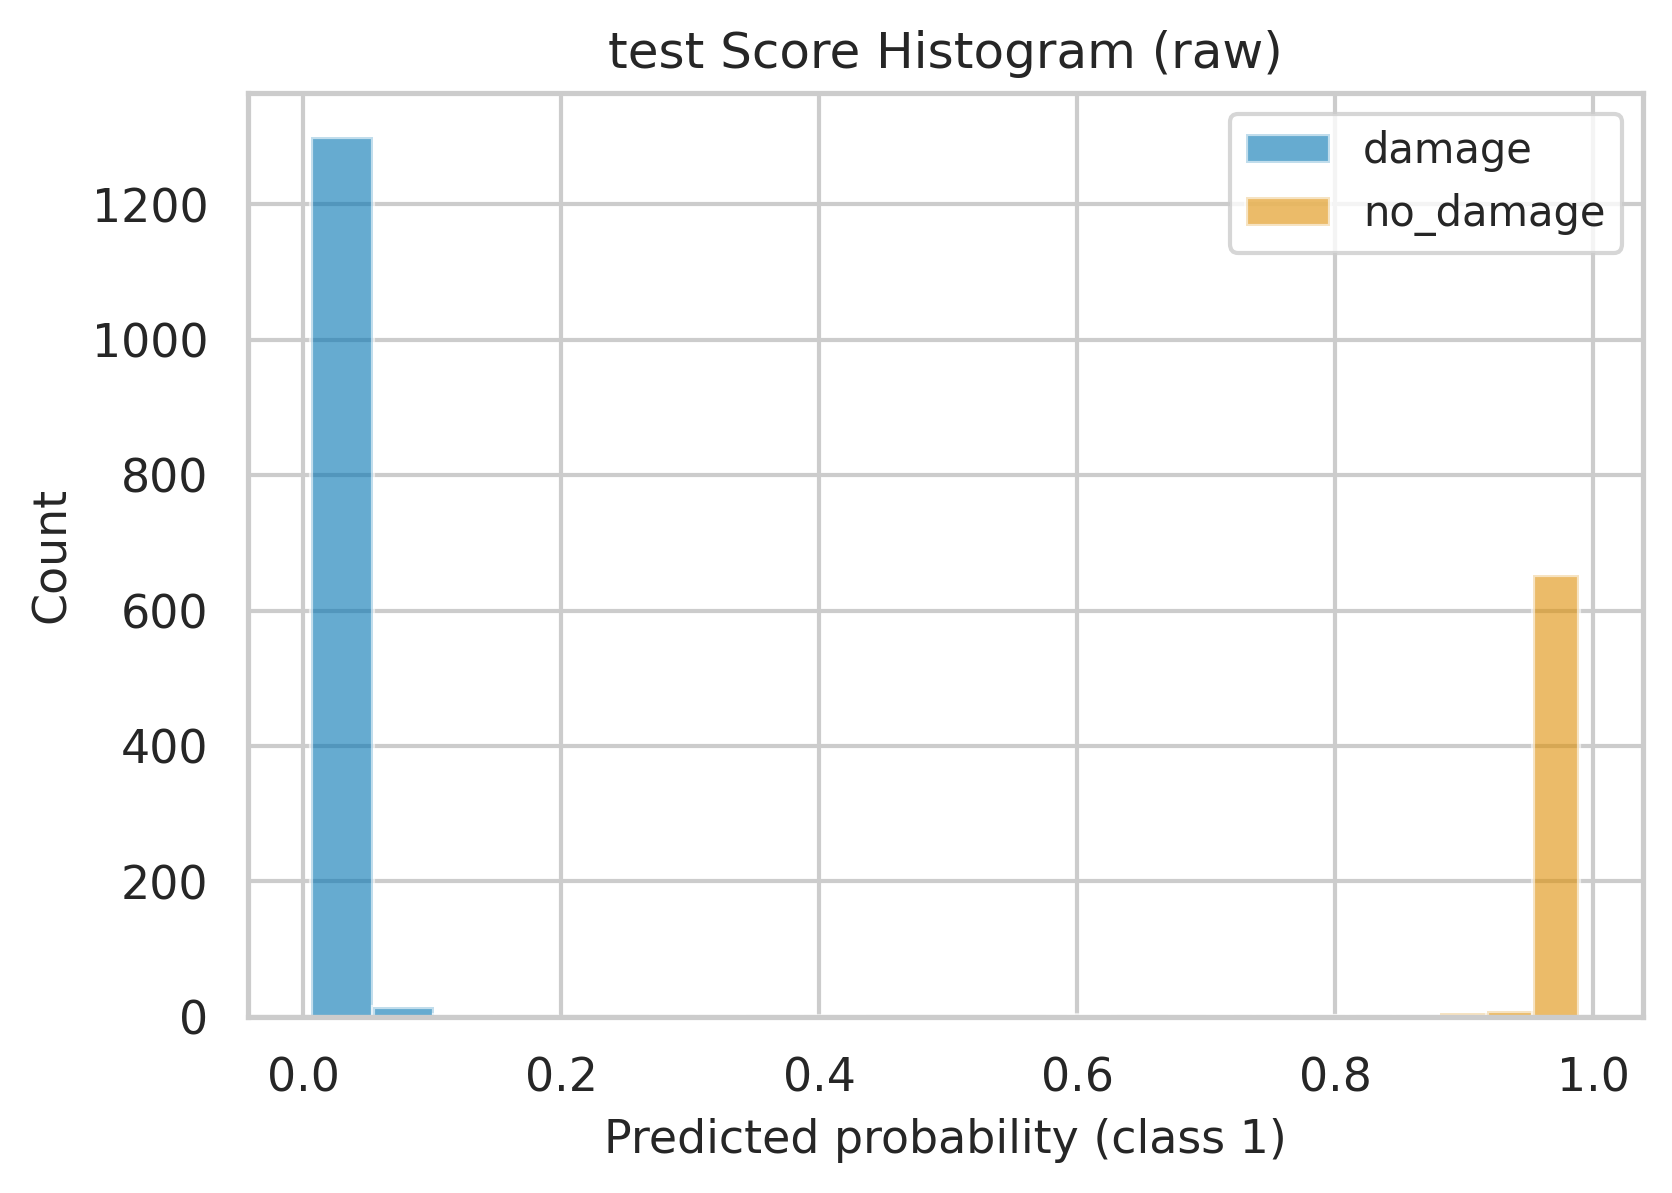

Saved figure to ../training_runs/resampled_20251206-154401_resnet18/eval_plots/eval_test_raw_reliability.pdf


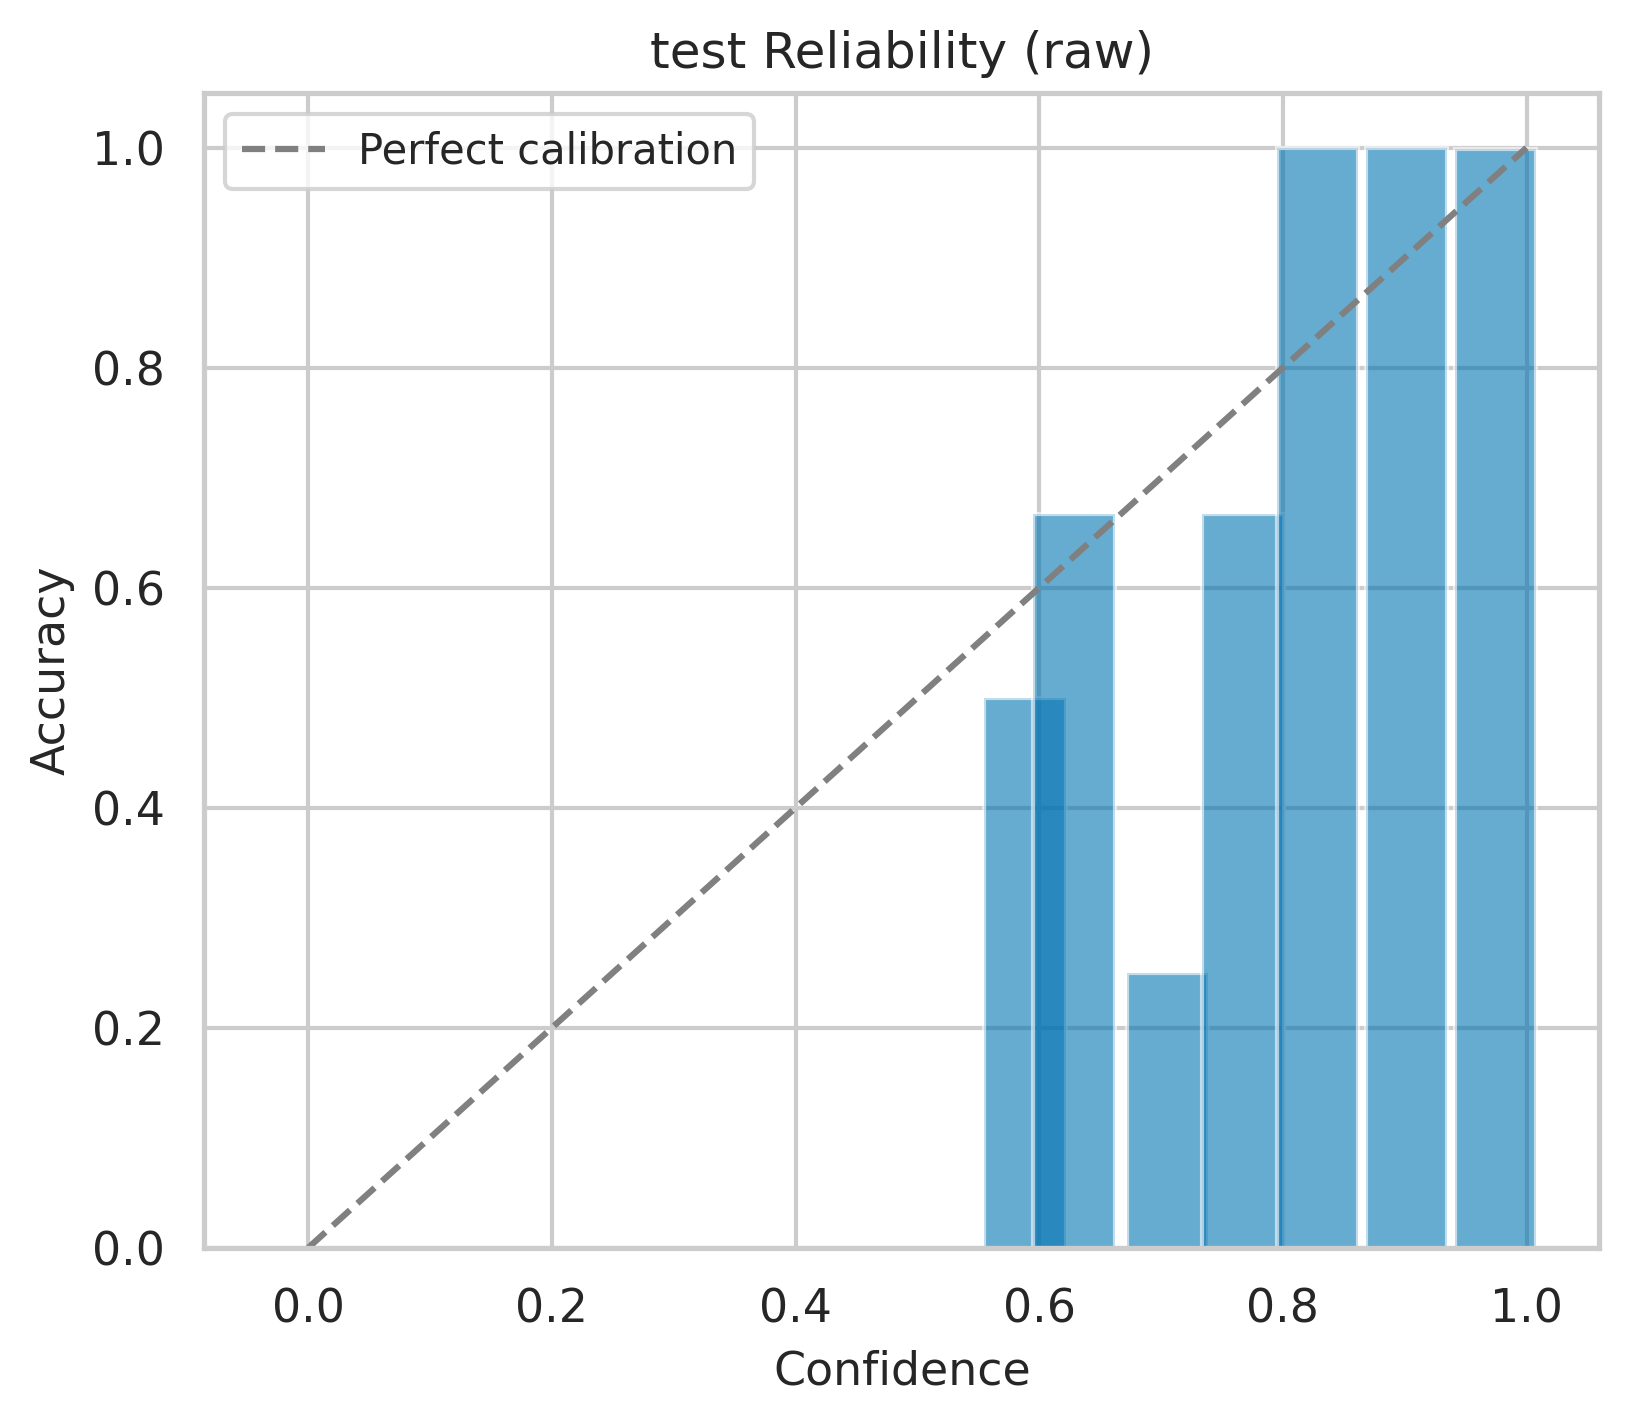

Saved figure to ../training_runs/resampled_20251206-154401_resnet18/eval_plots/eval_val_calibrated_confusion.pdf


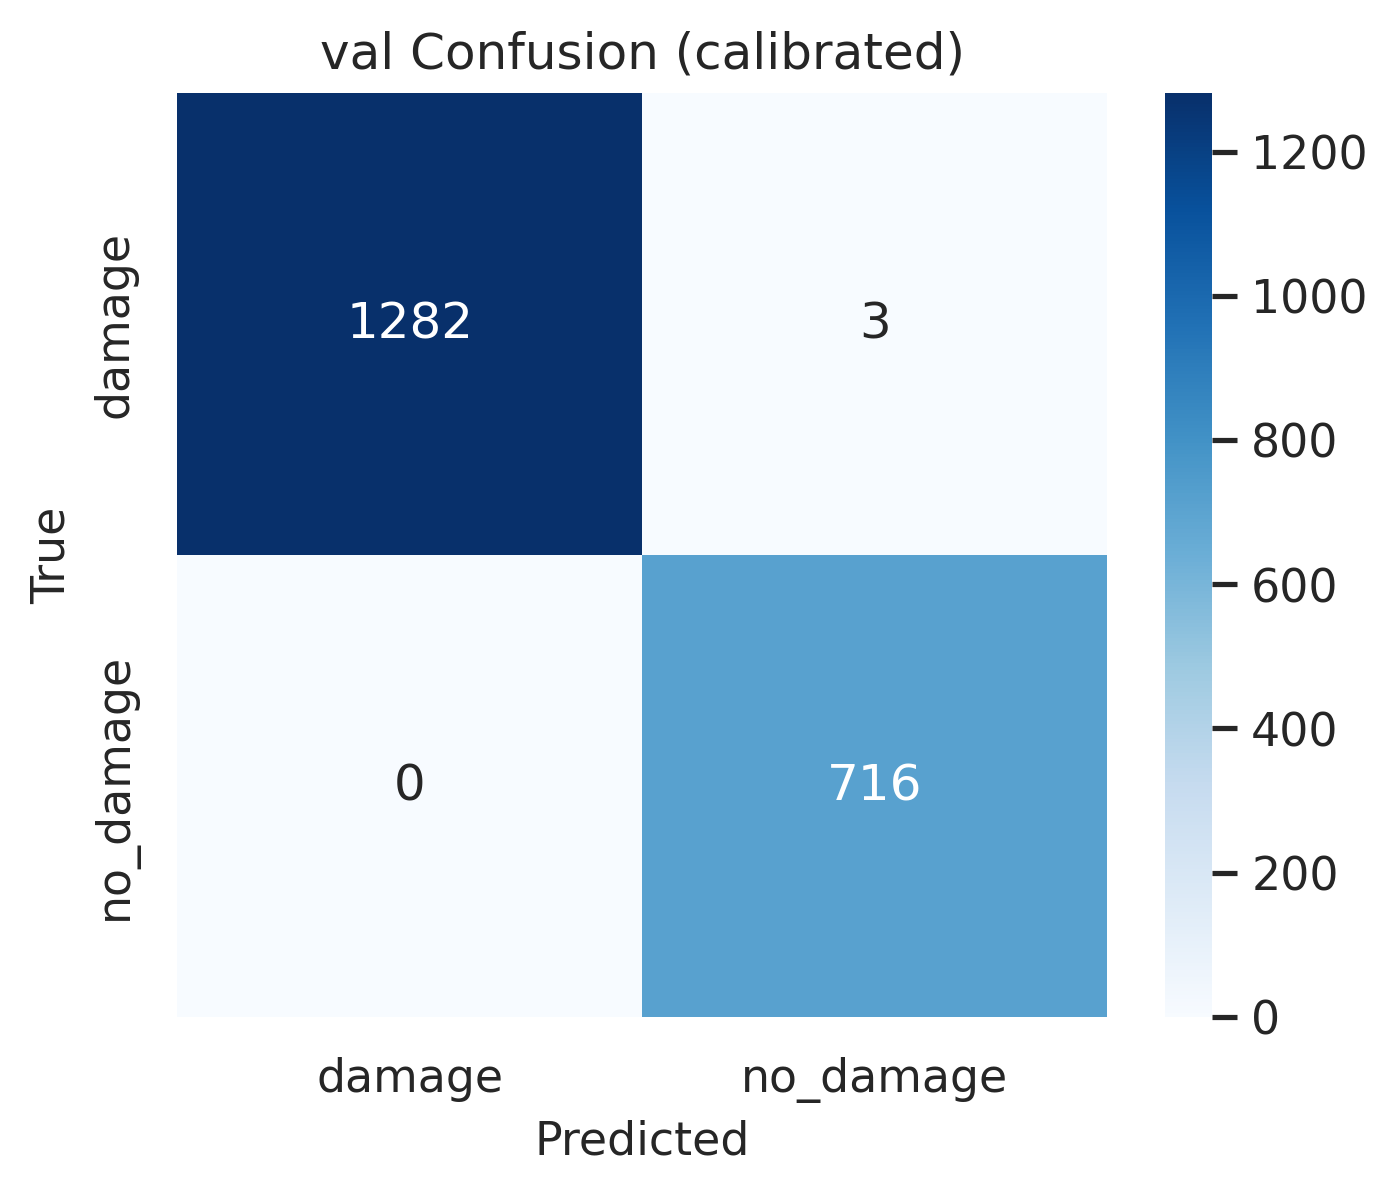

Saved figure to ../training_runs/resampled_20251206-154401_resnet18/eval_plots/eval_val_calibrated_score_hist.pdf


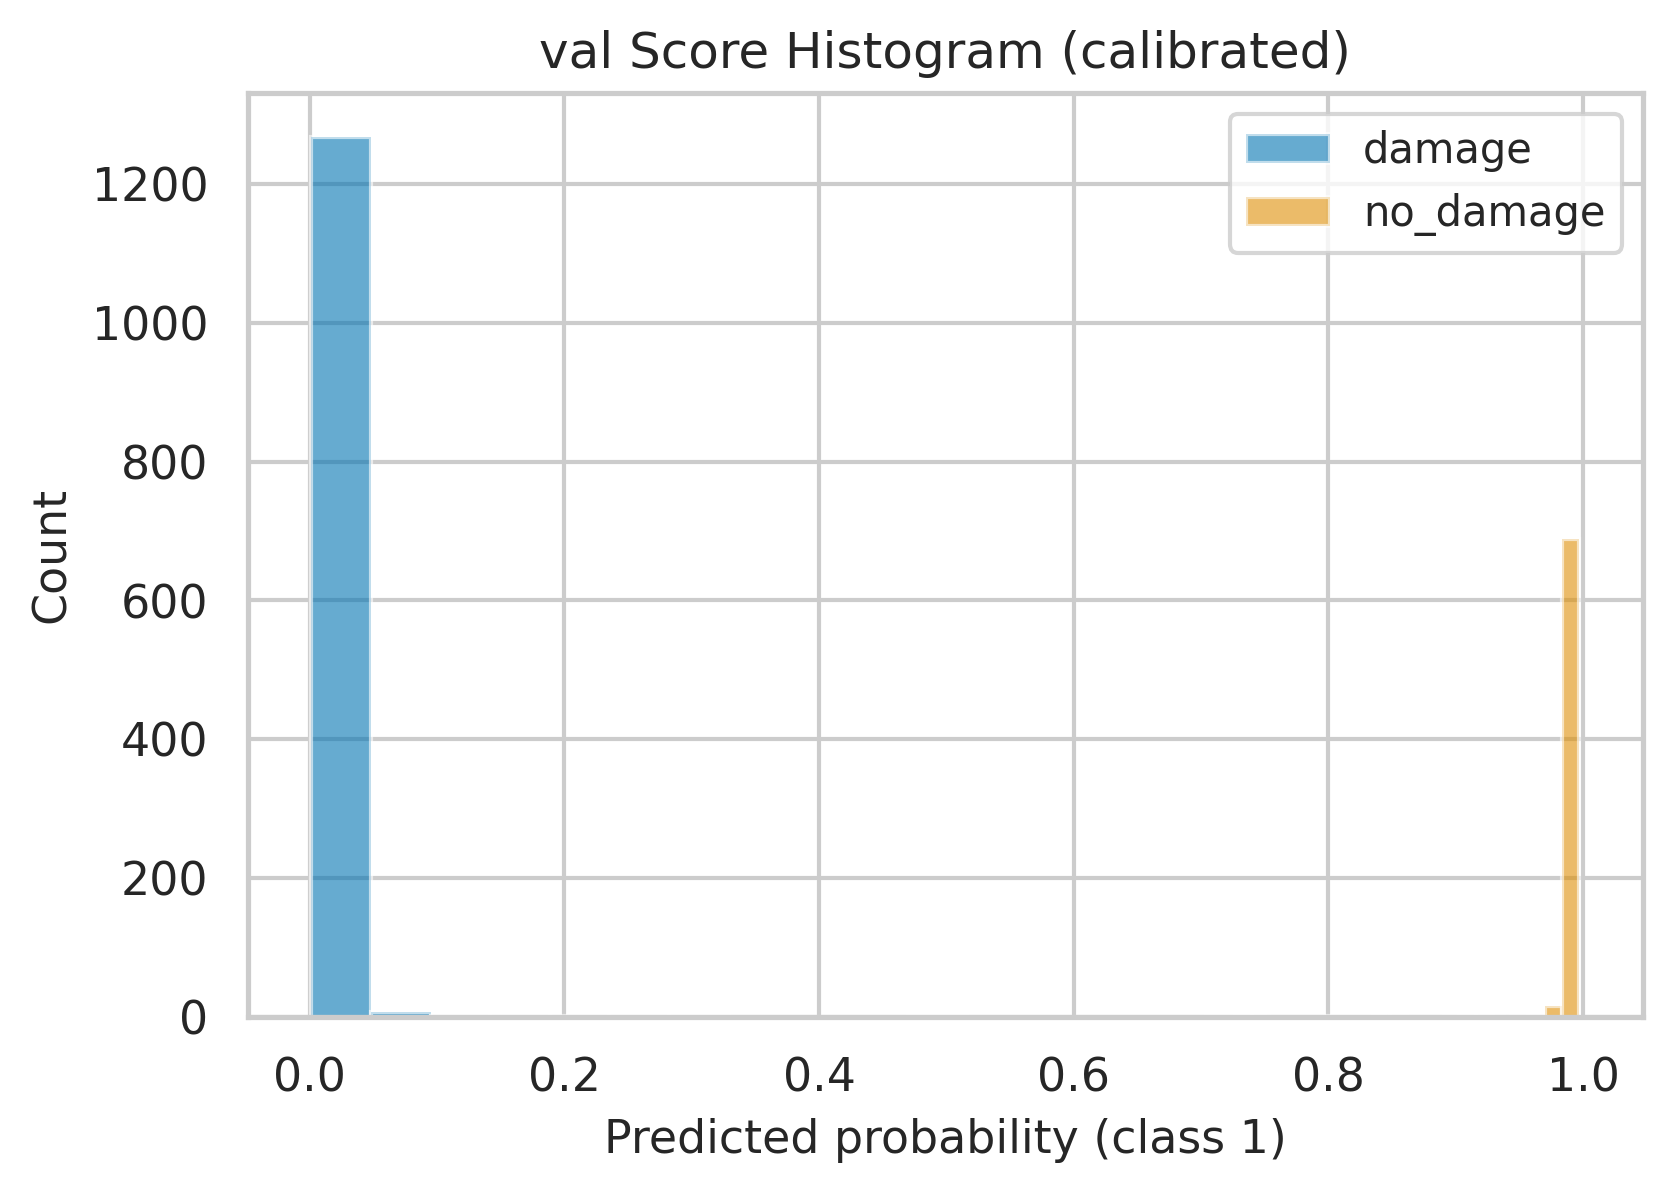

Saved figure to ../training_runs/resampled_20251206-154401_resnet18/eval_plots/eval_val_calibrated_reliability.pdf


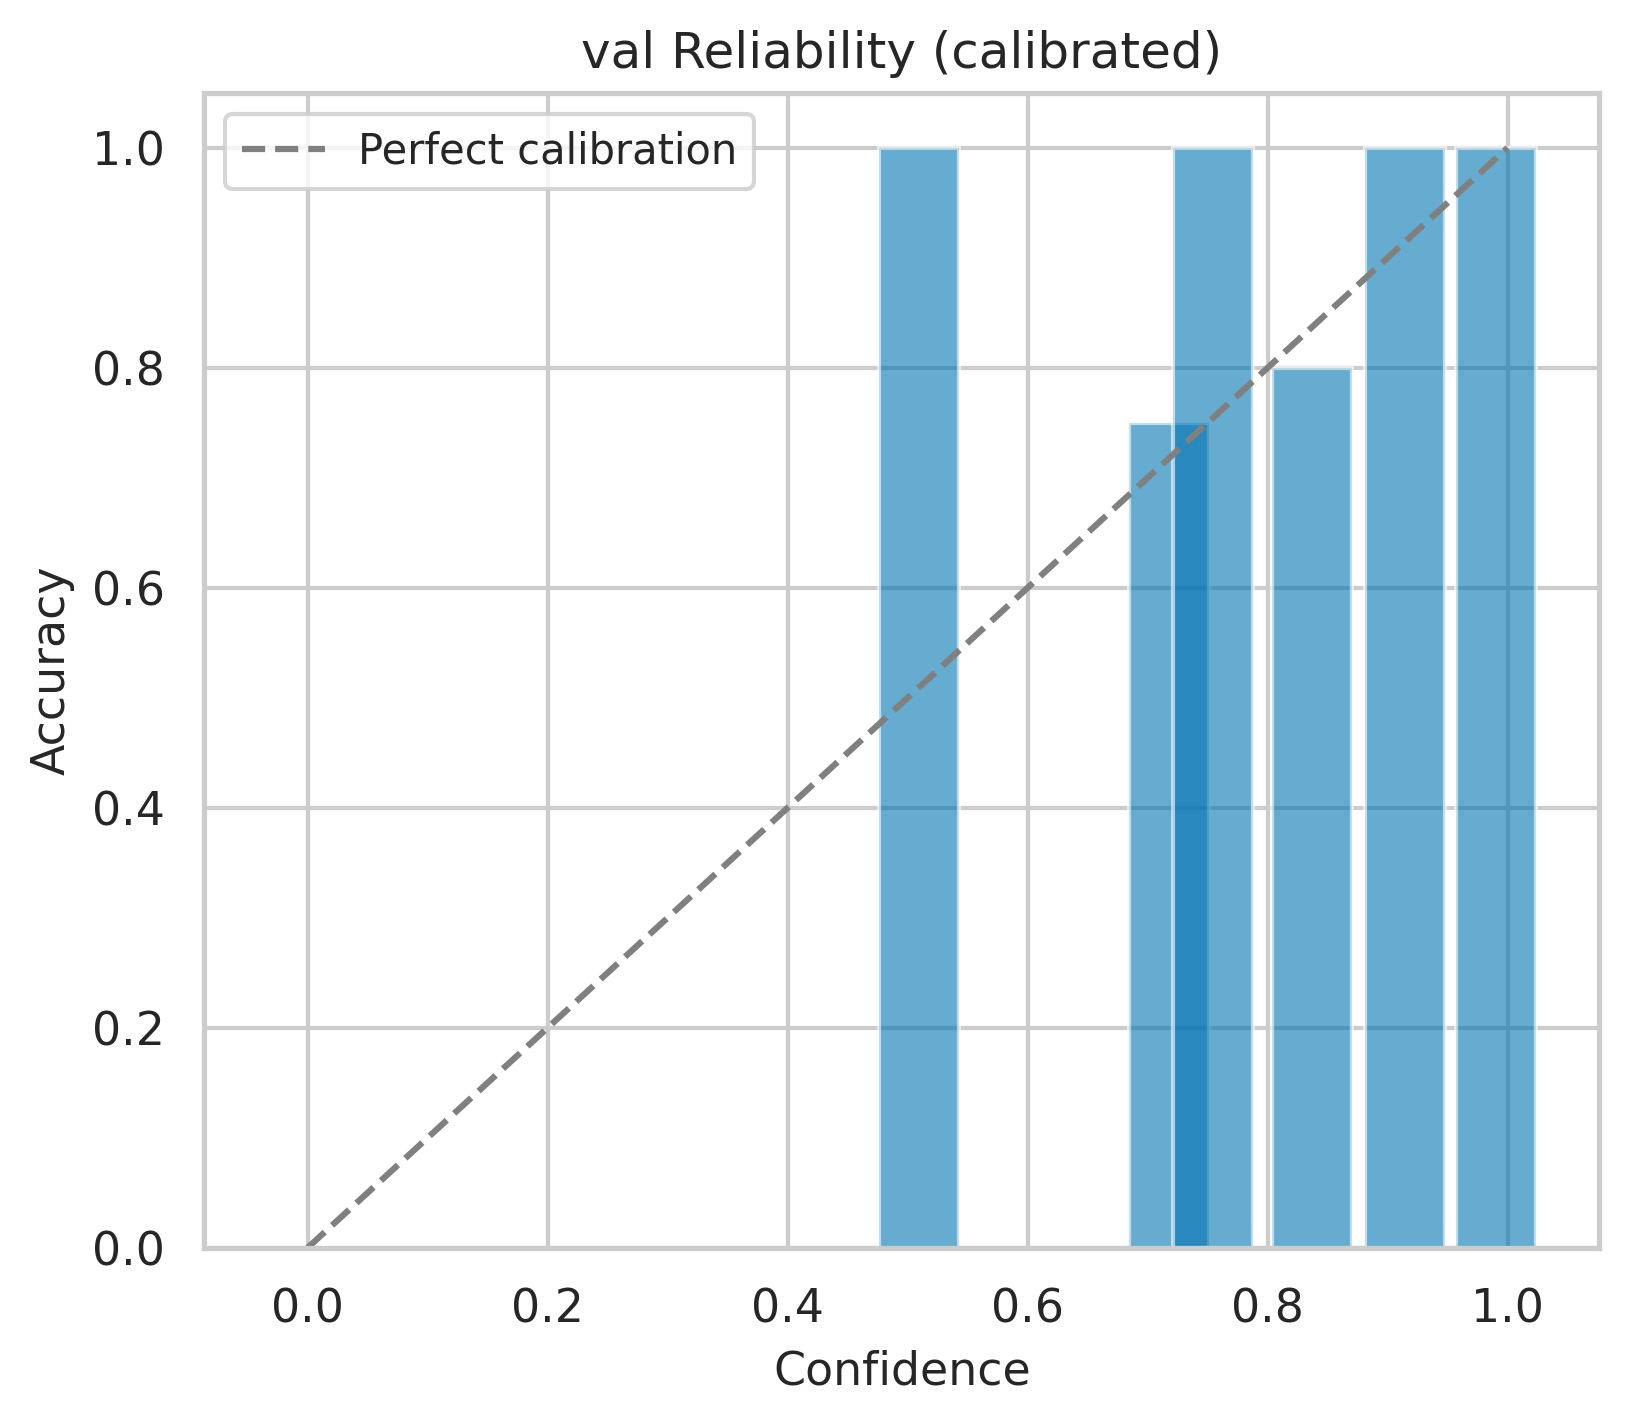

Saved figure to ../training_runs/resampled_20251206-154401_resnet18/eval_plots/eval_test_calibrated_confusion.pdf


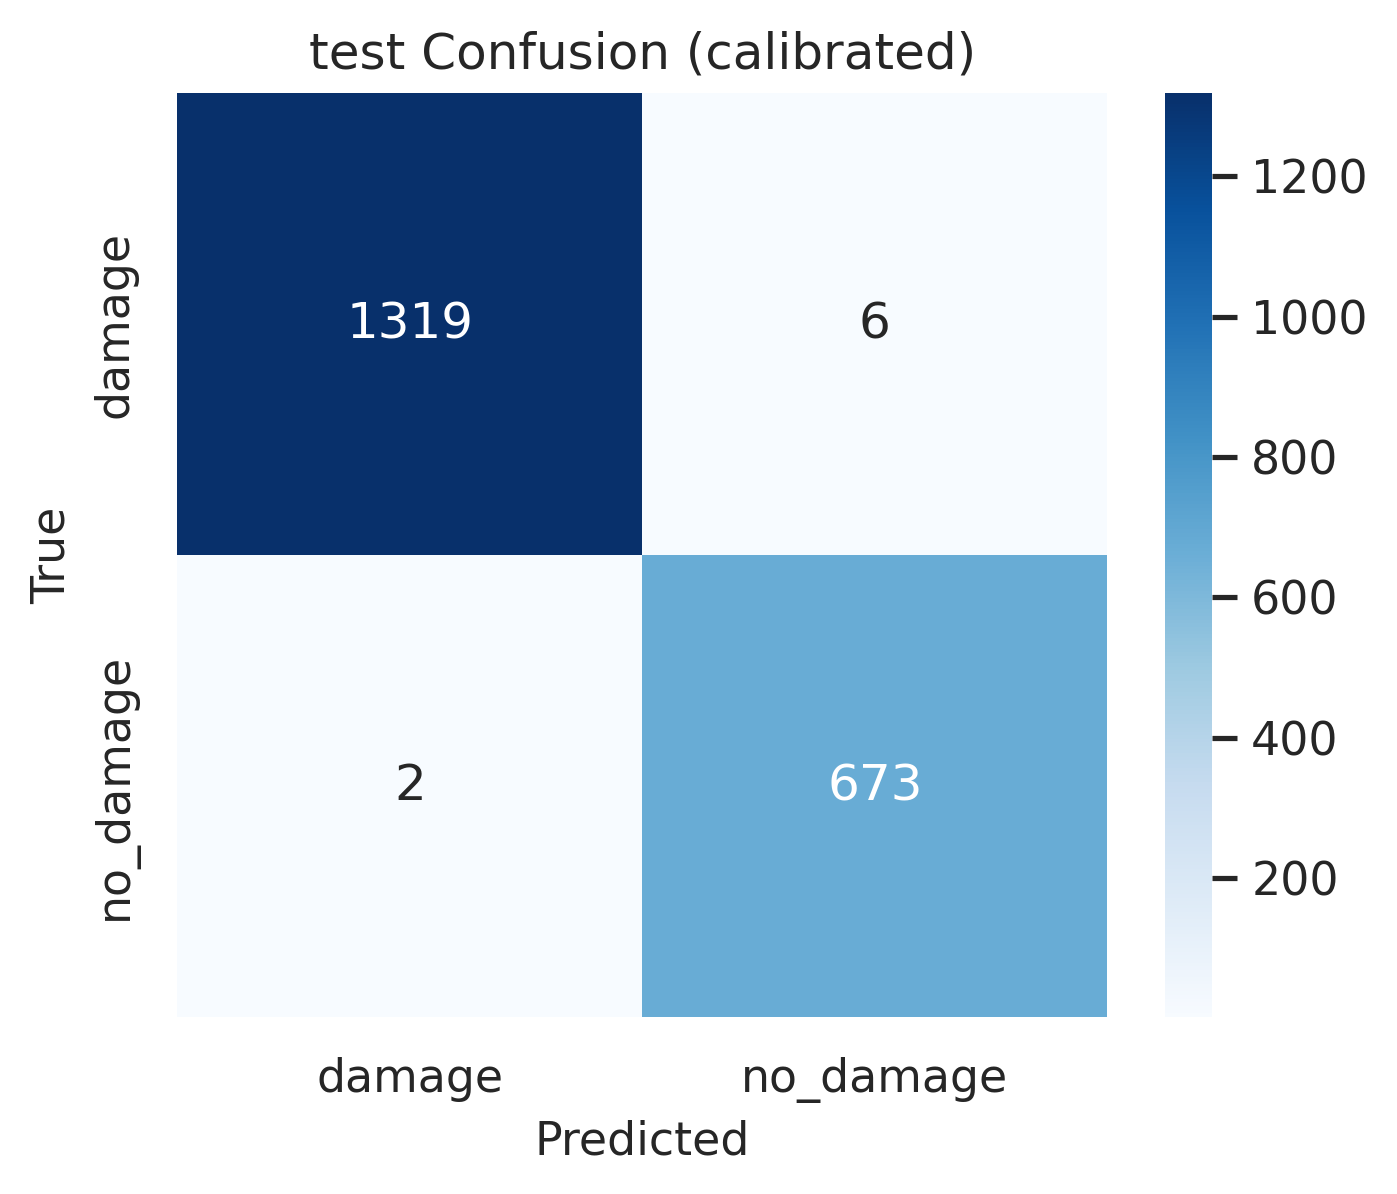

Saved figure to ../training_runs/resampled_20251206-154401_resnet18/eval_plots/eval_test_calibrated_score_hist.pdf


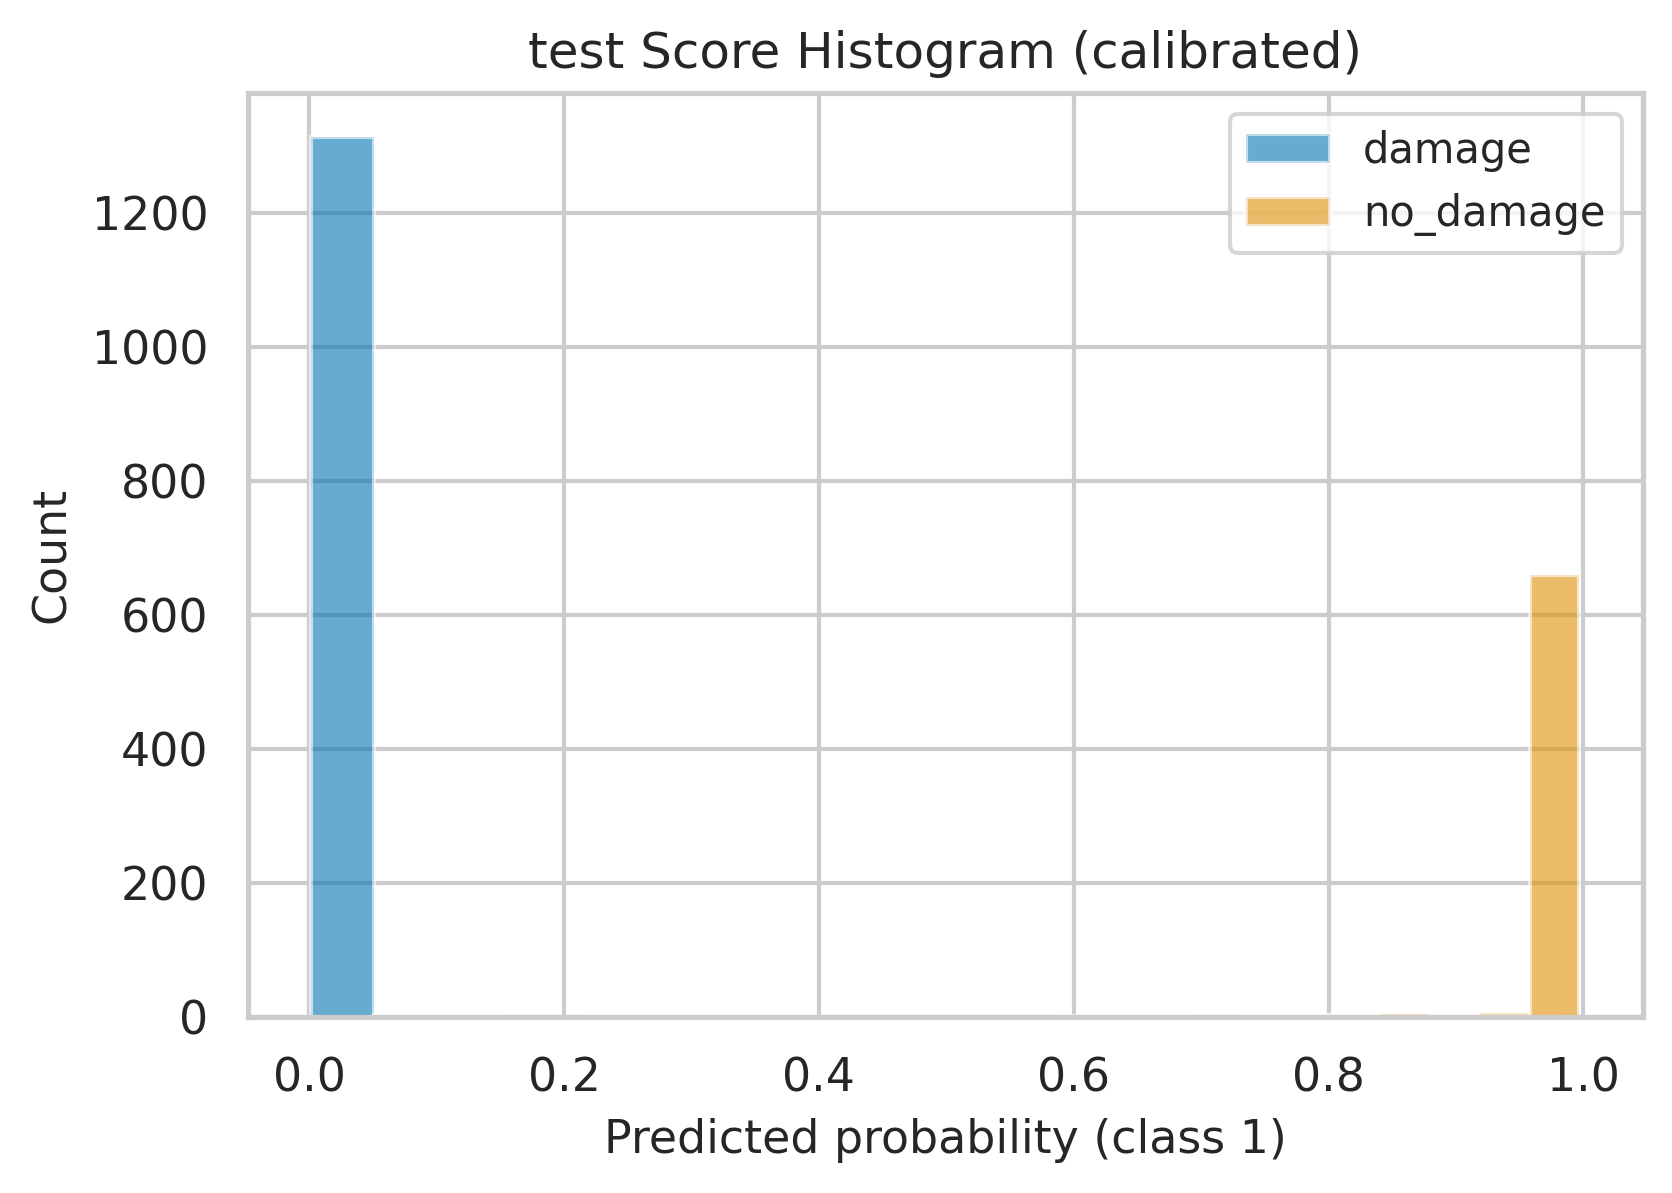

Saved figure to ../training_runs/resampled_20251206-154401_resnet18/eval_plots/eval_test_calibrated_reliability.pdf


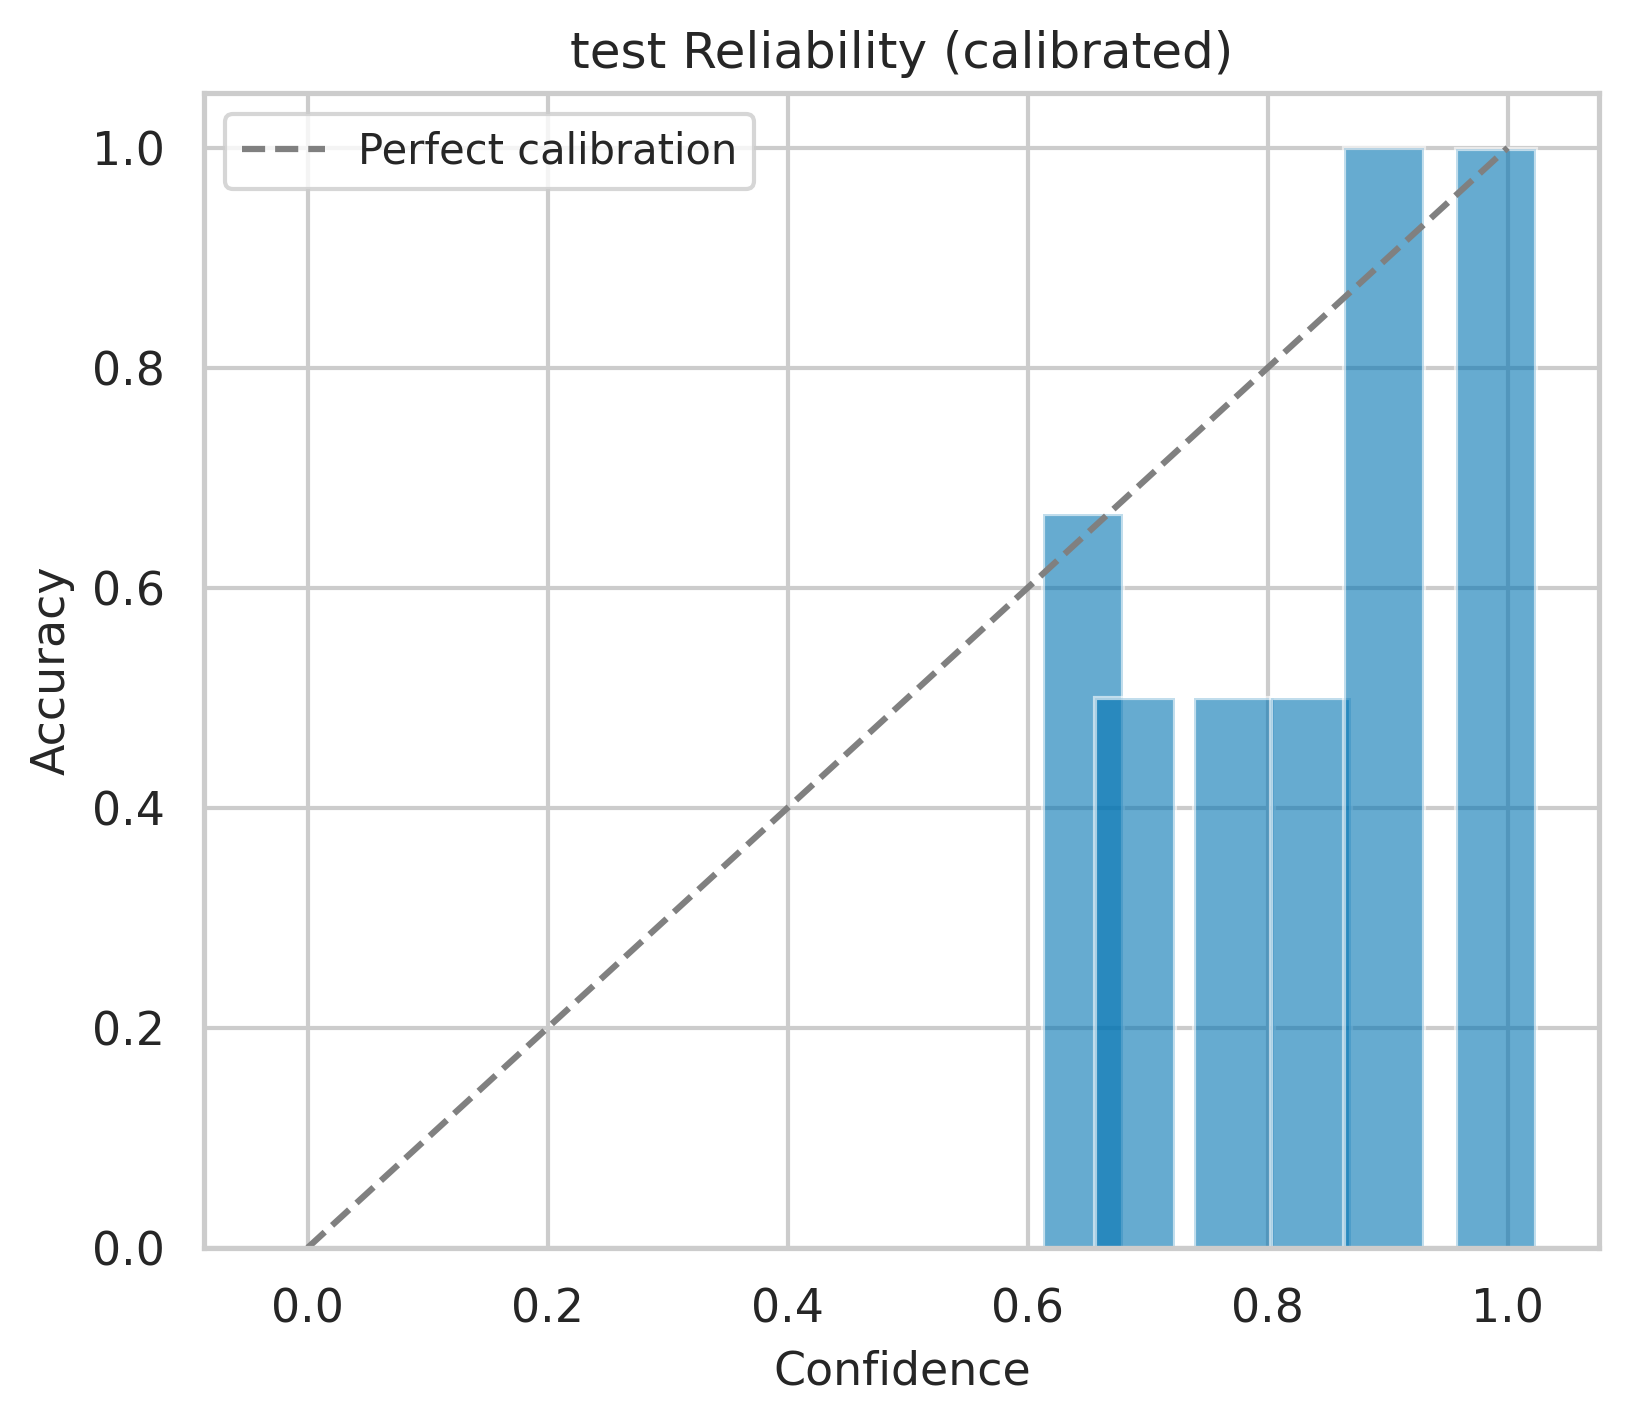

Saved eval metrics to ../training_runs/resampled_20251206-154401_resnet18/eval_metrics.json
Fitted temperature: 0.7846
Test metrics (raw): {'accuracy': 0.996, 'macro_precision': 0.9948247355787723, 'macro_recall': 0.9962543675751223, 'macro_f1': 0.9955340744536778, 'brier': 0.0034104182988576987, 'ece': 0.026484124779701197}
Test metrics (calibrated): {'accuracy': 0.996, 'macro_precision': 0.9948247355787723, 'macro_recall': 0.9962543675751223, 'macro_f1': 0.9955340744536778, 'brier': 0.0029101726235796397, 'ece': 0.010590291738510125}


In [5]:
resnet18_eval = evaluate_run("resnet18")

Saved figure to ../training_runs/resampled_20251206-154401_resnet34/eval_plots/eval_val_raw_confusion.pdf


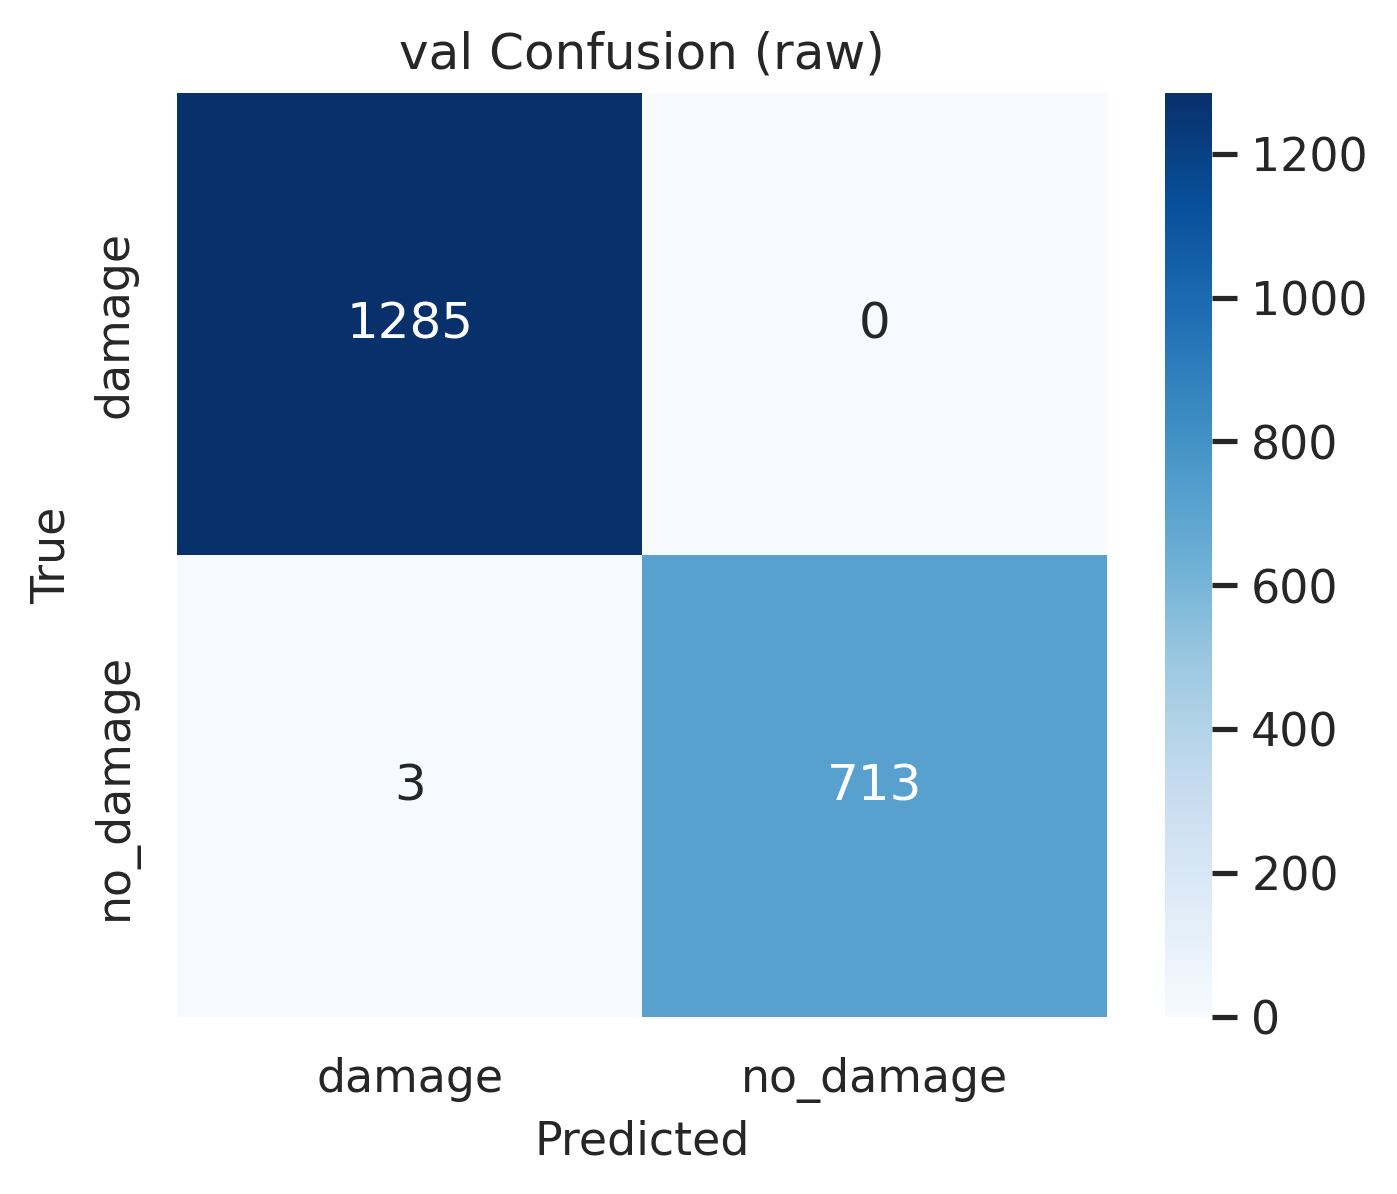

Saved figure to ../training_runs/resampled_20251206-154401_resnet34/eval_plots/eval_val_raw_score_hist.pdf


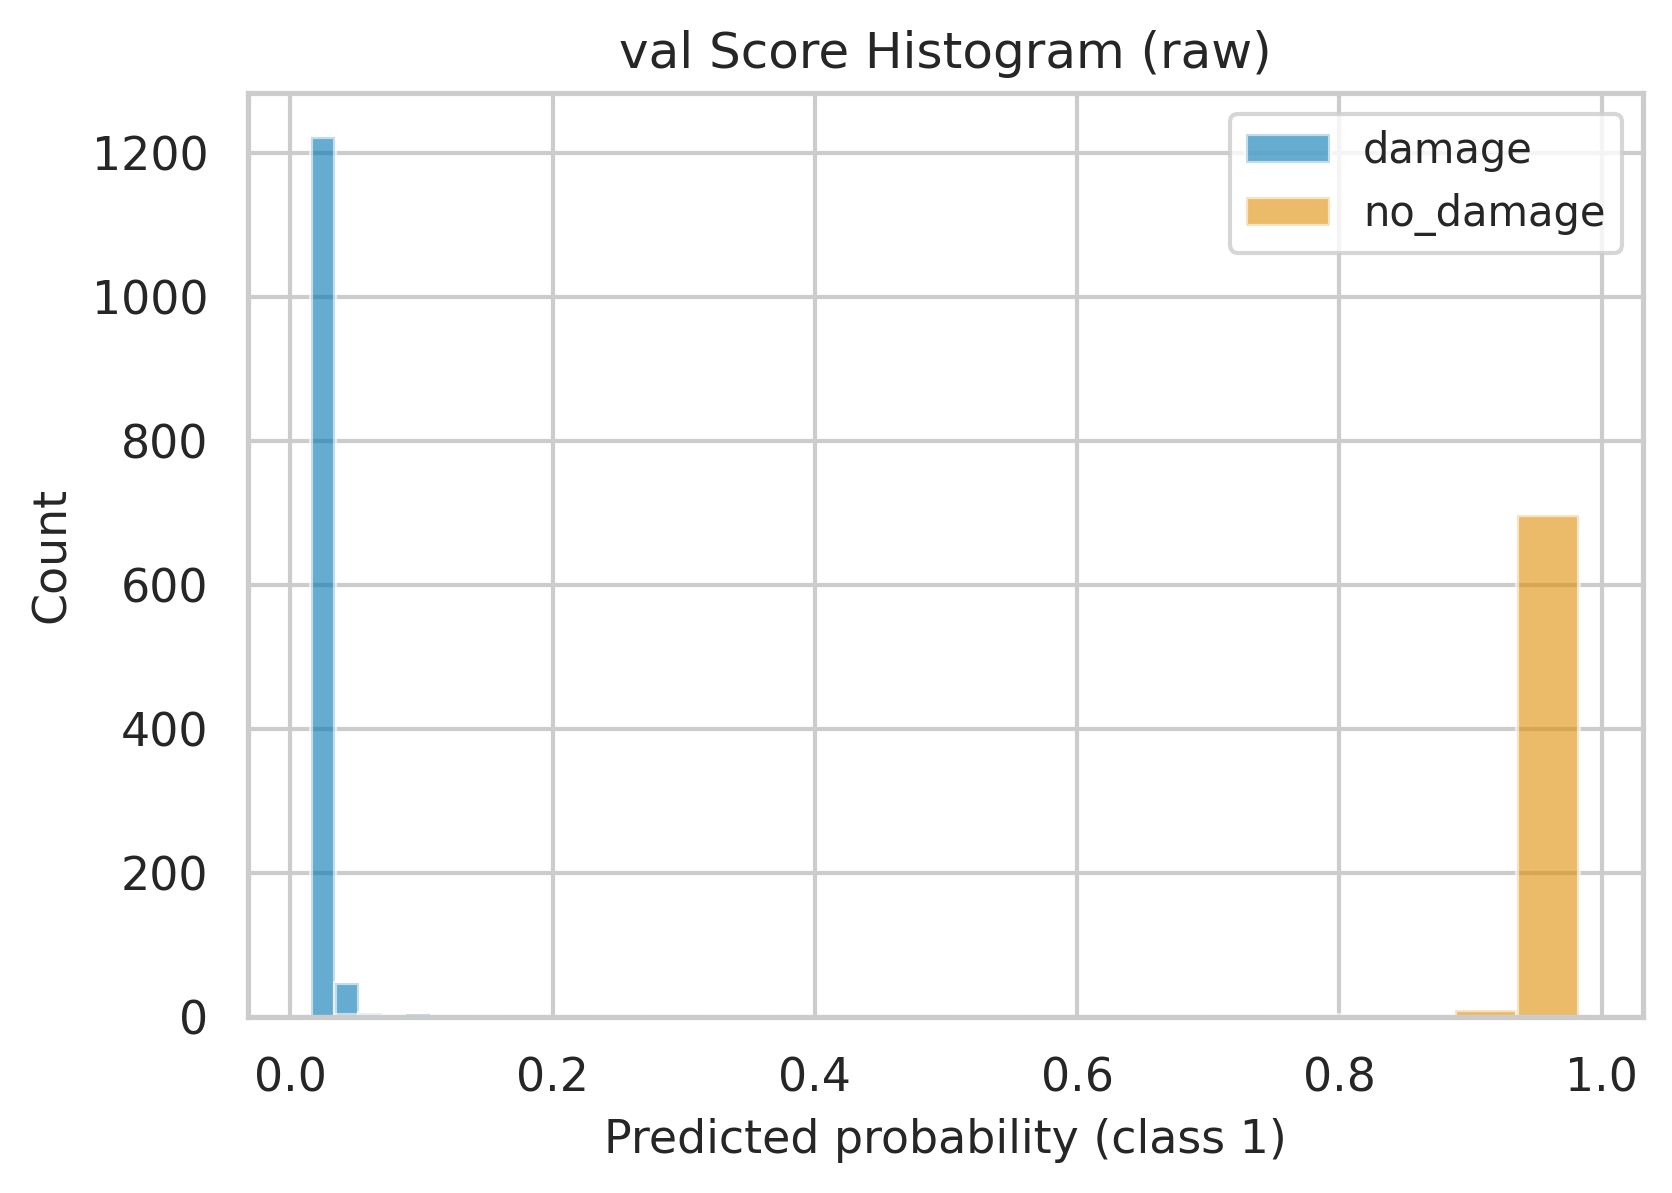

Saved figure to ../training_runs/resampled_20251206-154401_resnet34/eval_plots/eval_val_raw_reliability.pdf


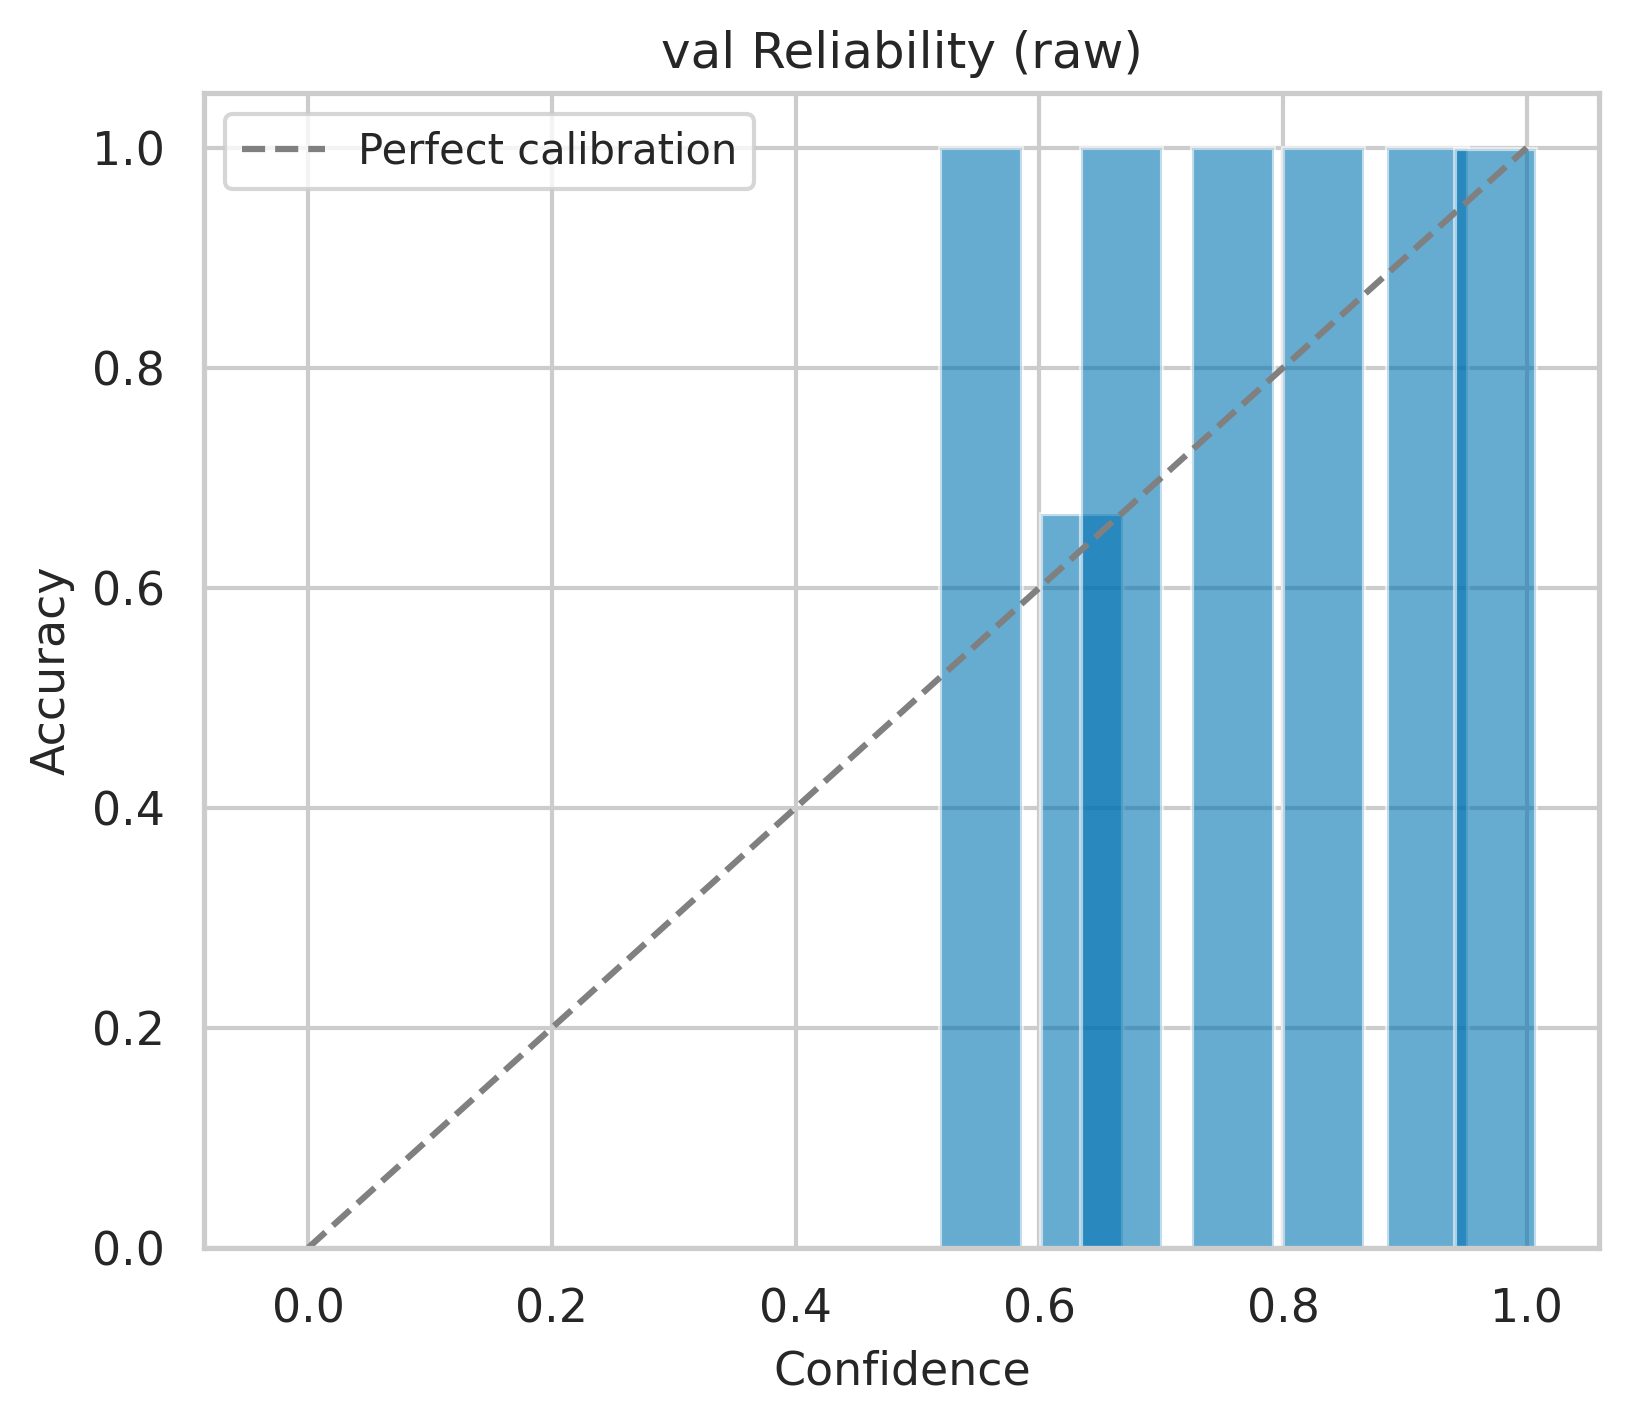

Saved figure to ../training_runs/resampled_20251206-154401_resnet34/eval_plots/eval_test_raw_confusion.pdf


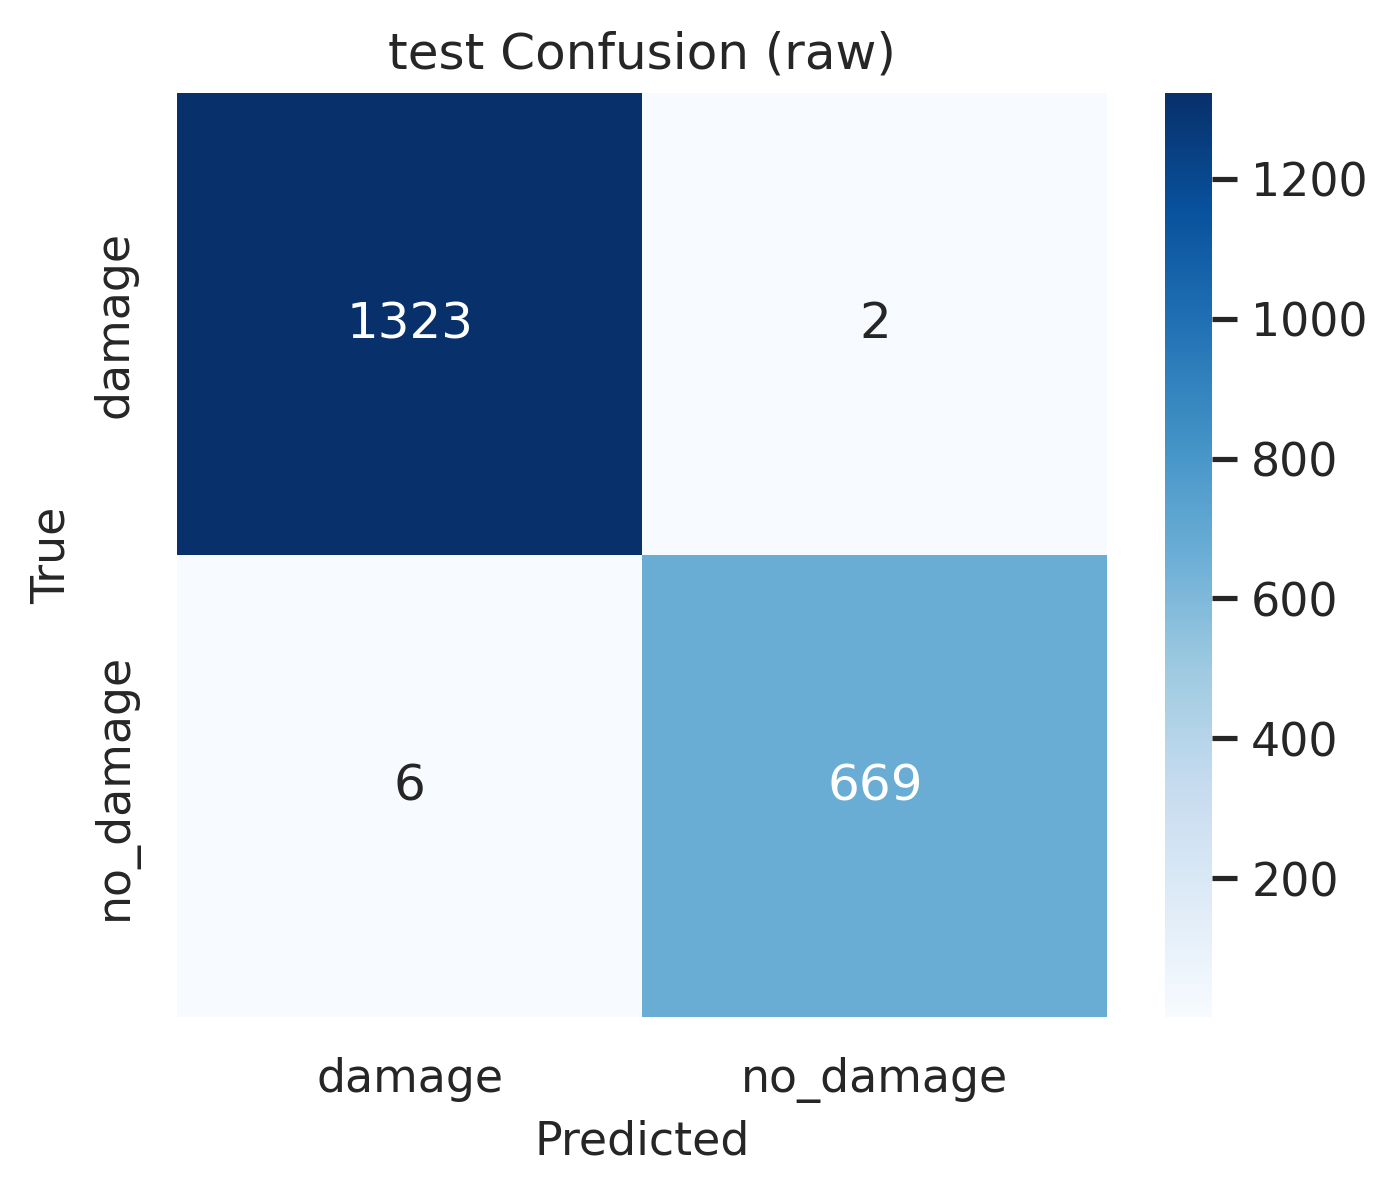

Saved figure to ../training_runs/resampled_20251206-154401_resnet34/eval_plots/eval_test_raw_score_hist.pdf


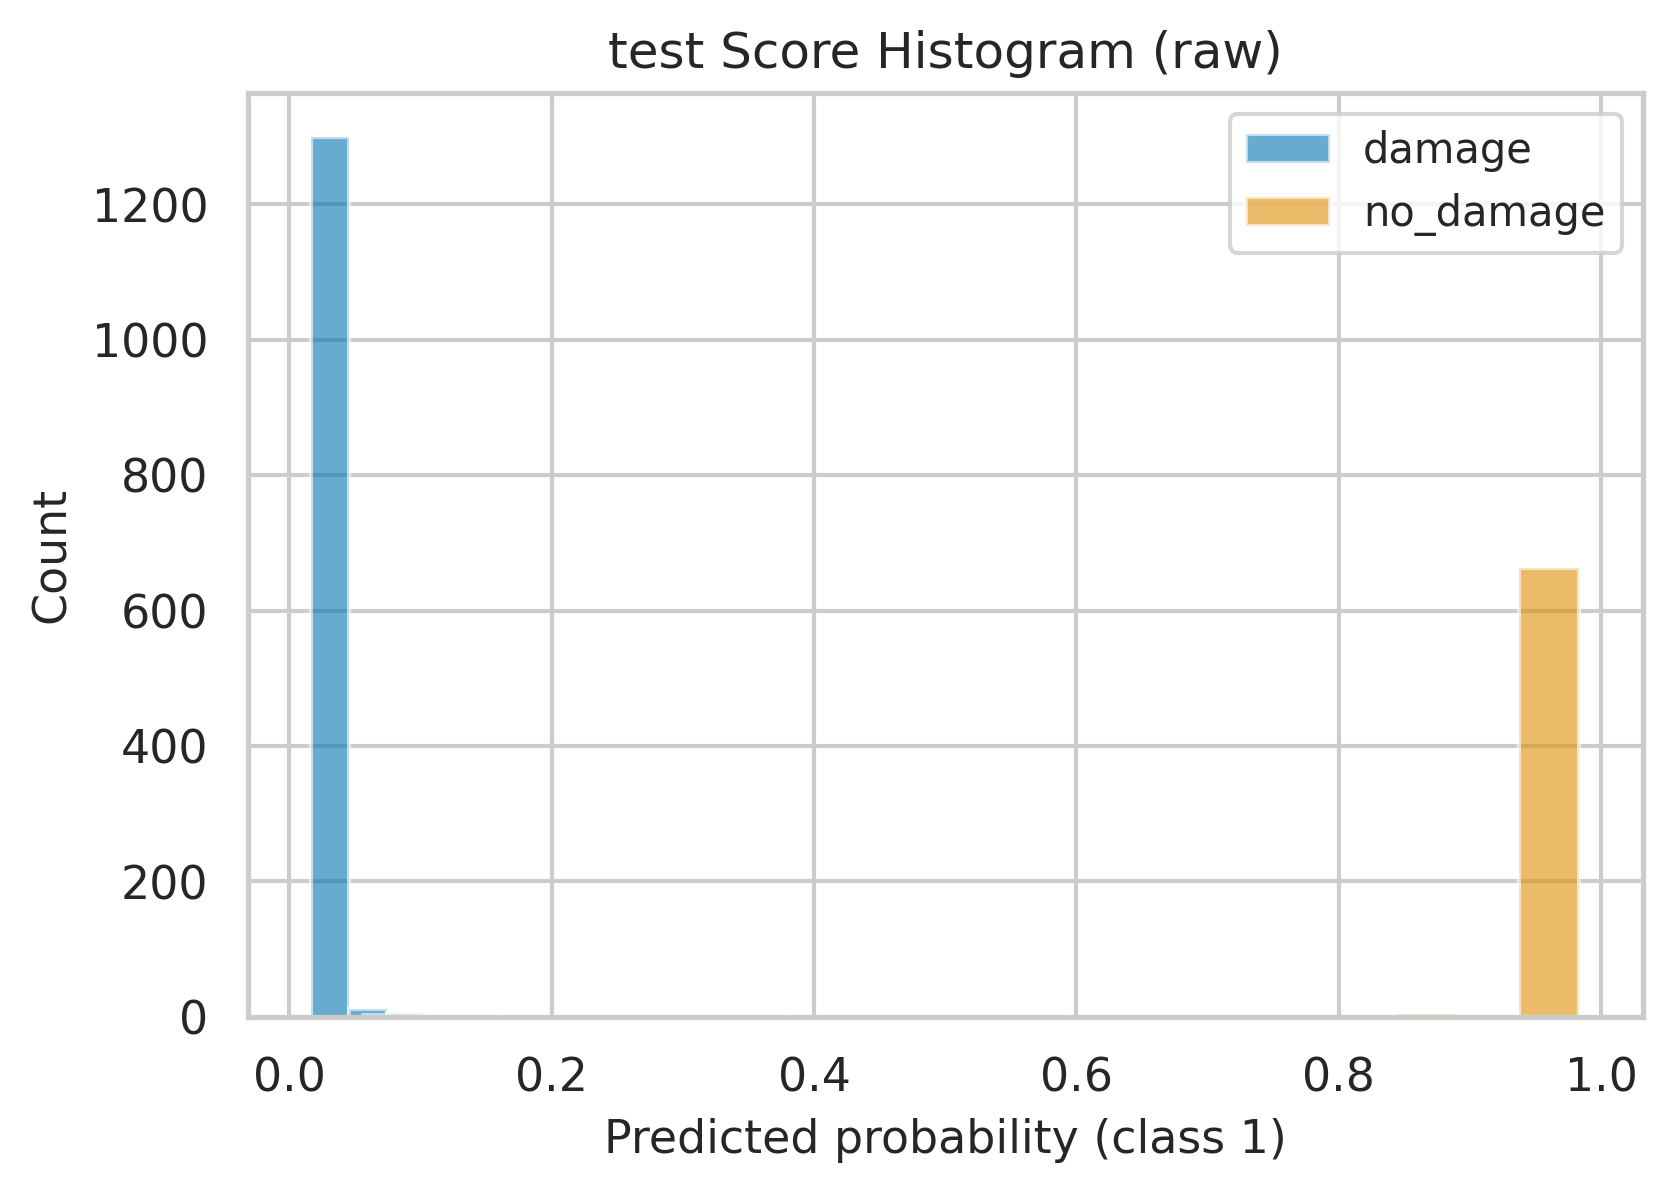

Saved figure to ../training_runs/resampled_20251206-154401_resnet34/eval_plots/eval_test_raw_reliability.pdf


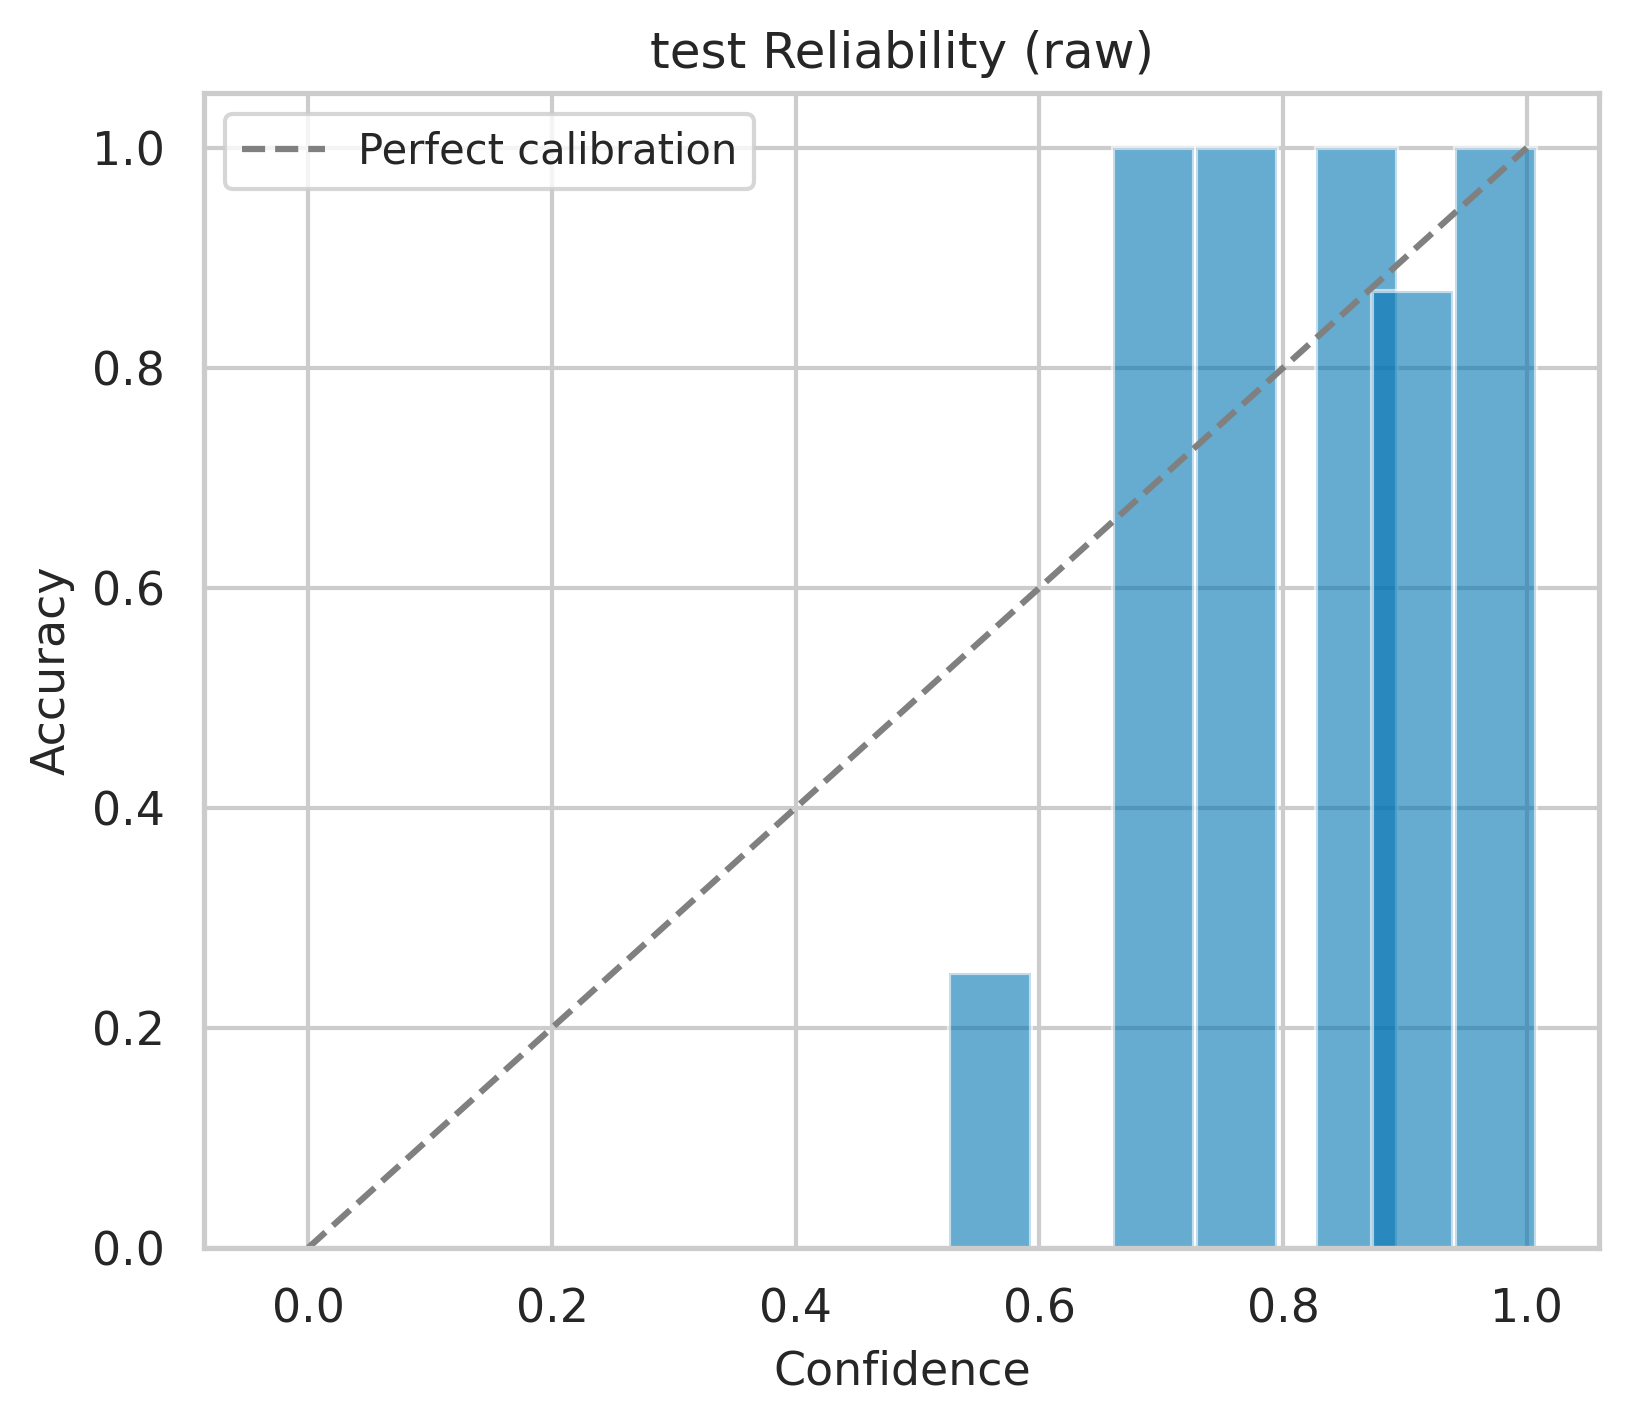

Saved figure to ../training_runs/resampled_20251206-154401_resnet34/eval_plots/eval_val_calibrated_confusion.pdf


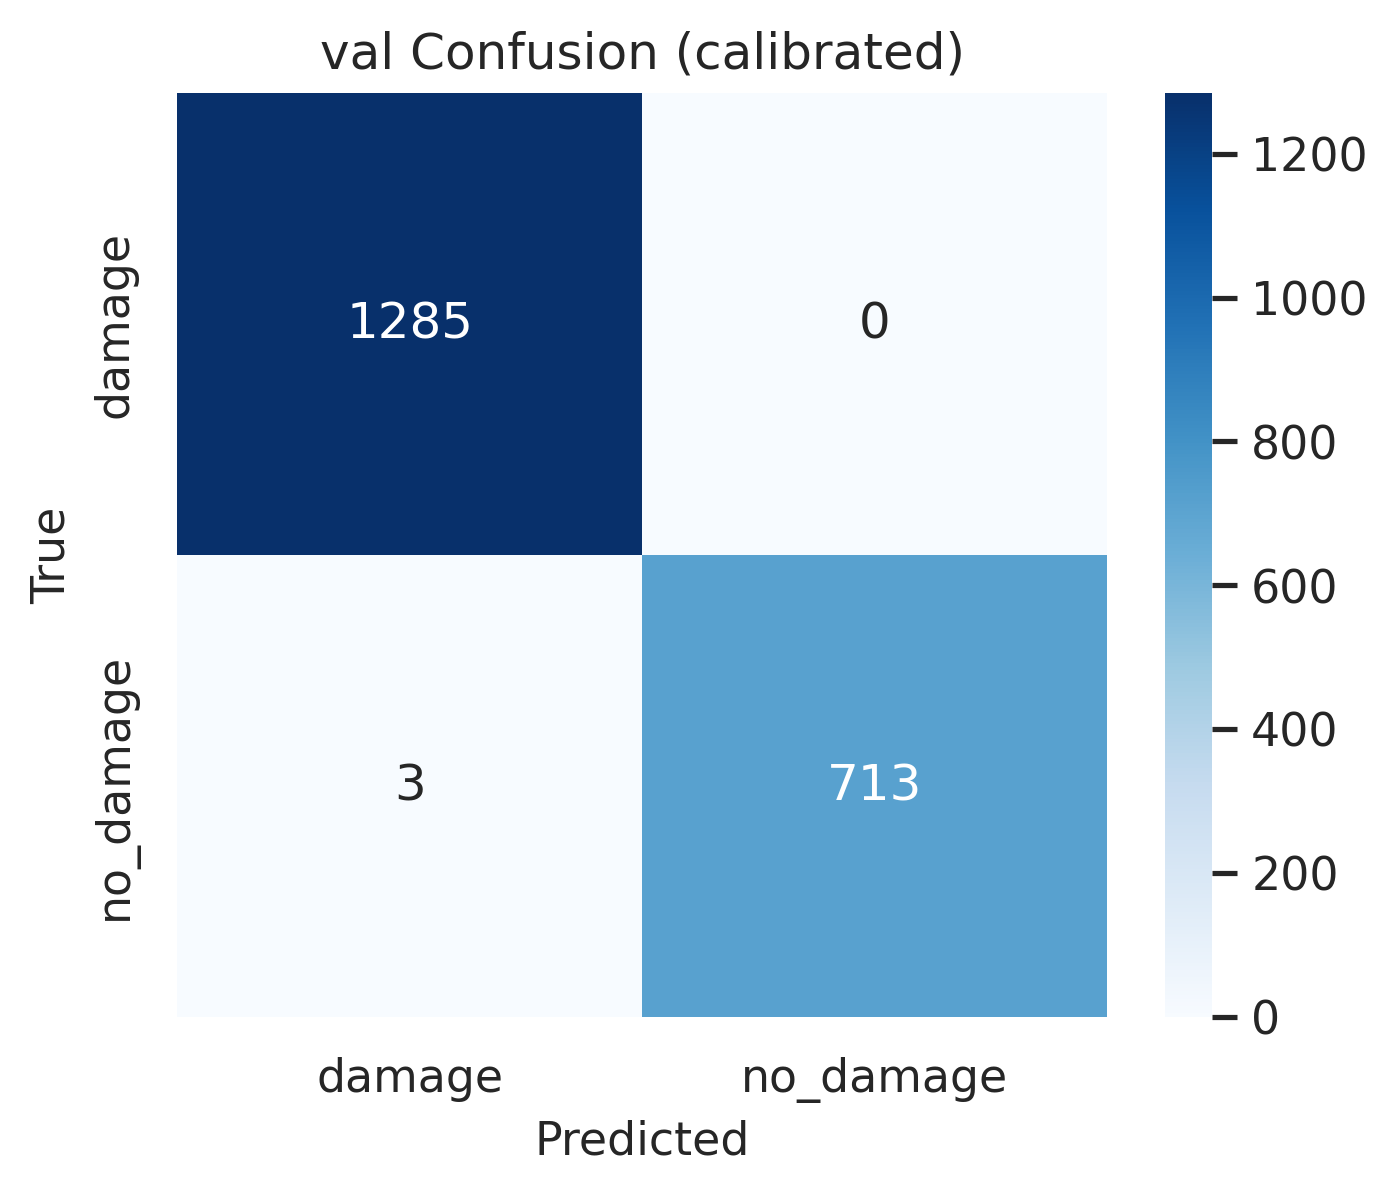

Saved figure to ../training_runs/resampled_20251206-154401_resnet34/eval_plots/eval_val_calibrated_score_hist.pdf


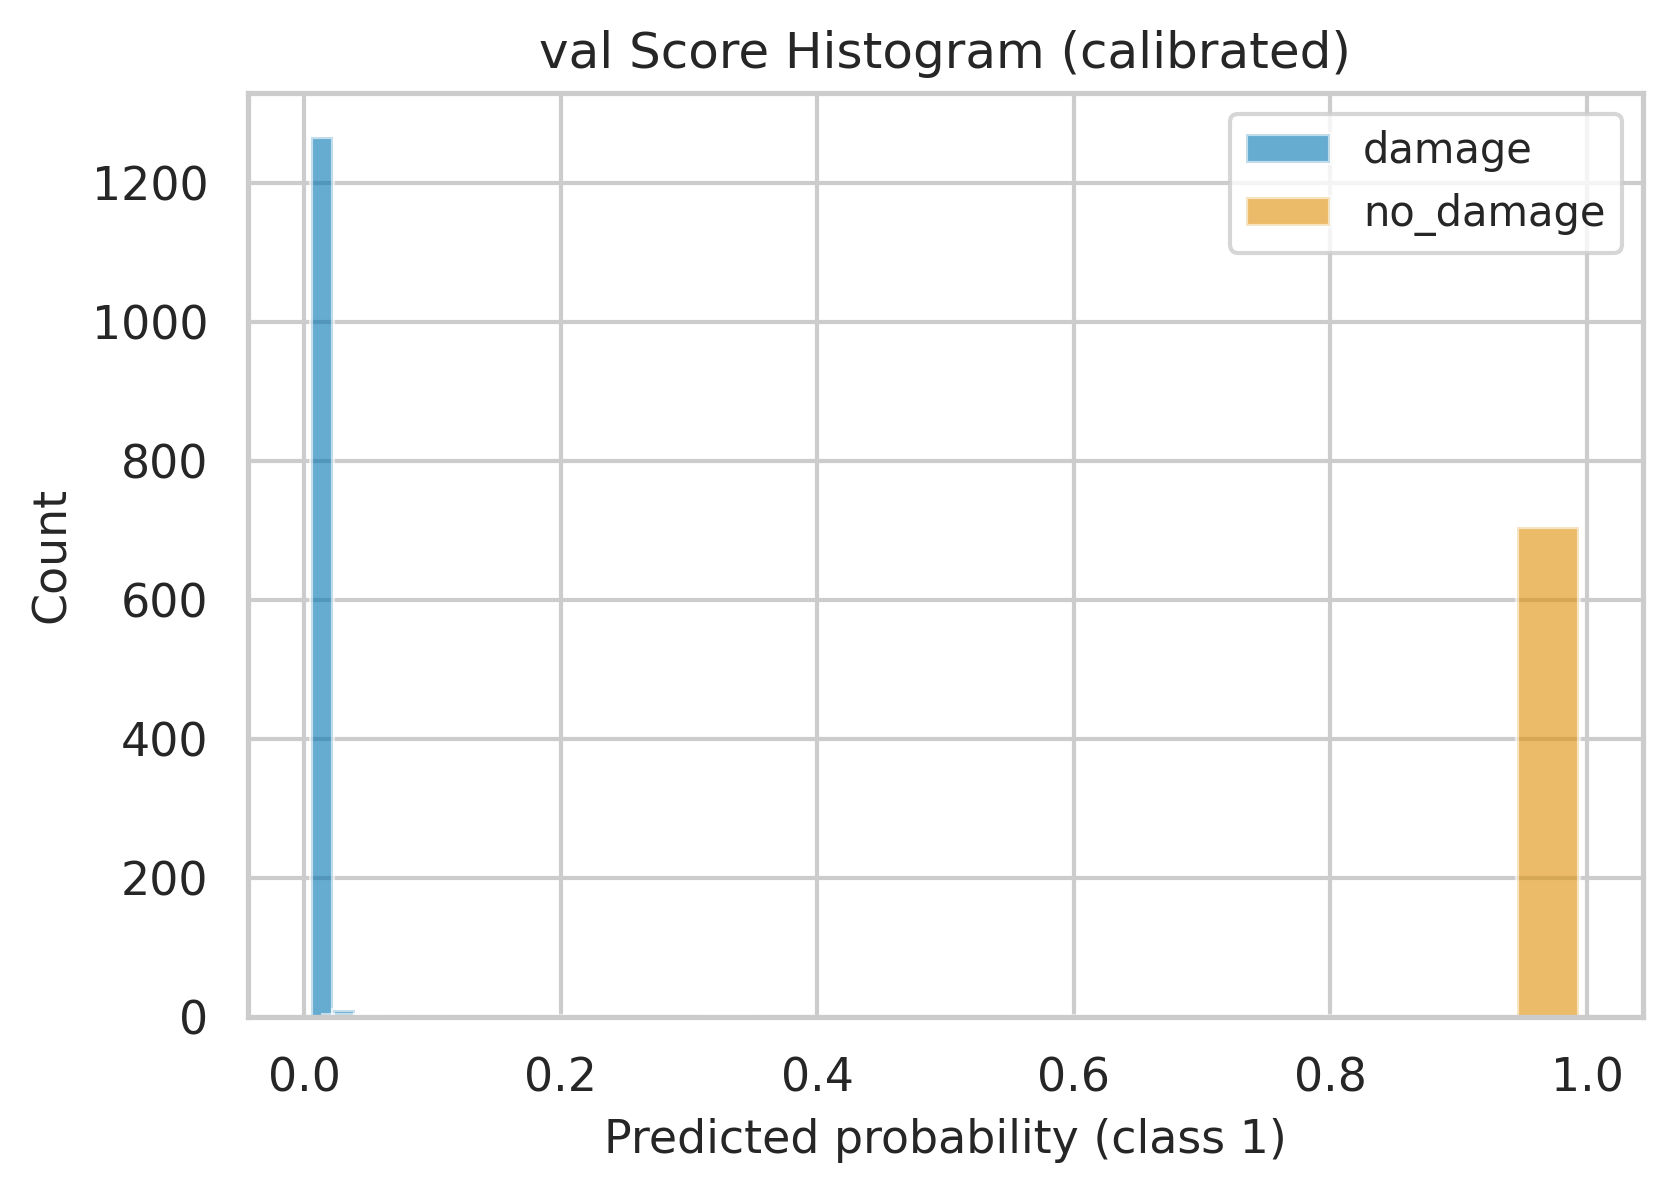

Saved figure to ../training_runs/resampled_20251206-154401_resnet34/eval_plots/eval_val_calibrated_reliability.pdf


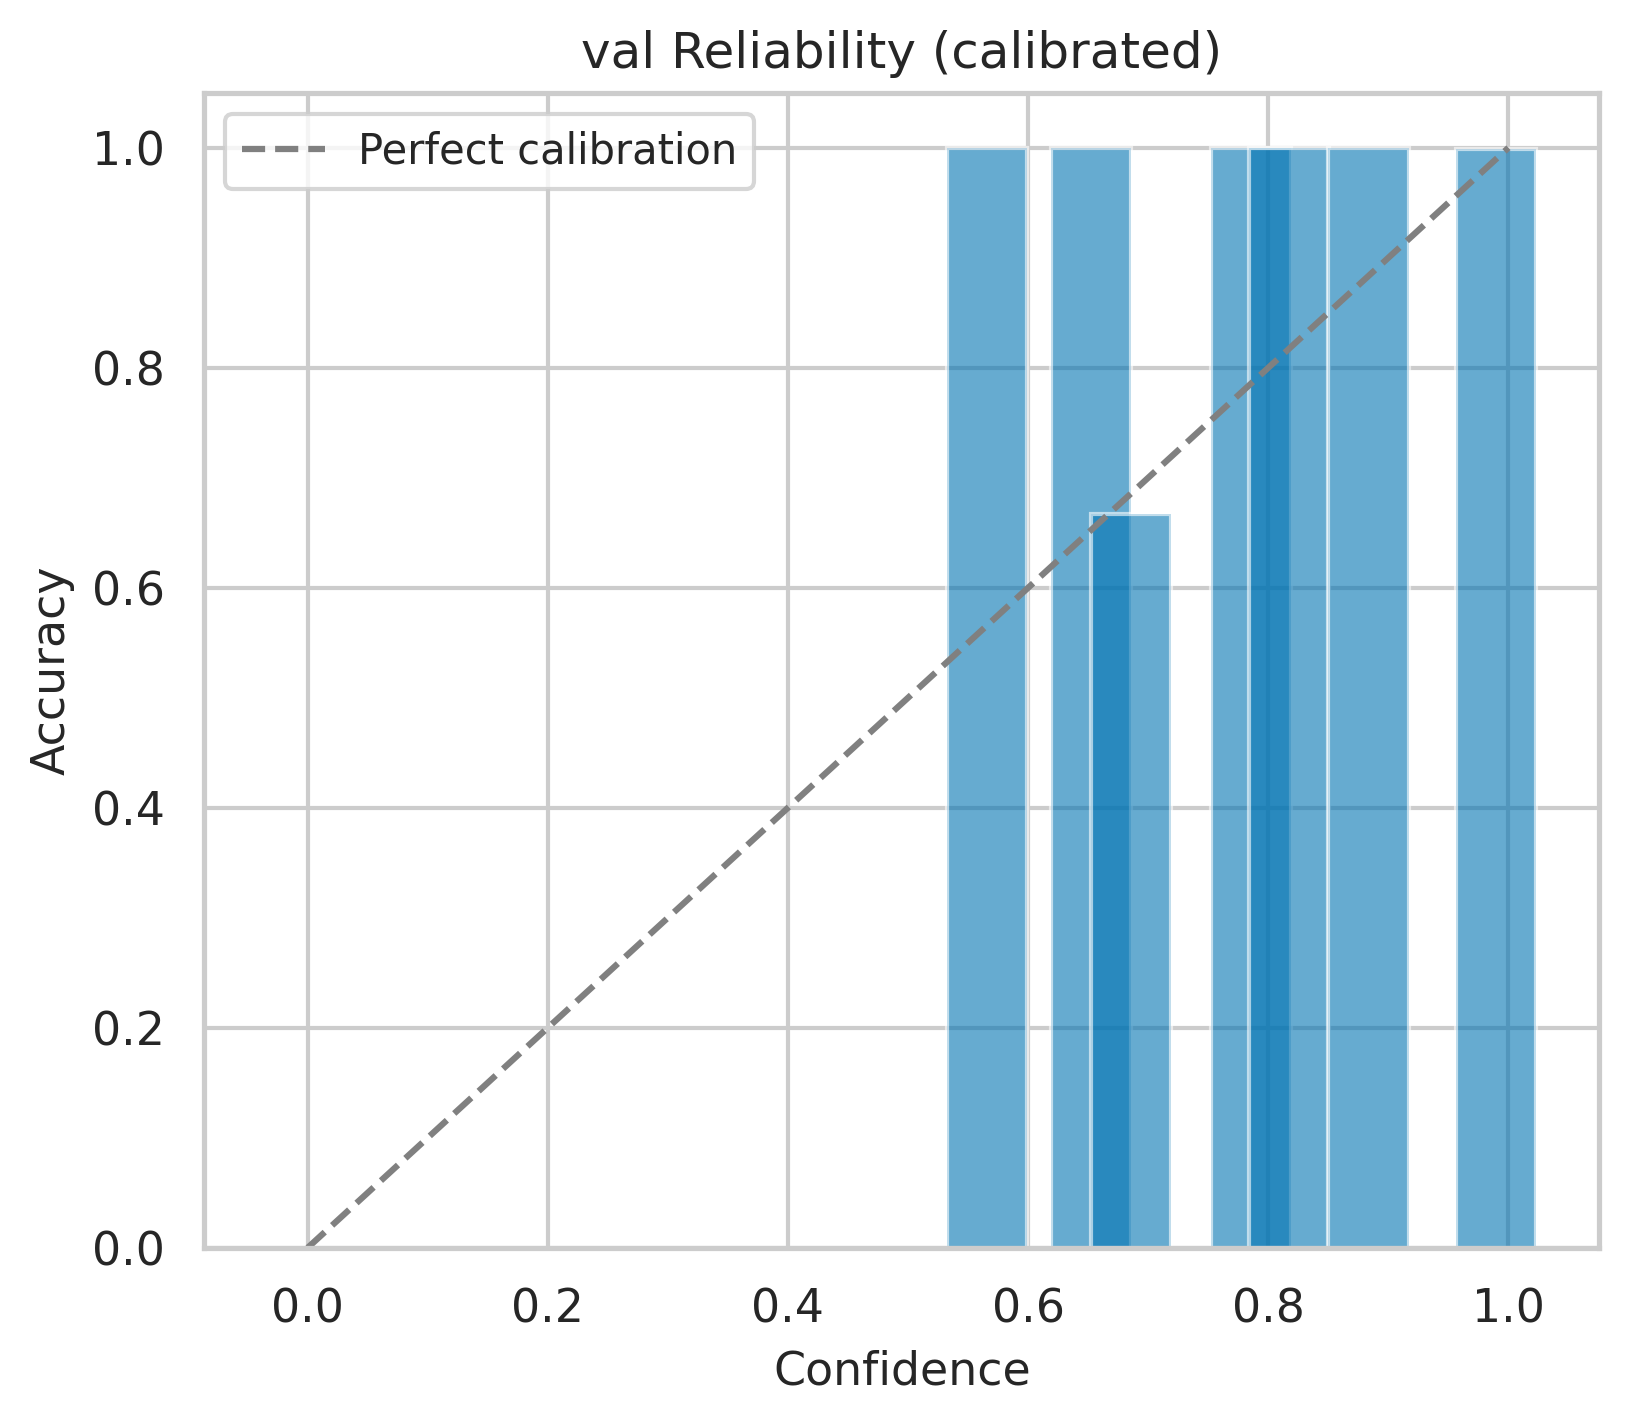

Saved figure to ../training_runs/resampled_20251206-154401_resnet34/eval_plots/eval_test_calibrated_confusion.pdf


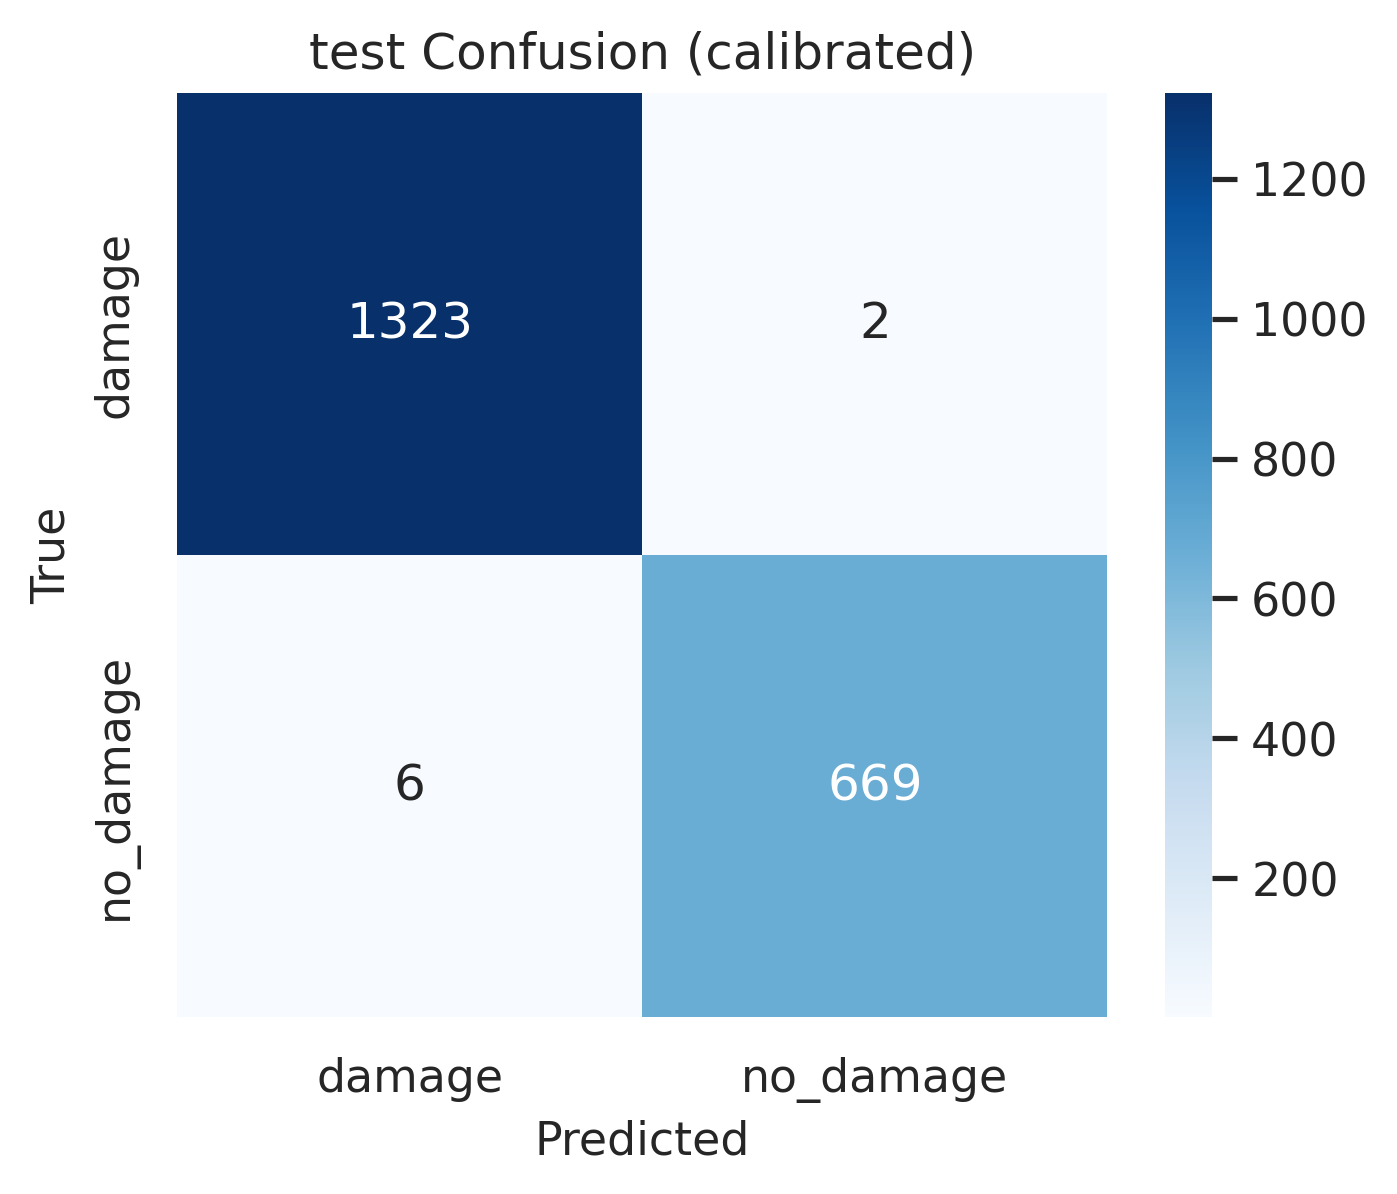

Saved figure to ../training_runs/resampled_20251206-154401_resnet34/eval_plots/eval_test_calibrated_score_hist.pdf


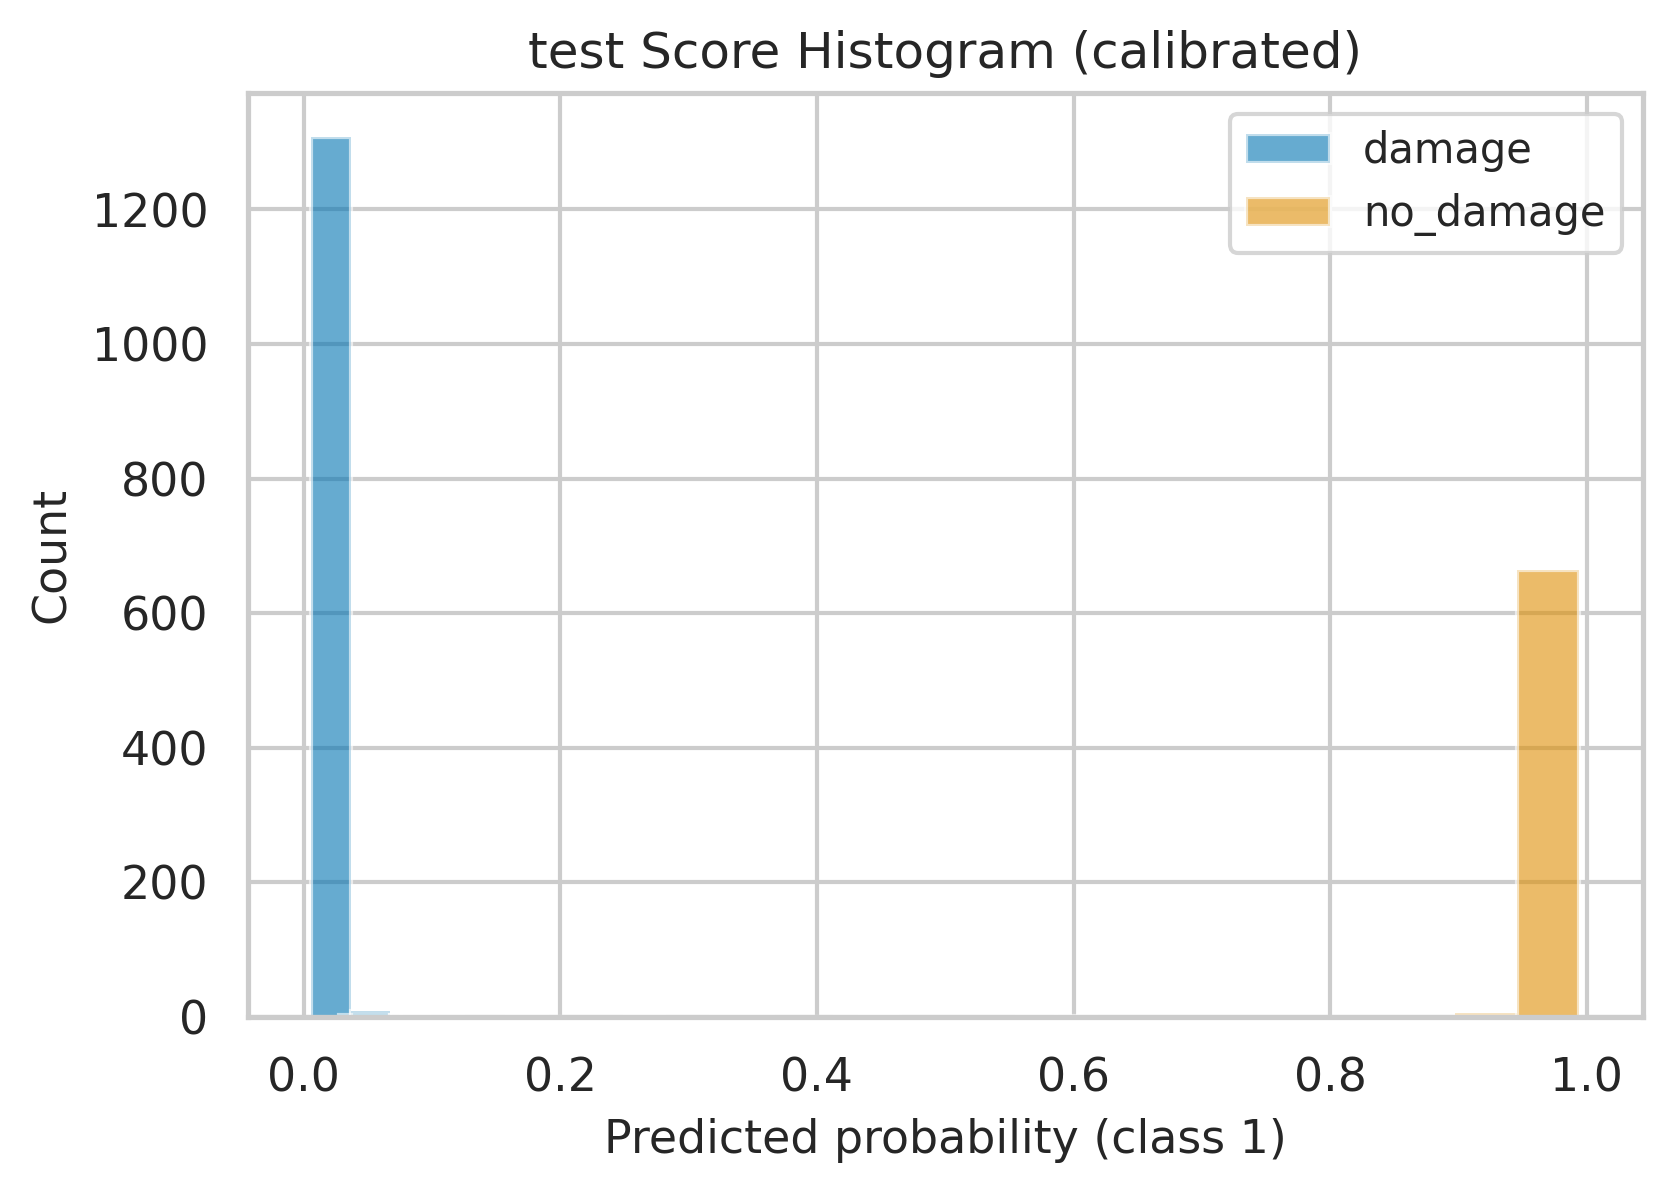

Saved figure to ../training_runs/resampled_20251206-154401_resnet34/eval_plots/eval_test_calibrated_reliability.pdf


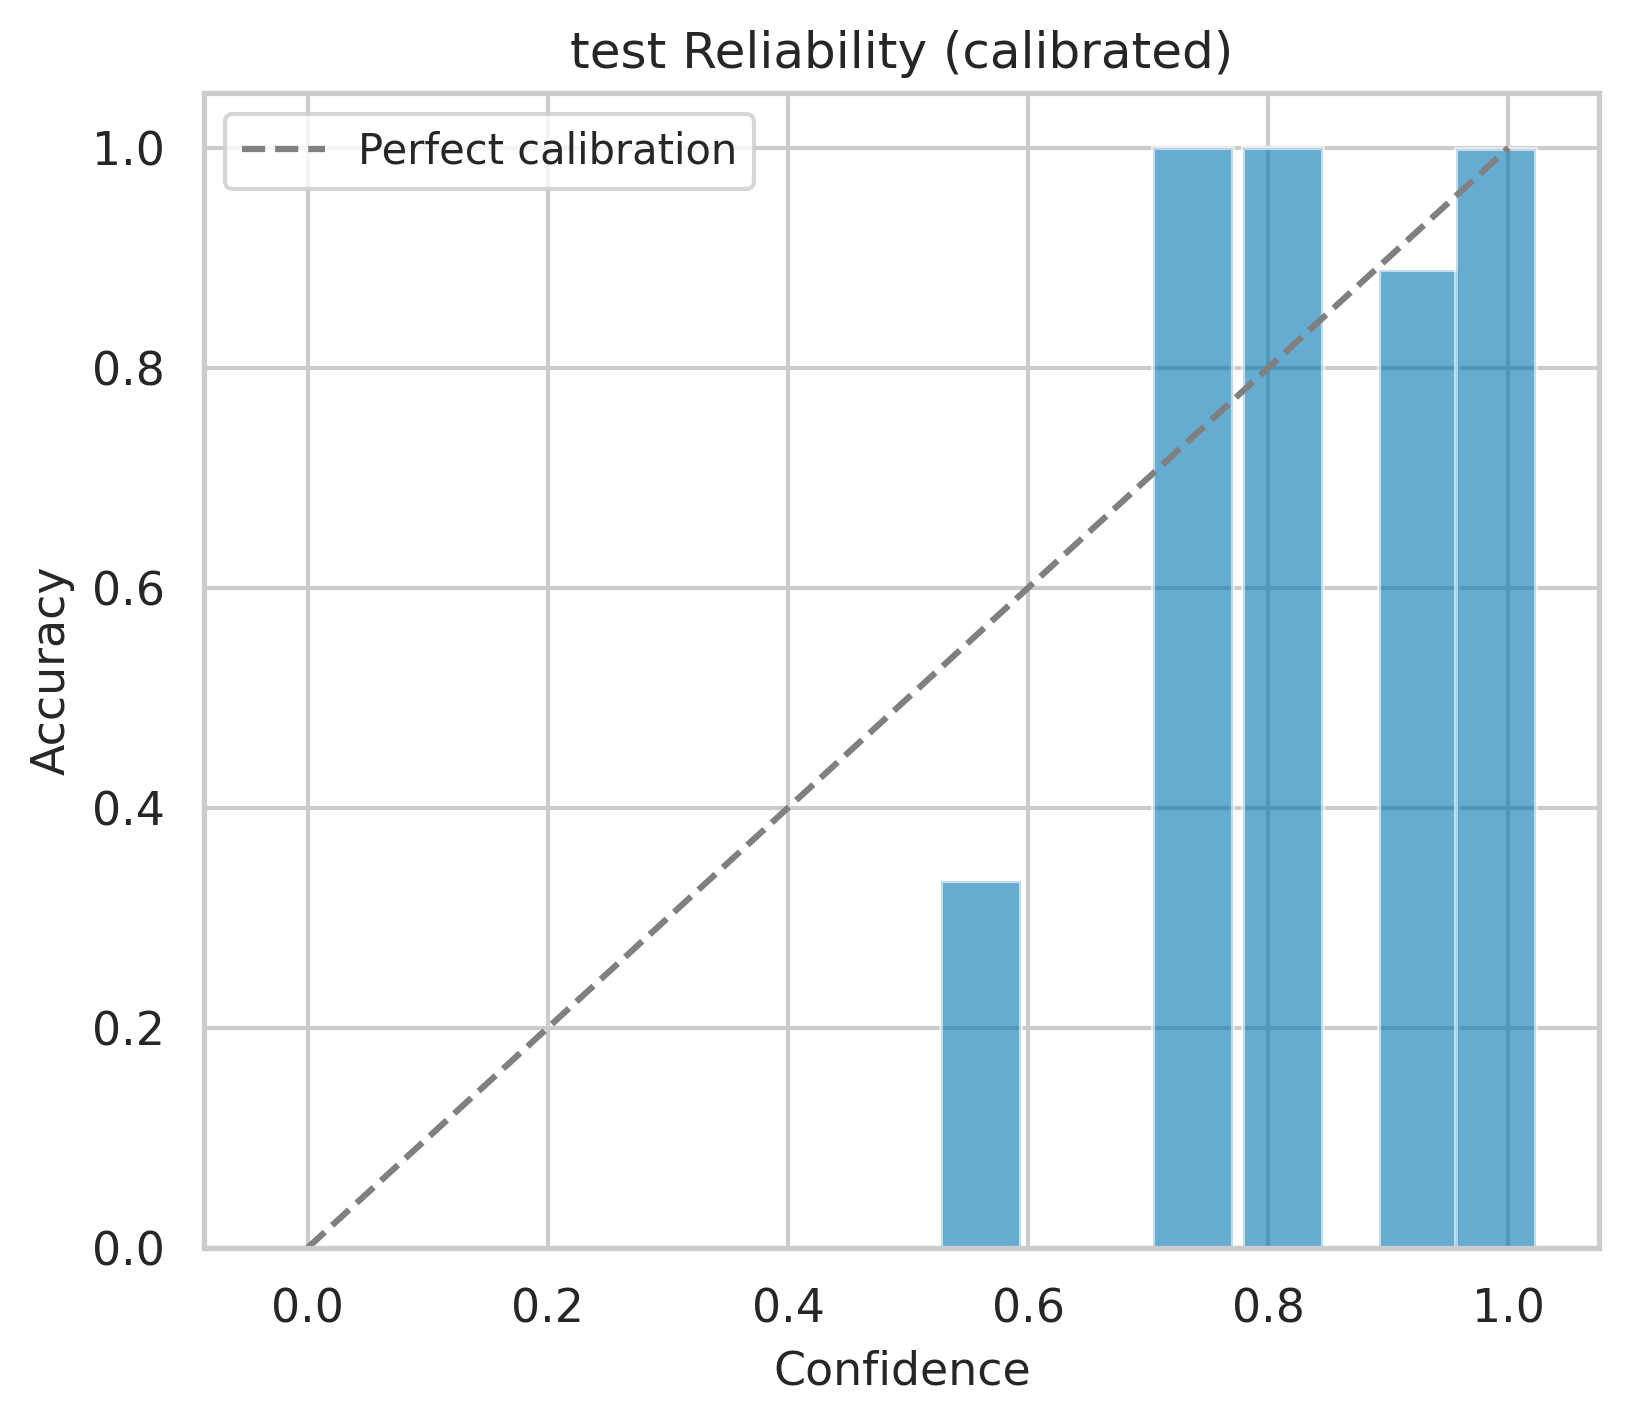

Saved eval metrics to ../training_runs/resampled_20251206-154401_resnet34/eval_metrics.json
Fitted temperature: 0.7924
Test metrics (raw): {'accuracy': 0.996, 'macro_precision': 0.996252350691162, 'macro_recall': 0.9948008385744236, 'macro_f1': 0.9955210727926447, 'brier': 0.0033012716740009438, 'ece': 0.026821551680564878}
Test metrics (calibrated): {'accuracy': 0.996, 'macro_precision': 0.996252350691162, 'macro_recall': 0.9948008385744236, 'macro_f1': 0.9955210727926447, 'brier': 0.0028233844085682673, 'ece': 0.010342171490192457}


In [6]:
resnet34_eval = evaluate_run("resnet34")

Saved figure to ../training_runs/resampled_20251206-154401_resnet50/eval_plots/eval_val_raw_confusion.pdf


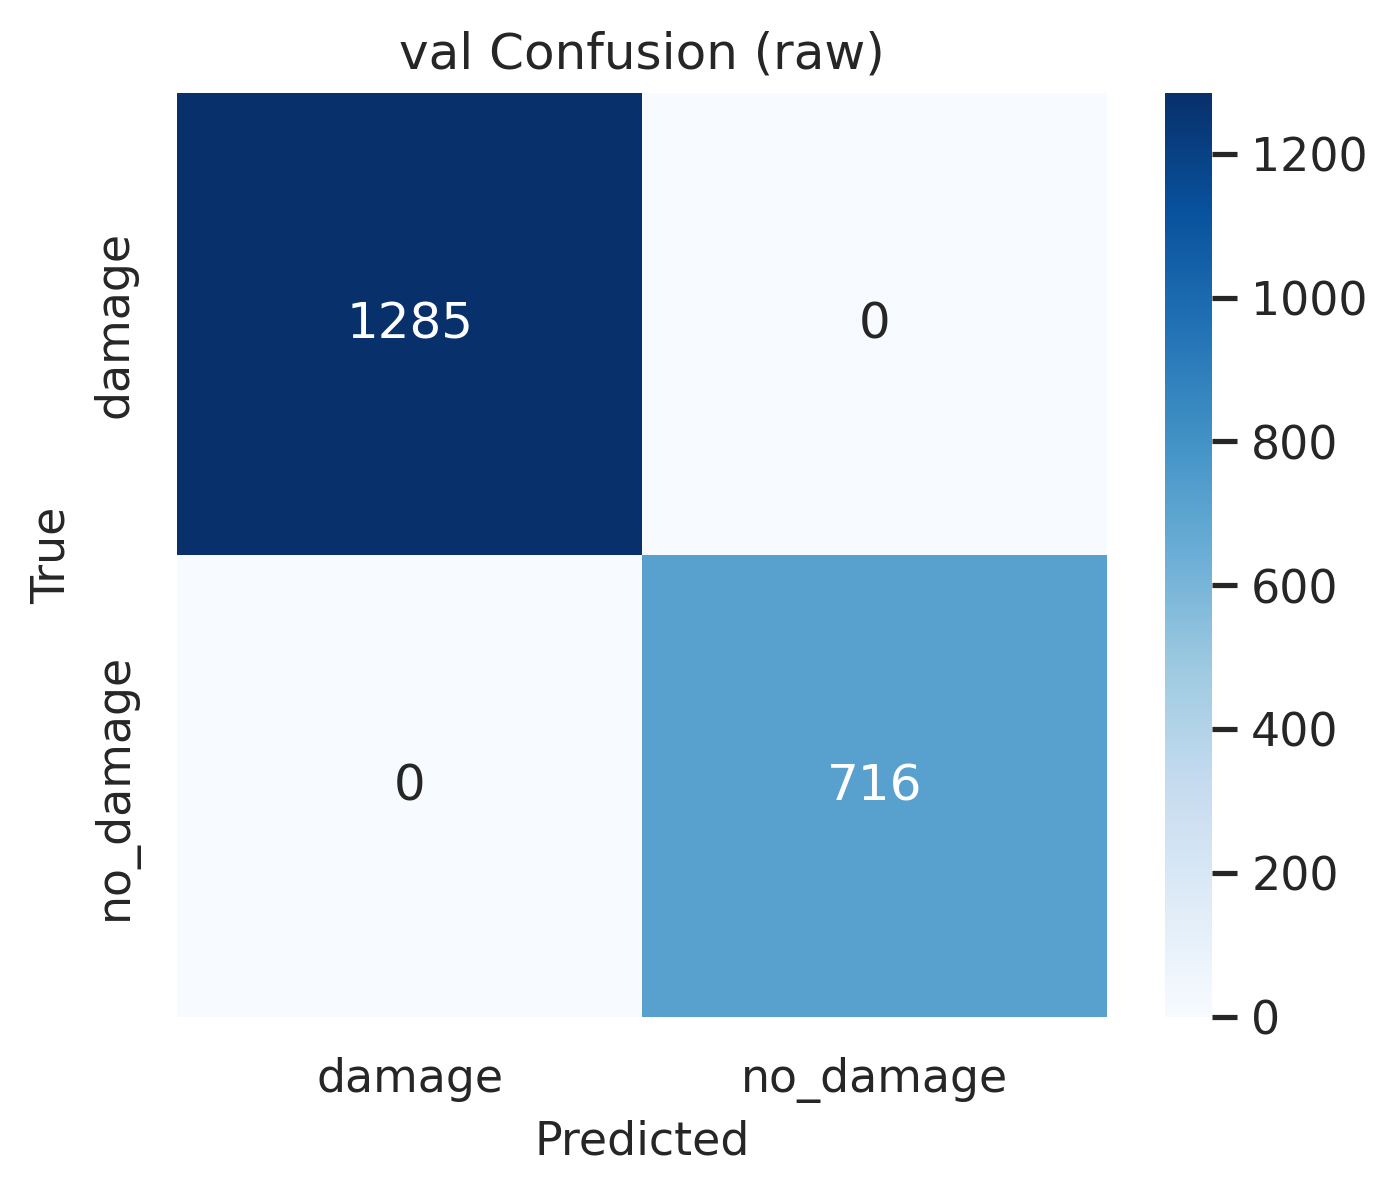

Saved figure to ../training_runs/resampled_20251206-154401_resnet50/eval_plots/eval_val_raw_score_hist.pdf


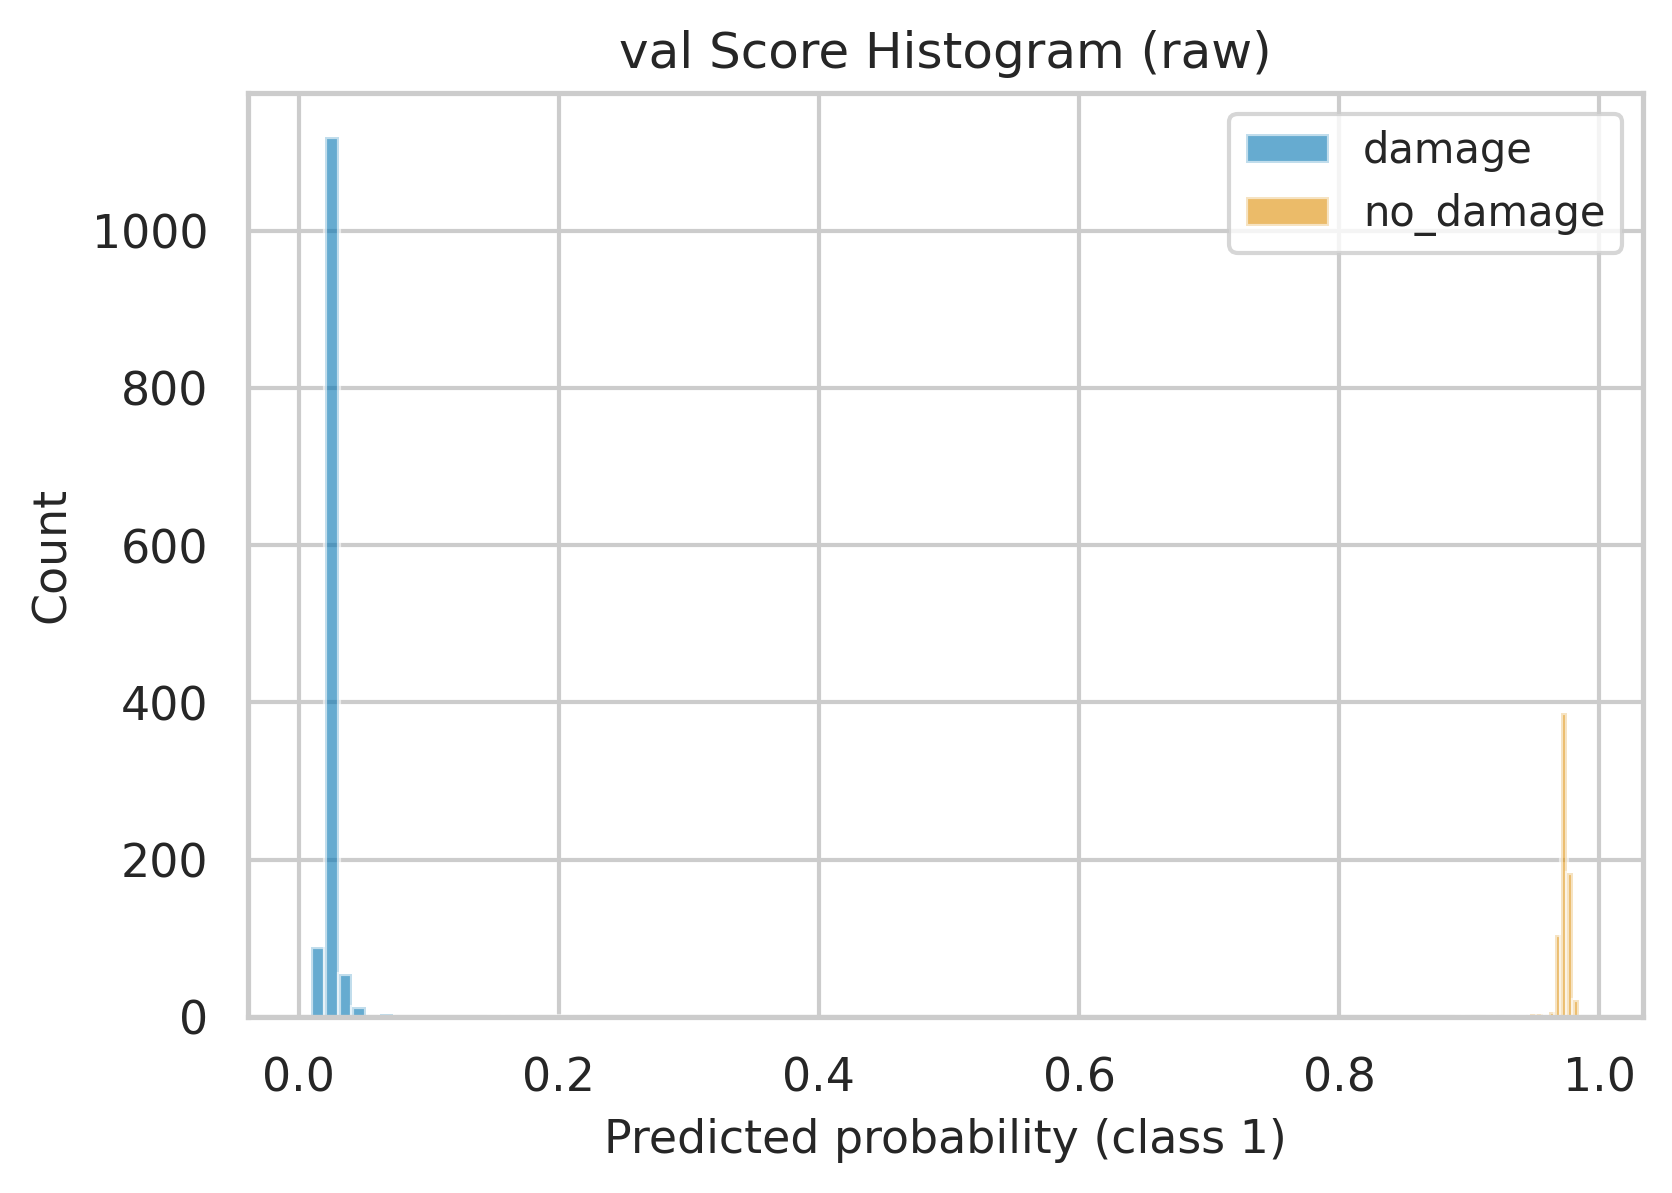

Saved figure to ../training_runs/resampled_20251206-154401_resnet50/eval_plots/eval_val_raw_reliability.pdf


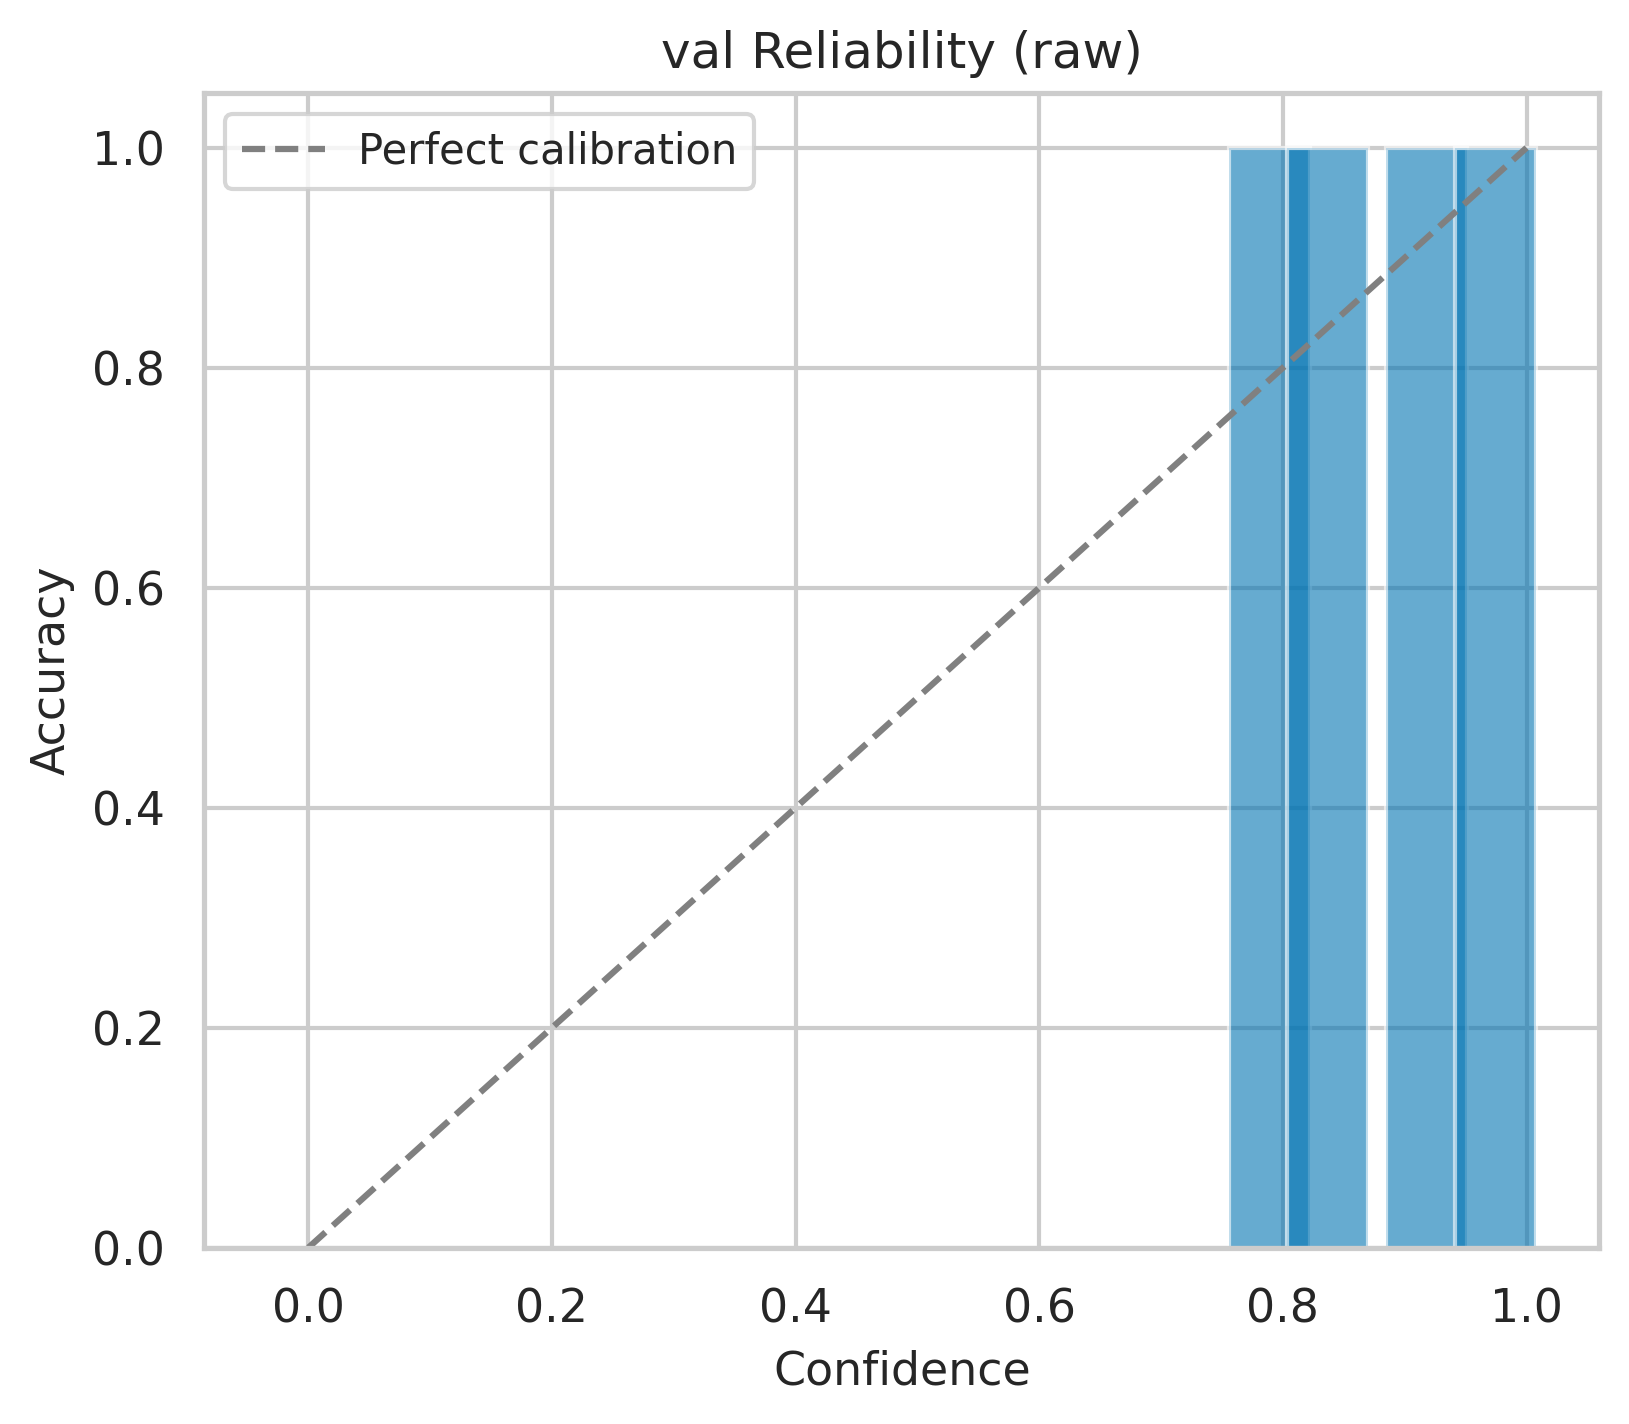

Saved figure to ../training_runs/resampled_20251206-154401_resnet50/eval_plots/eval_test_raw_confusion.pdf


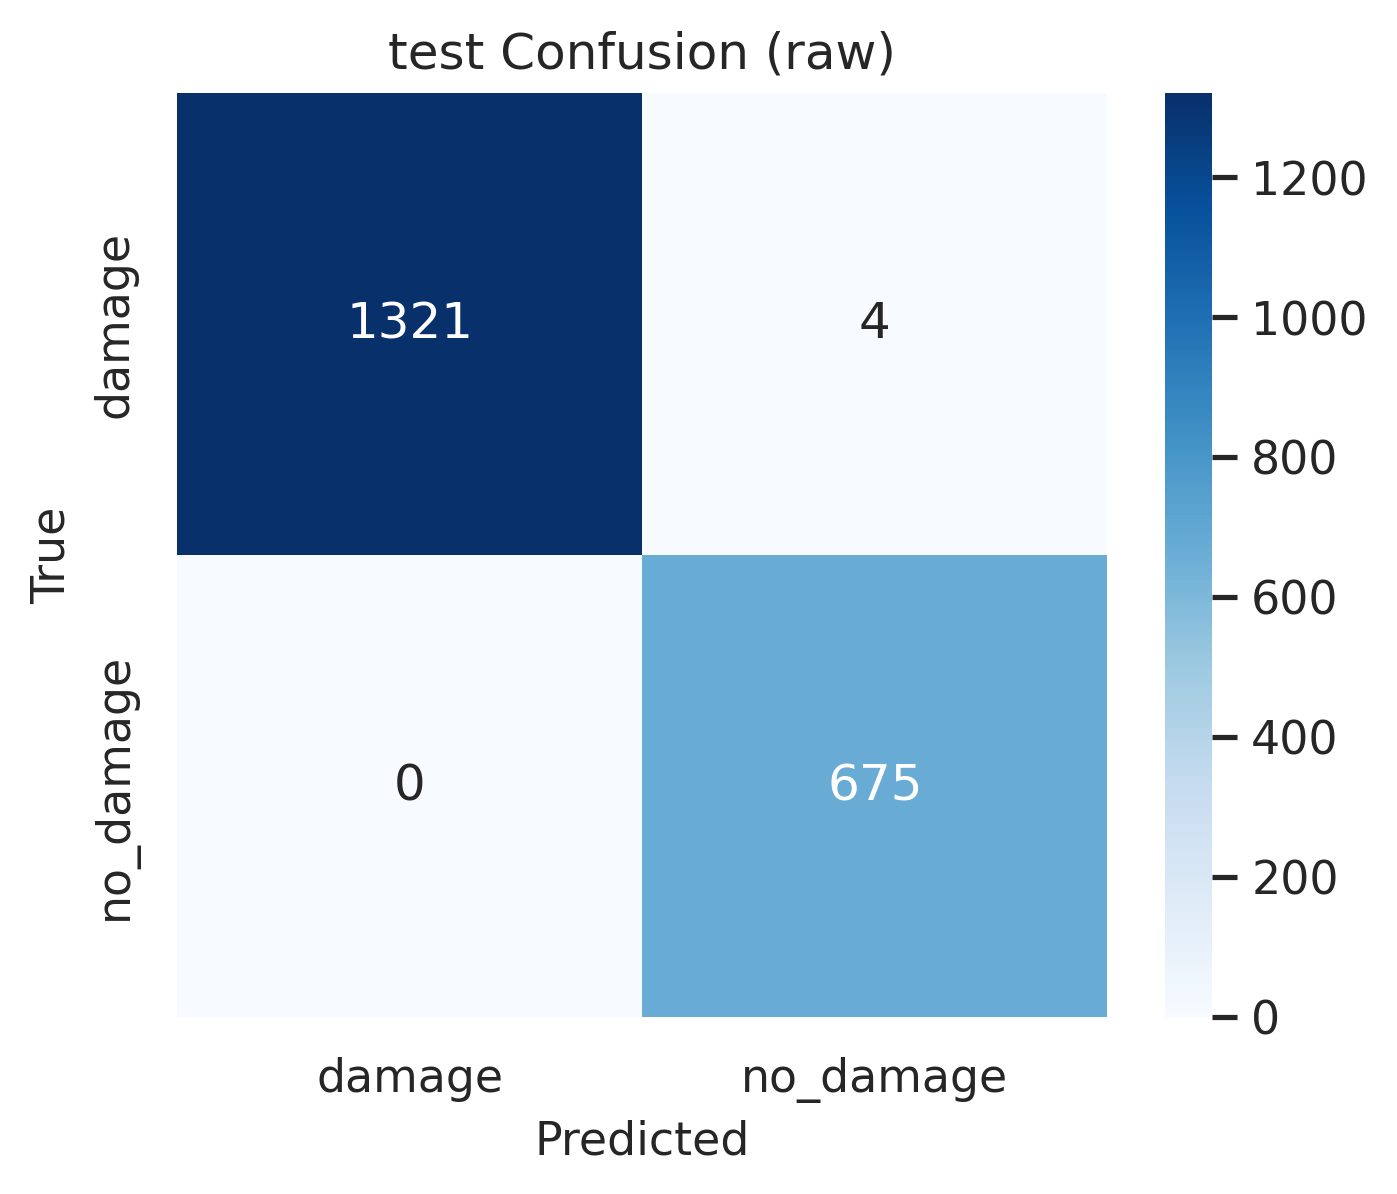

Saved figure to ../training_runs/resampled_20251206-154401_resnet50/eval_plots/eval_test_raw_score_hist.pdf


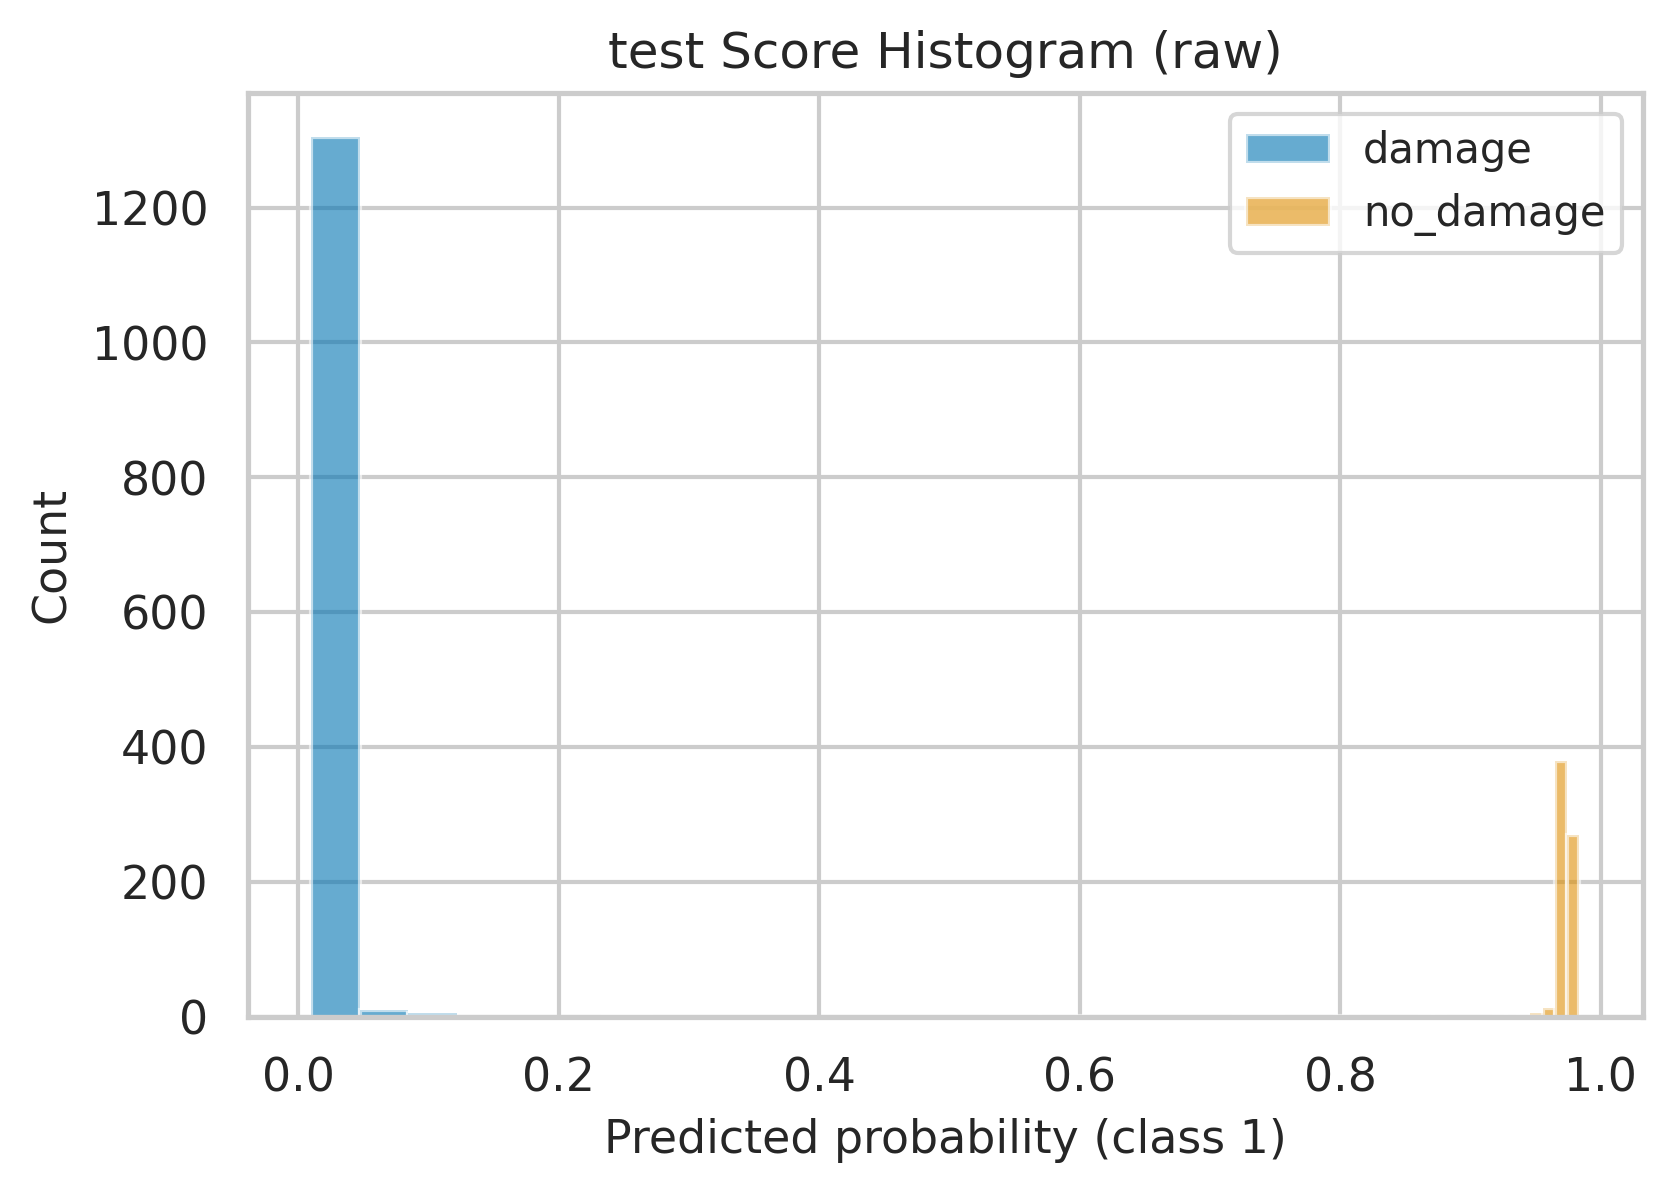

Saved figure to ../training_runs/resampled_20251206-154401_resnet50/eval_plots/eval_test_raw_reliability.pdf


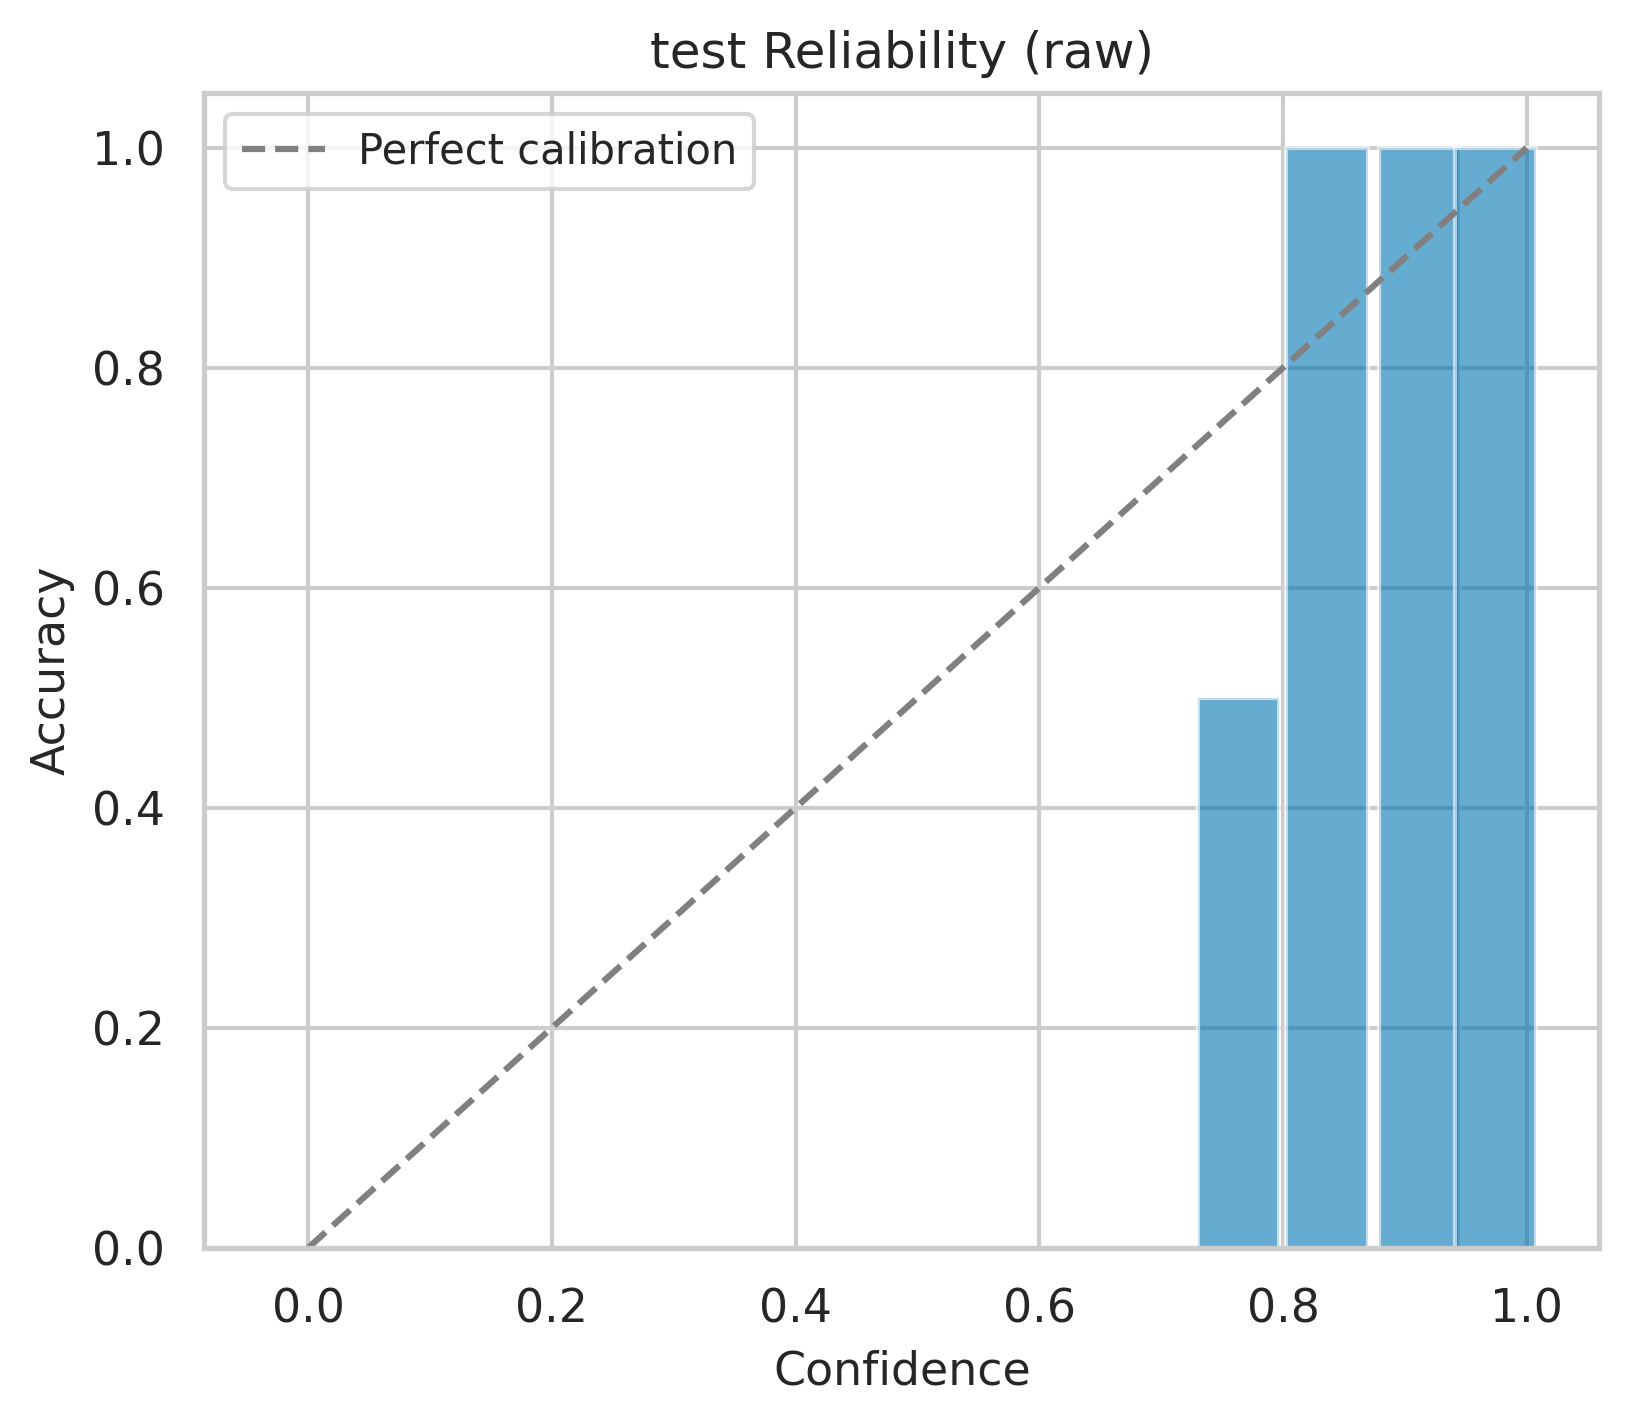

Saved figure to ../training_runs/resampled_20251206-154401_resnet50/eval_plots/eval_val_calibrated_confusion.pdf


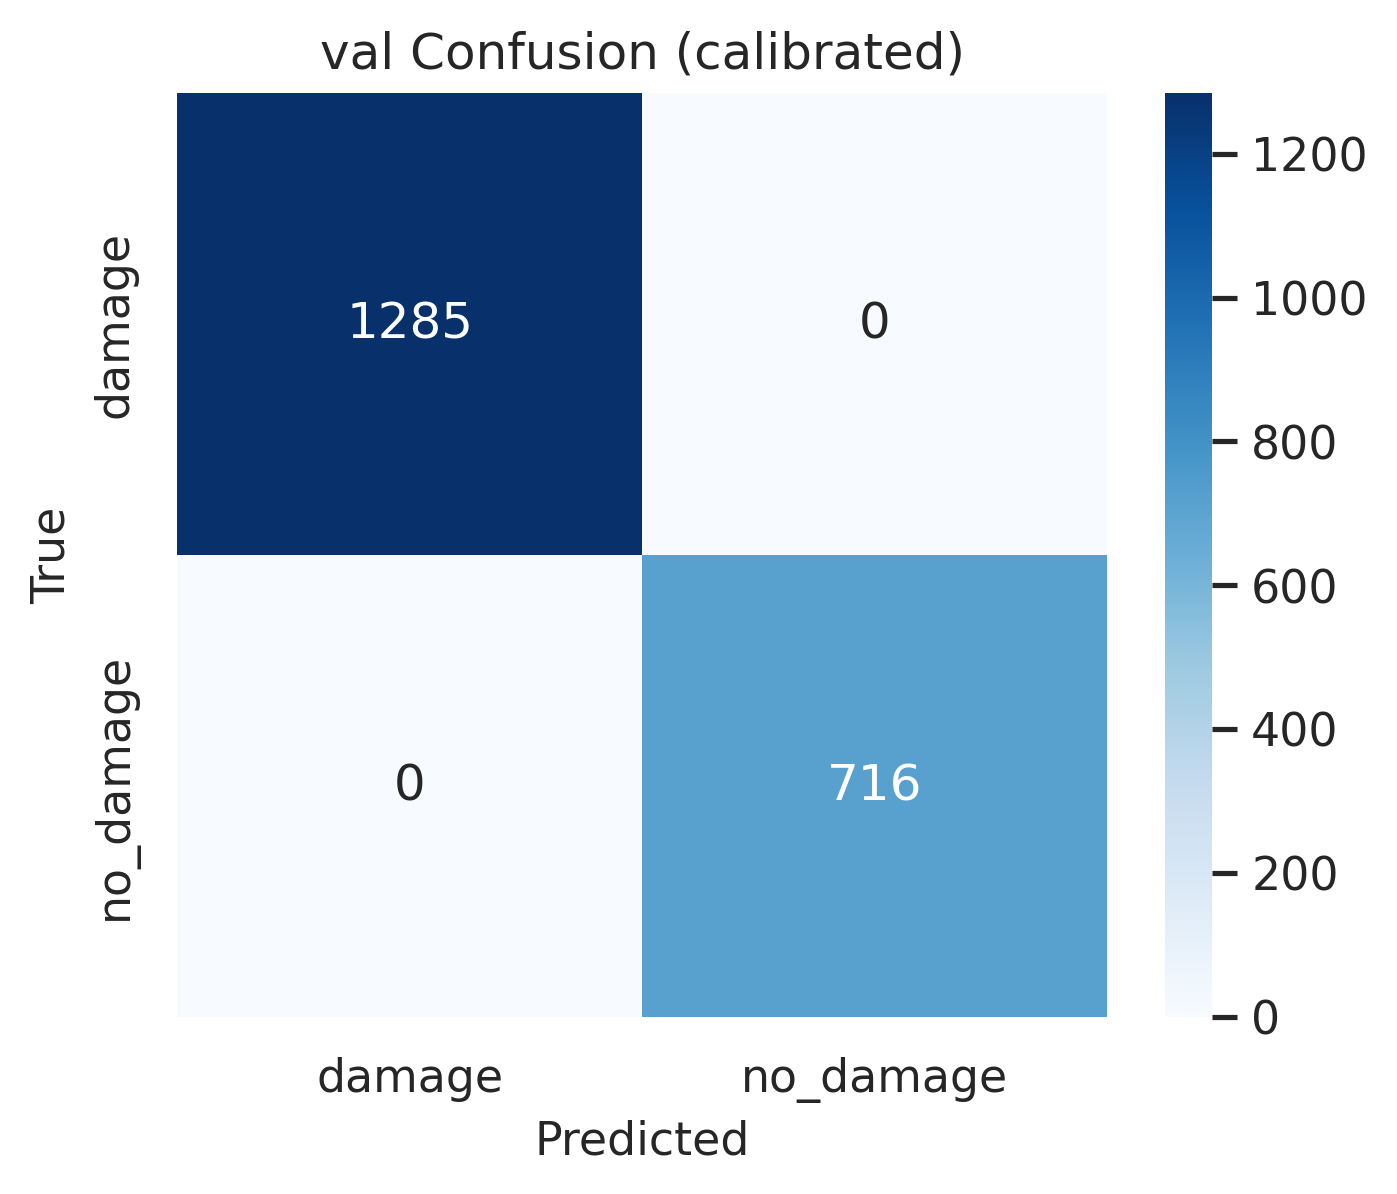

Saved figure to ../training_runs/resampled_20251206-154401_resnet50/eval_plots/eval_val_calibrated_score_hist.pdf


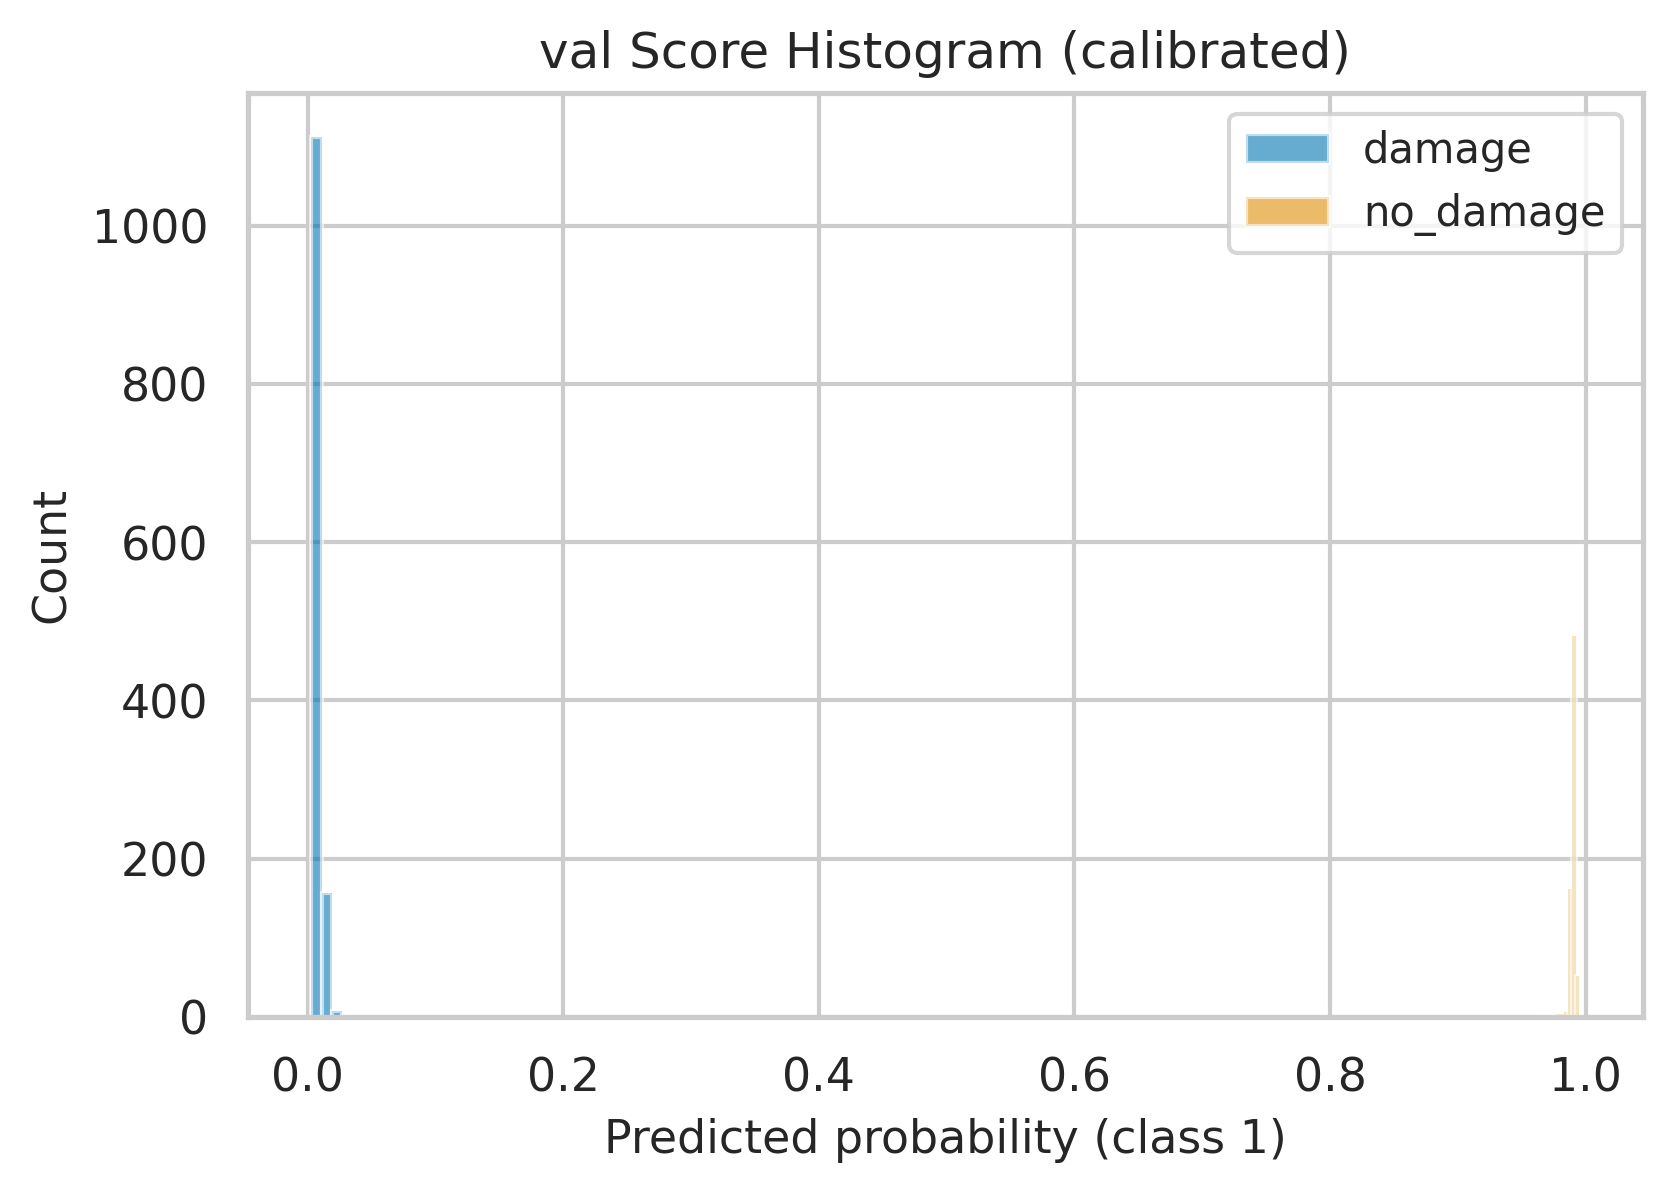

Saved figure to ../training_runs/resampled_20251206-154401_resnet50/eval_plots/eval_val_calibrated_reliability.pdf


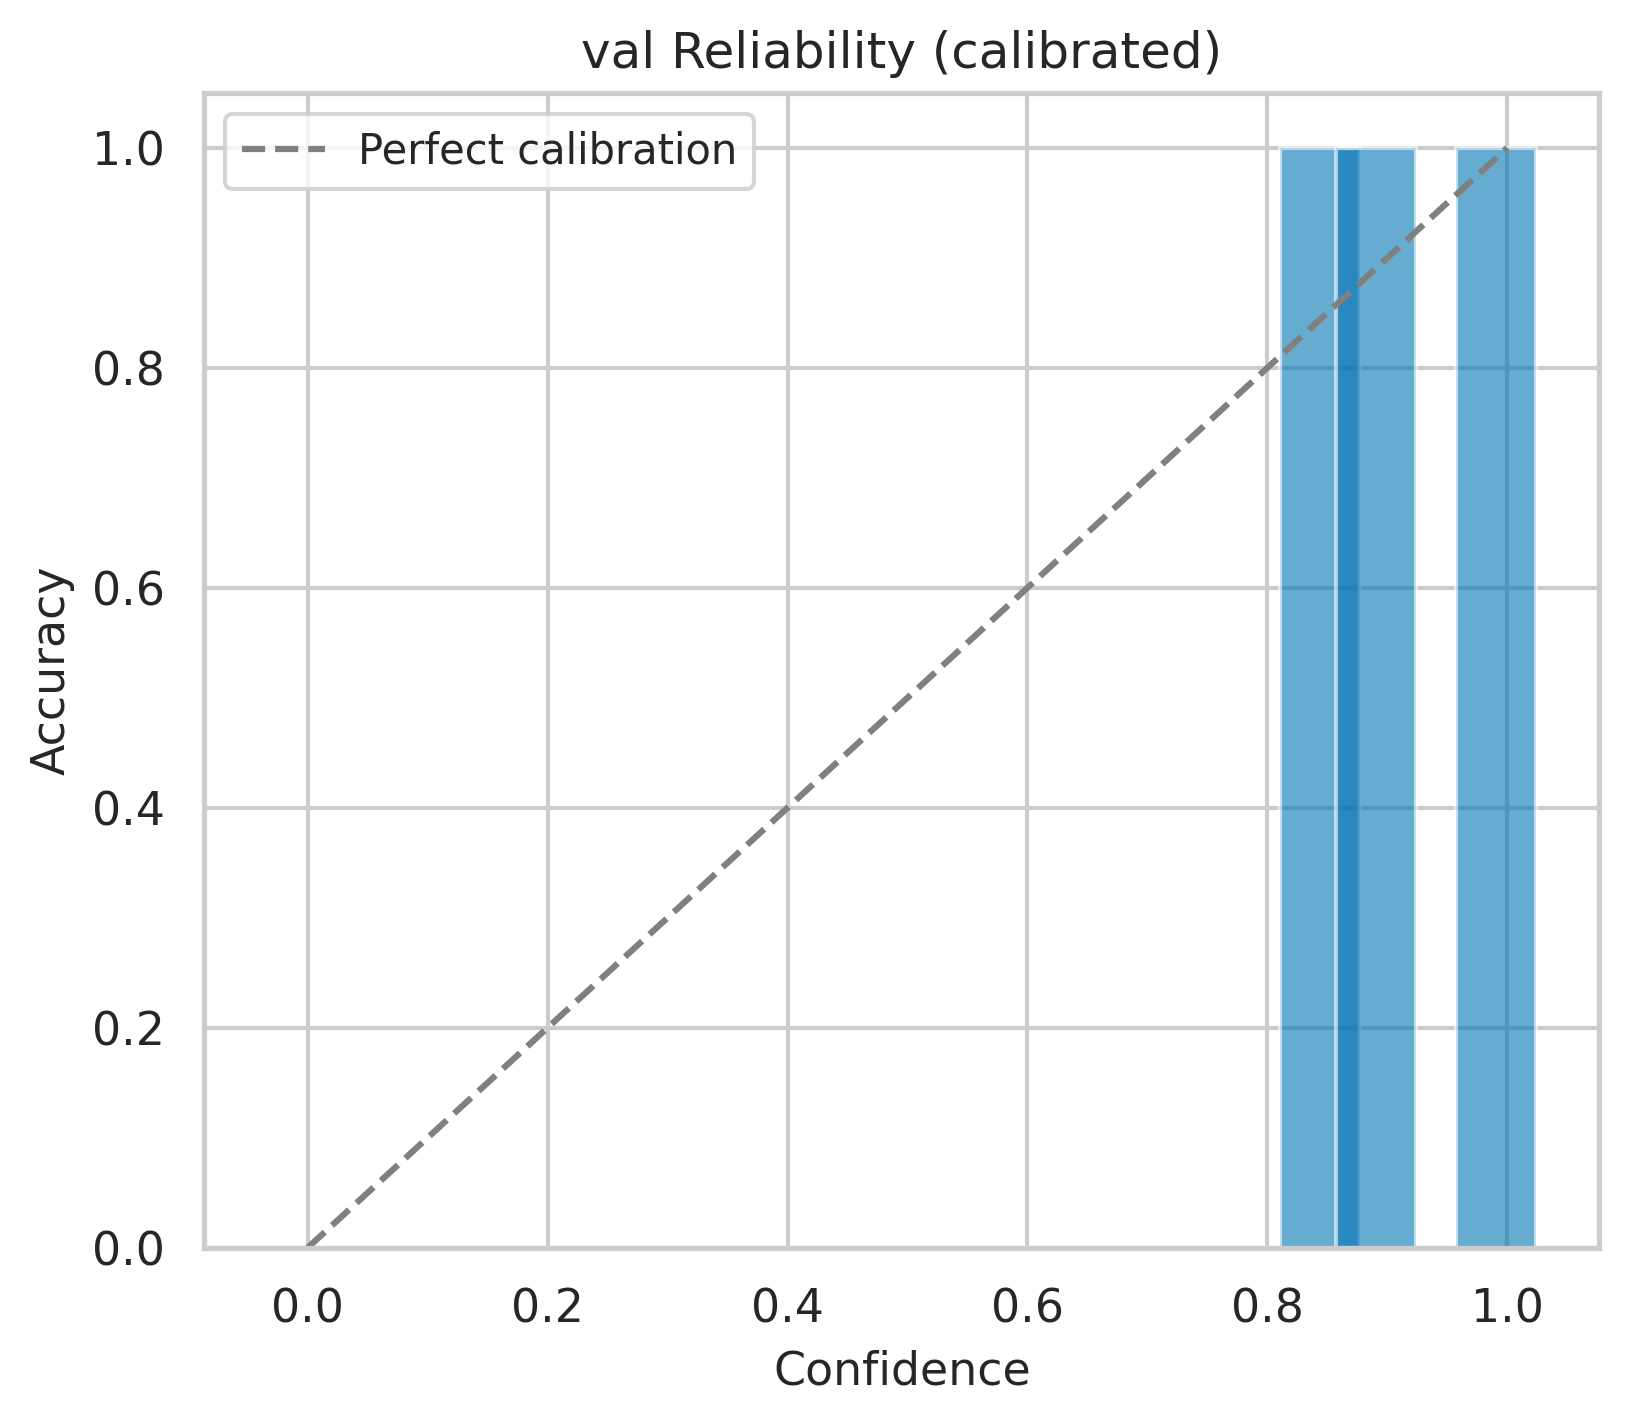

Saved figure to ../training_runs/resampled_20251206-154401_resnet50/eval_plots/eval_test_calibrated_confusion.pdf


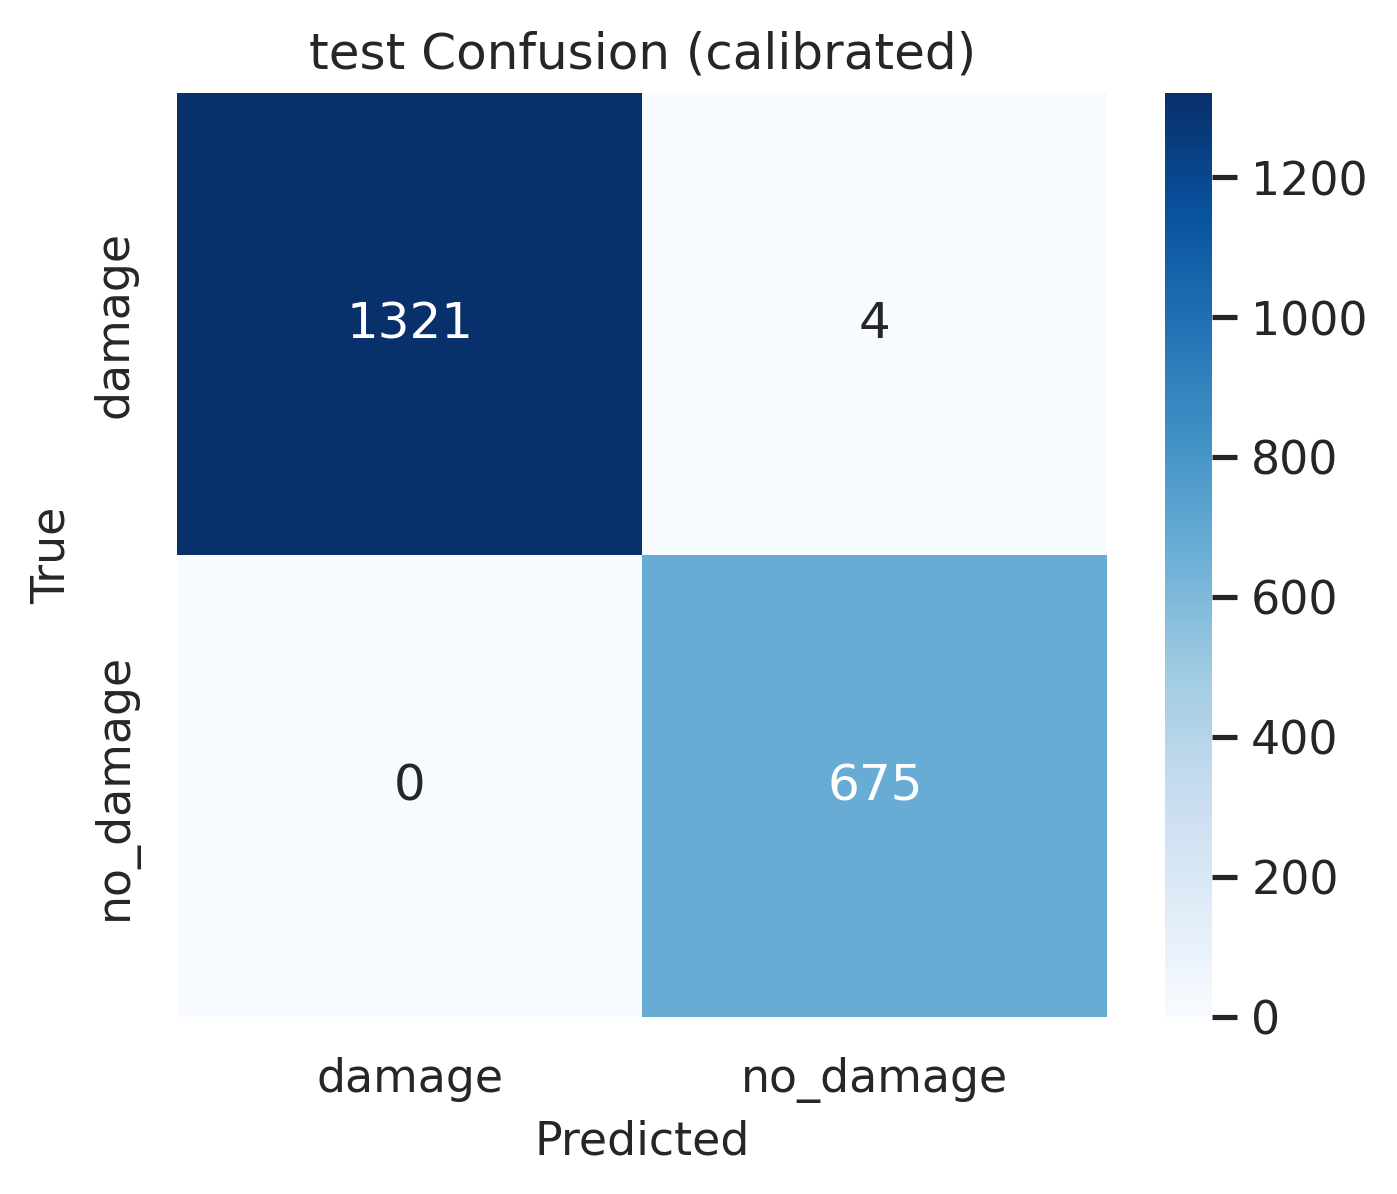

Saved figure to ../training_runs/resampled_20251206-154401_resnet50/eval_plots/eval_test_calibrated_score_hist.pdf


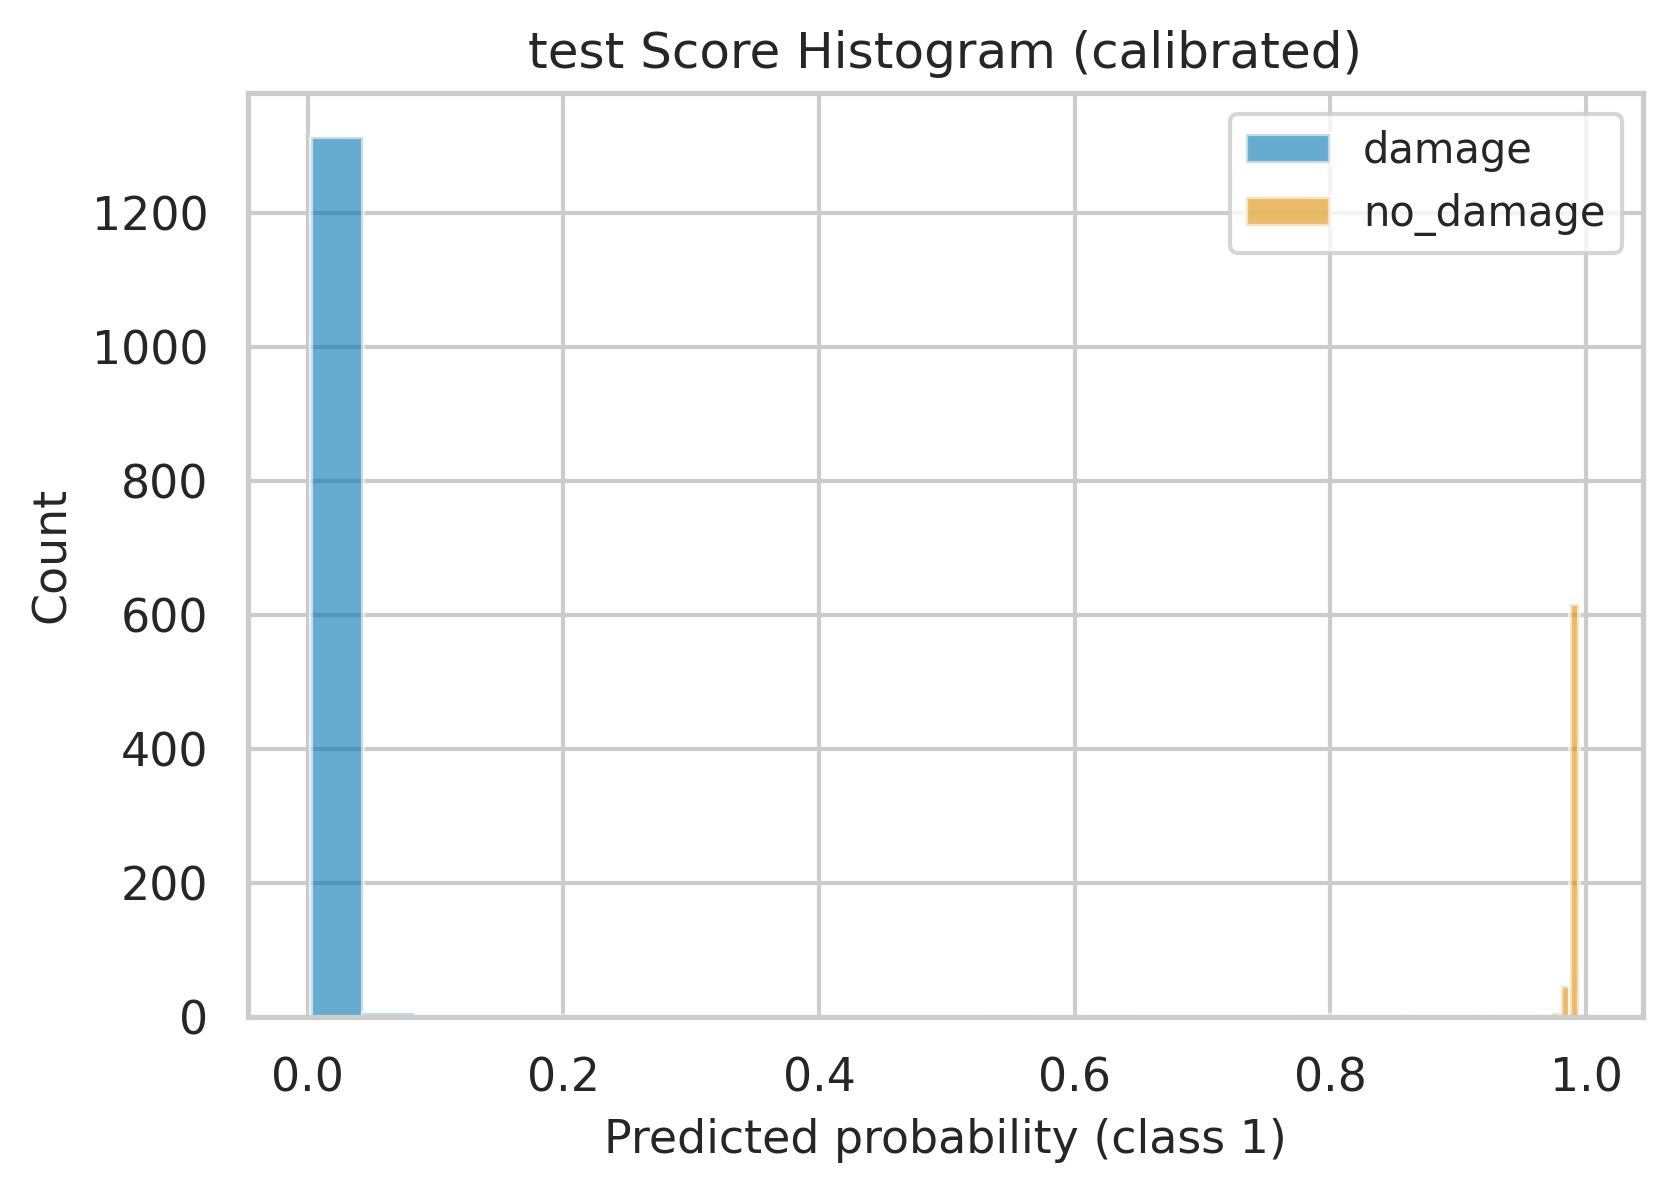

Saved figure to ../training_runs/resampled_20251206-154401_resnet50/eval_plots/eval_test_calibrated_reliability.pdf


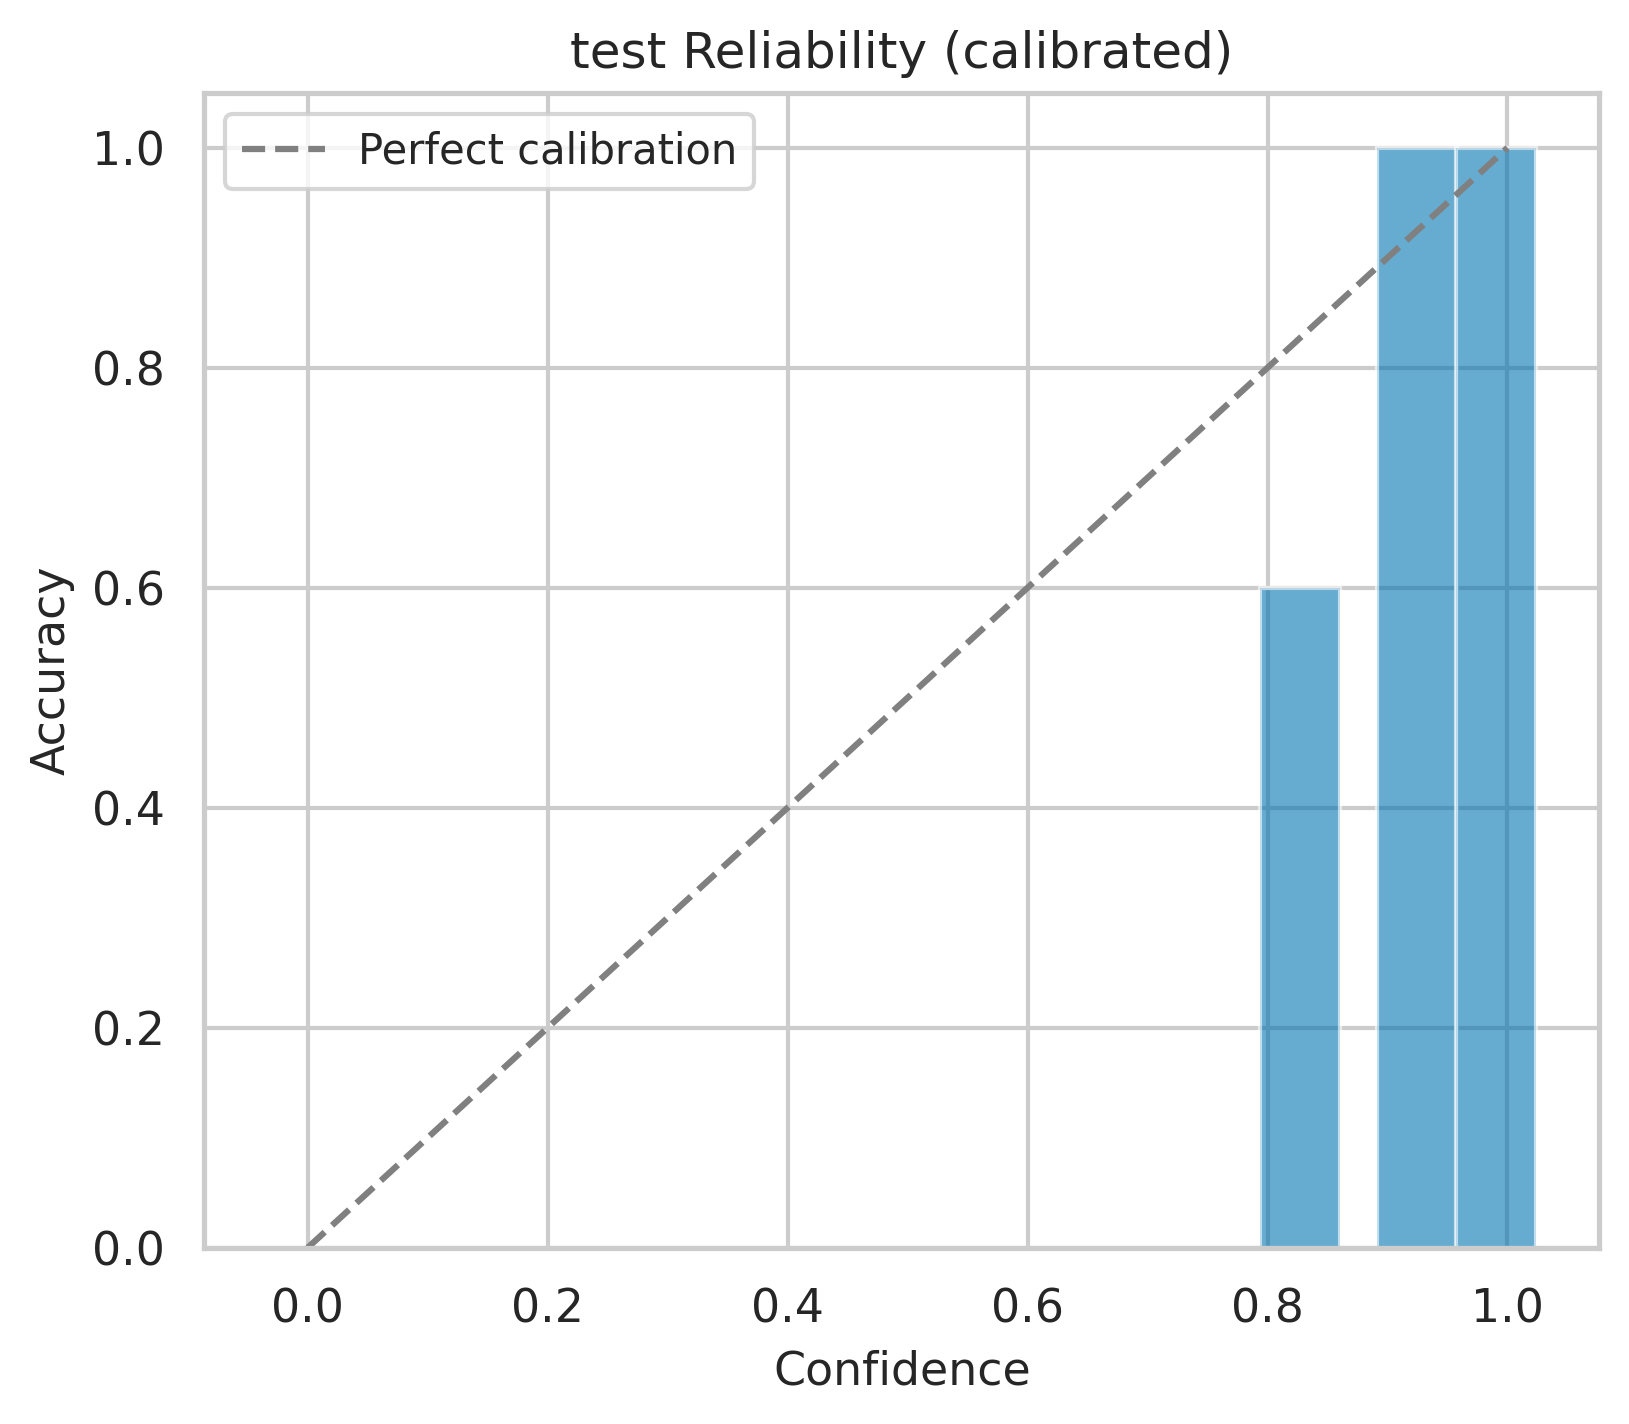

Saved eval metrics to ../training_runs/resampled_20251206-154401_resnet50/eval_metrics.json
Fitted temperature: 0.7807
Test metrics (raw): {'accuracy': 0.998, 'macro_precision': 0.9970544918998527, 'macro_recall': 0.9984905660377359, 'macro_f1': 0.9977670372268389, 'brier': 0.0017012953786378934, 'ece': 0.027340321838855743}
Test metrics (calibrated): {'accuracy': 0.998, 'macro_precision': 0.9970544918998527, 'macro_recall': 0.9984905660377359, 'macro_f1': 0.9977670372268389, 'brier': 0.0011539278550370543, 'ece': 0.010905455768108368}


In [7]:
resnet50_eval = evaluate_run("resnet50")

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b1/eval_plots/eval_val_raw_confusion.pdf


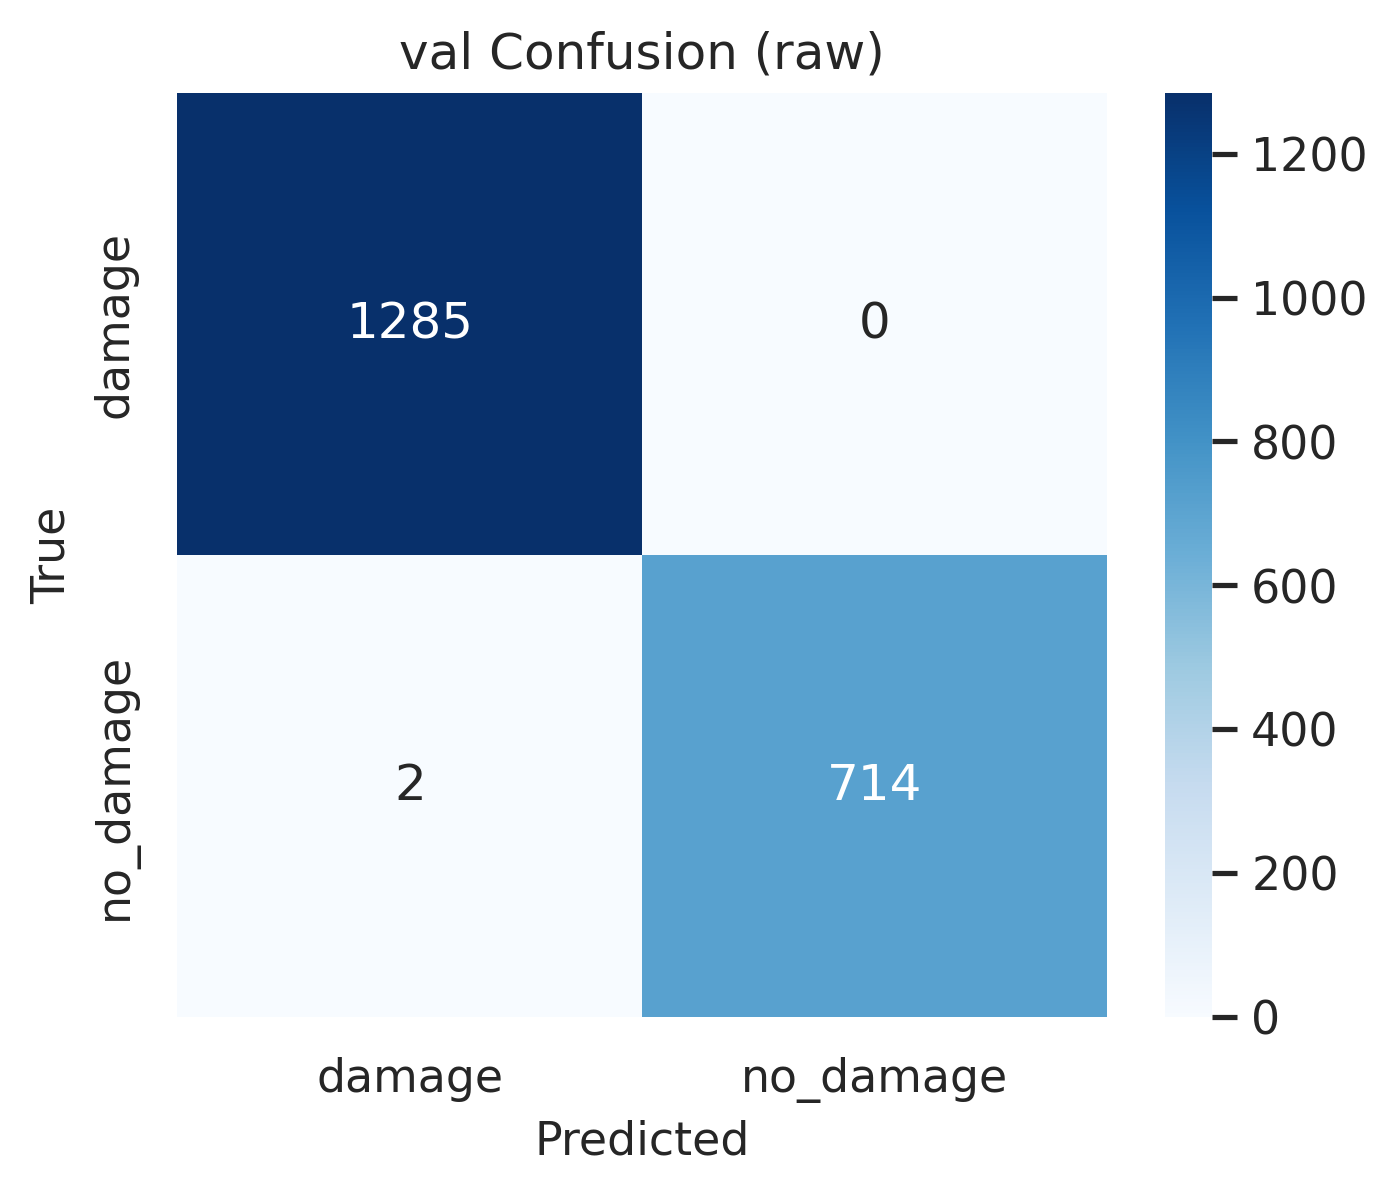

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b1/eval_plots/eval_val_raw_score_hist.pdf


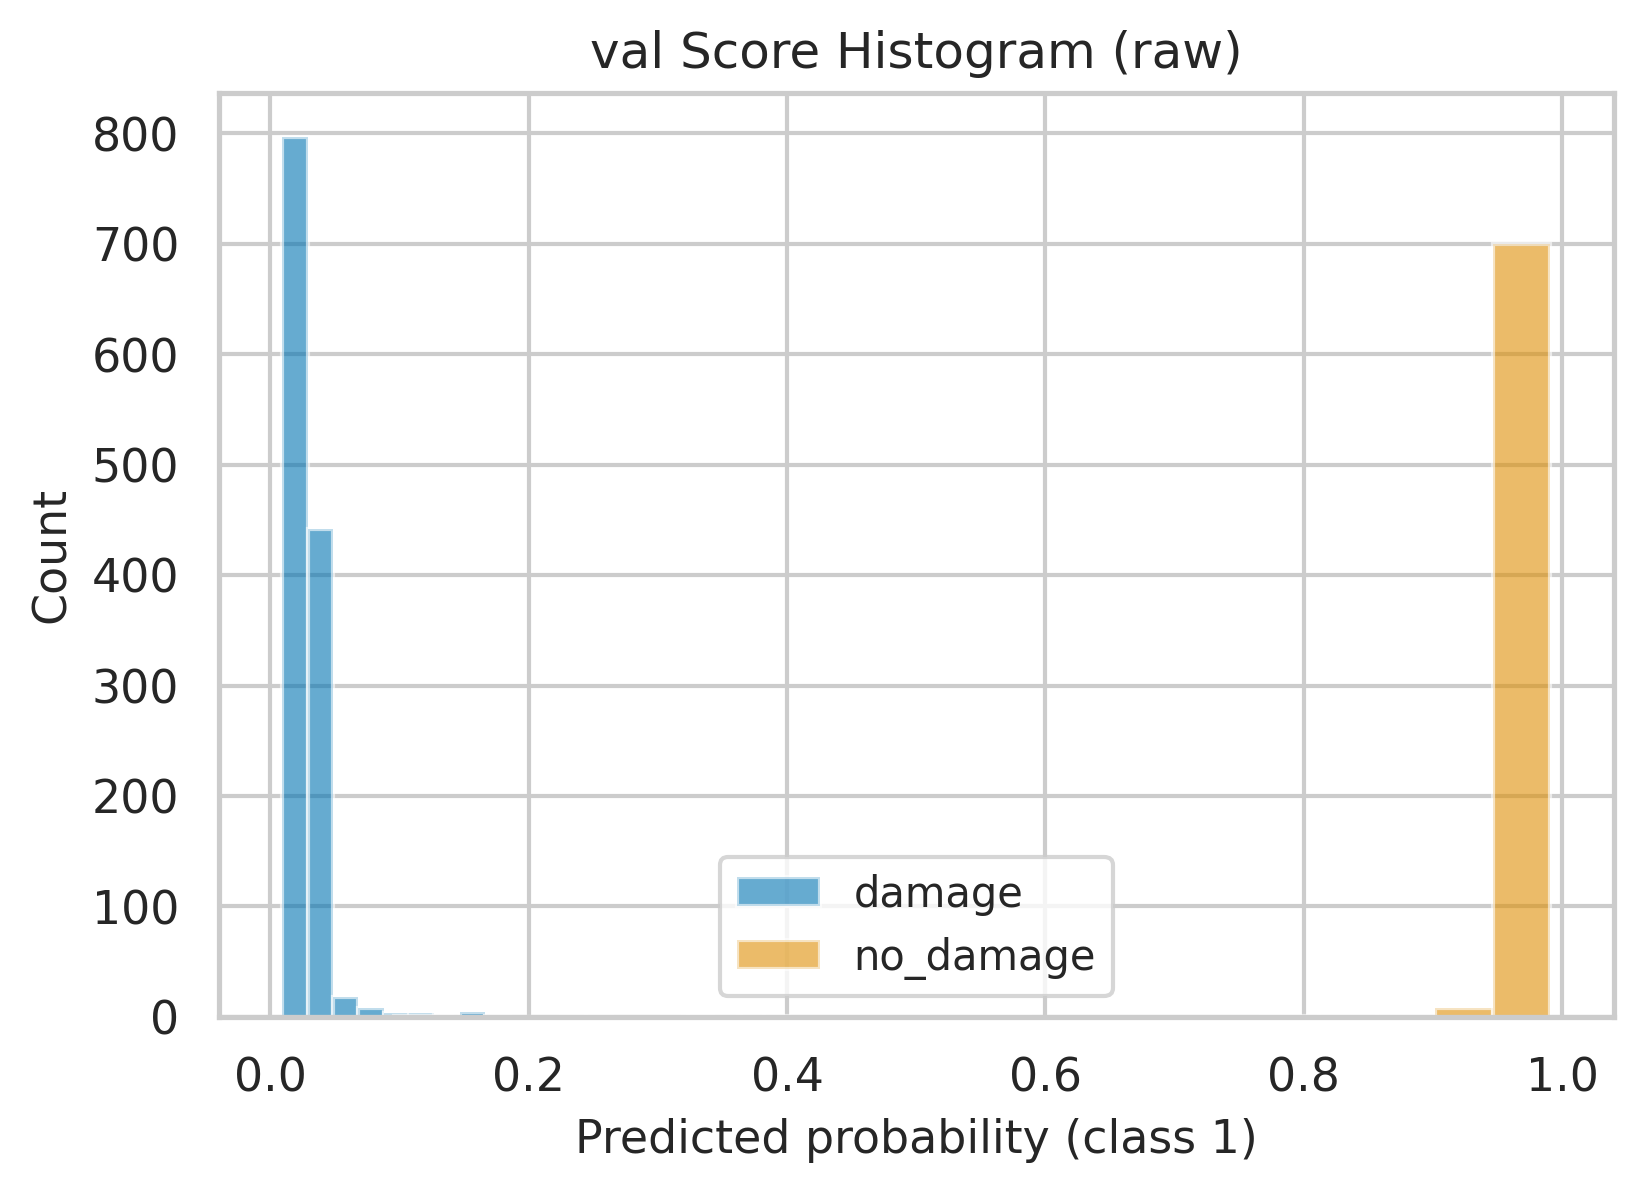

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b1/eval_plots/eval_val_raw_reliability.pdf


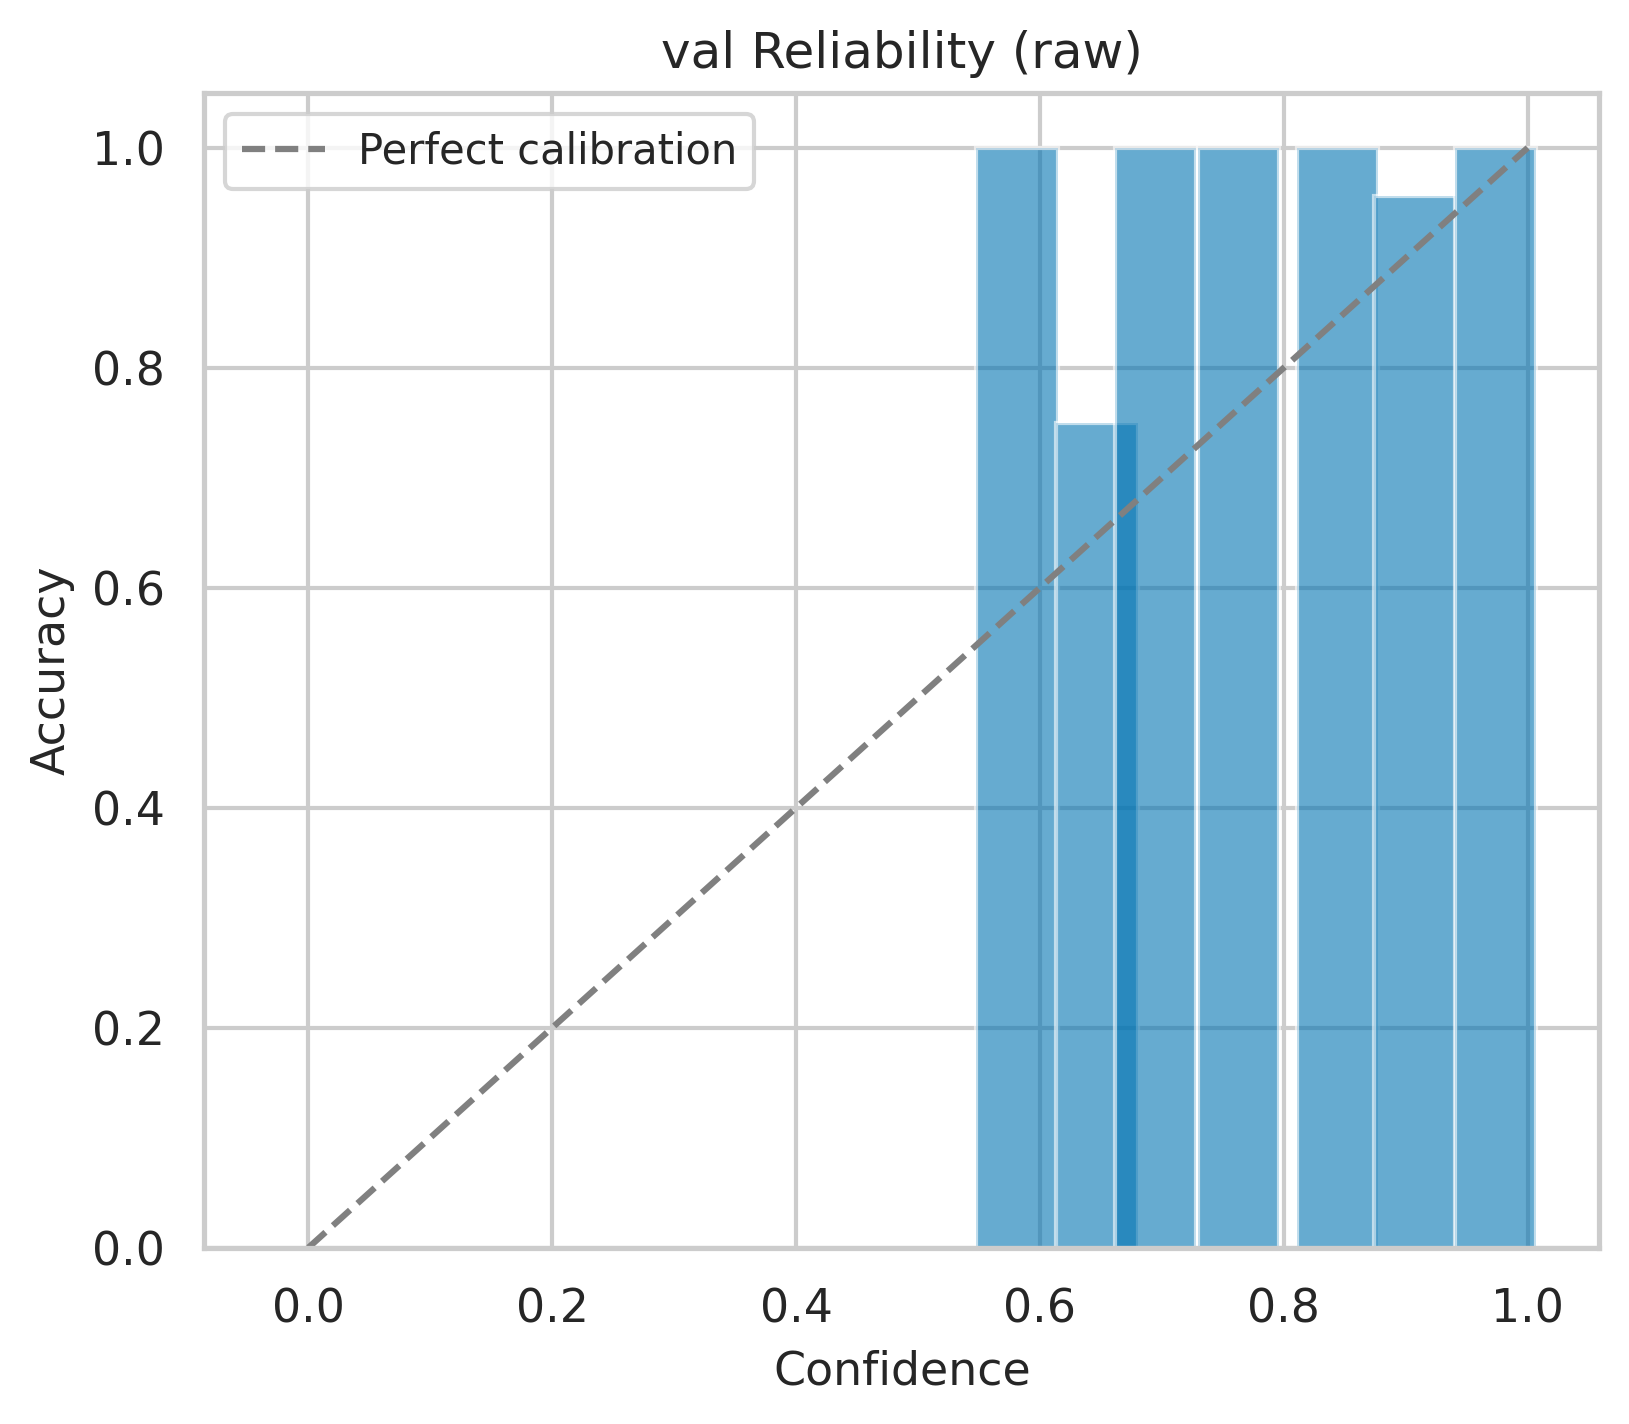

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b1/eval_plots/eval_test_raw_confusion.pdf


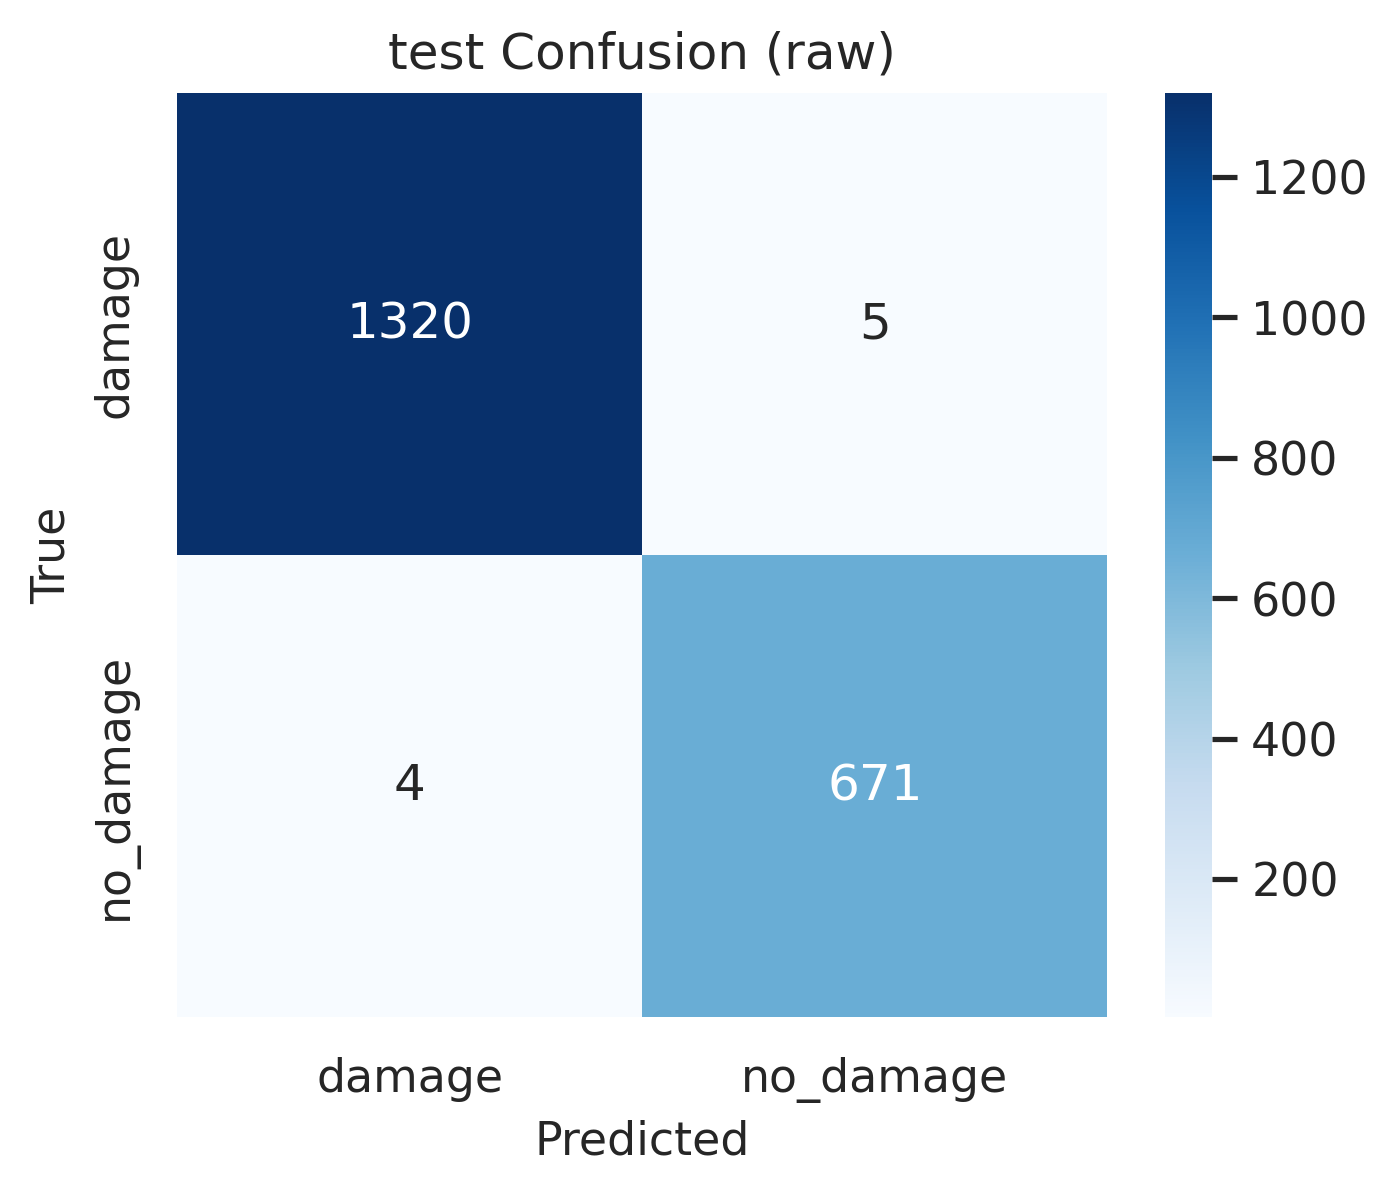

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b1/eval_plots/eval_test_raw_score_hist.pdf


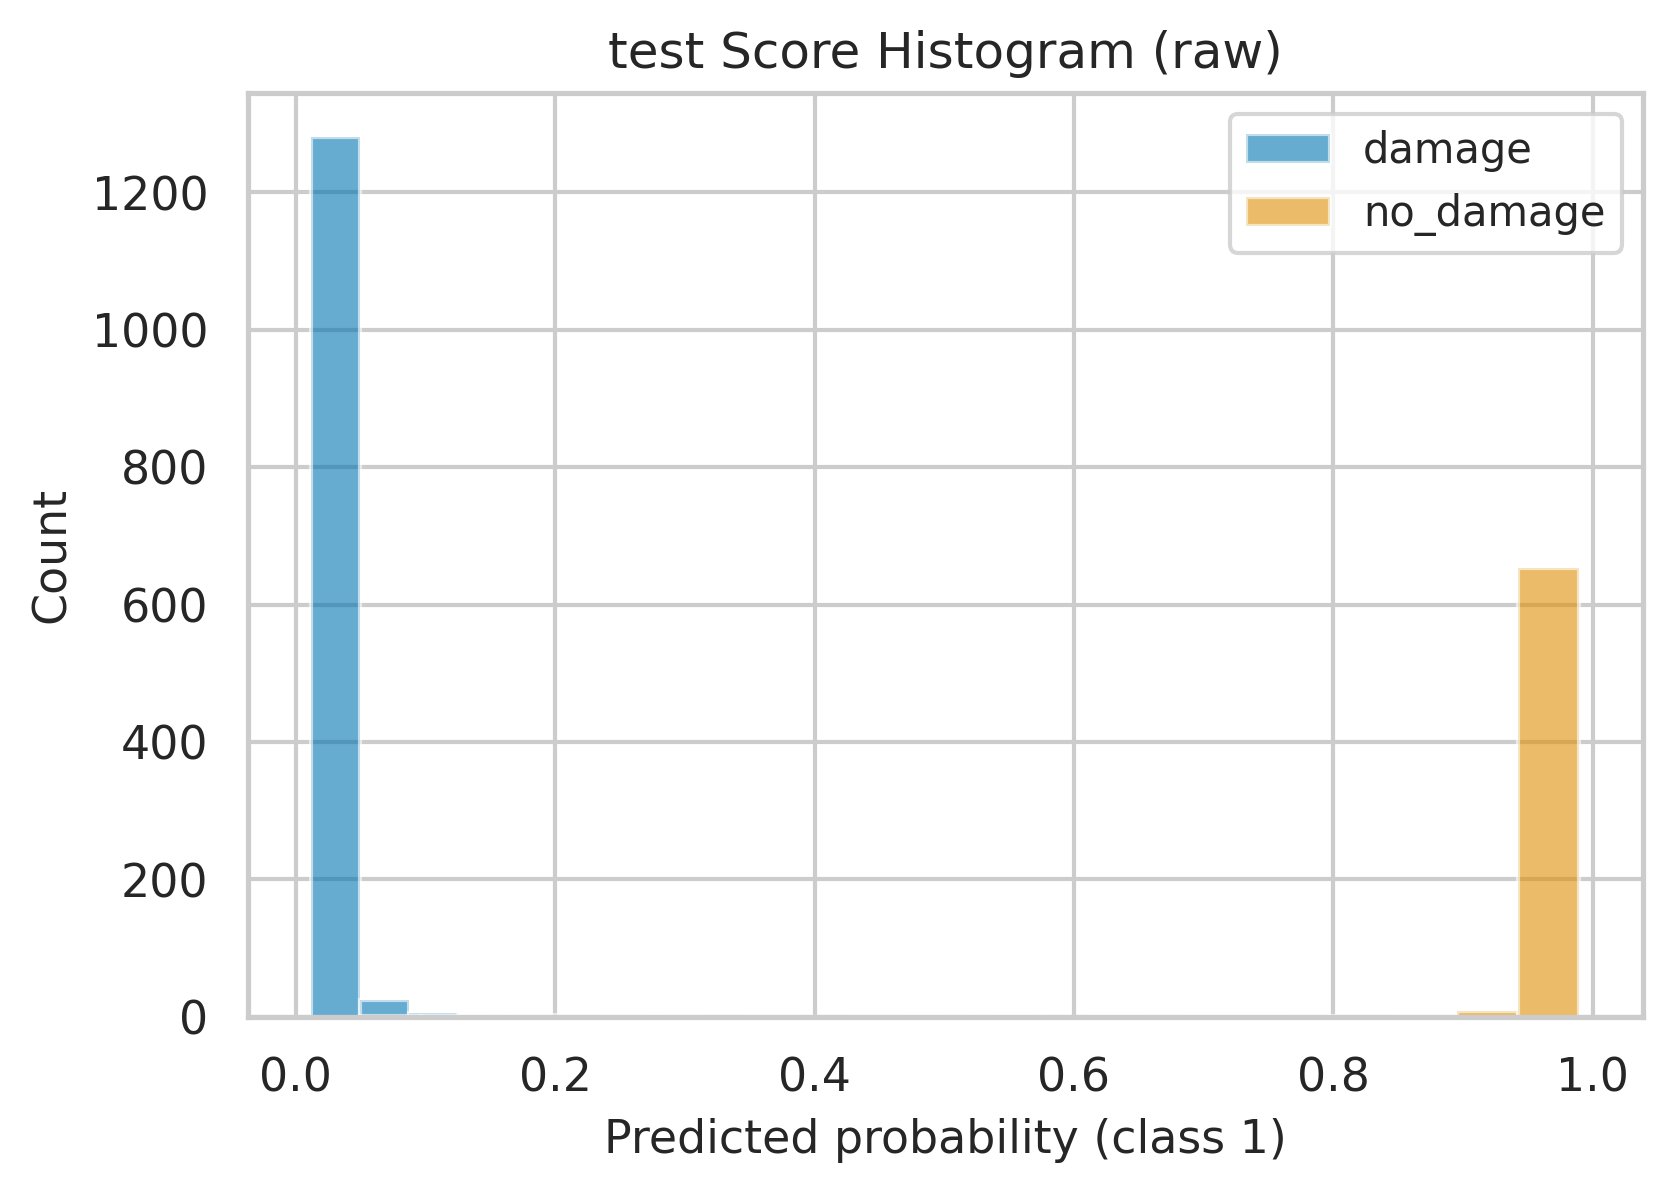

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b1/eval_plots/eval_test_raw_reliability.pdf


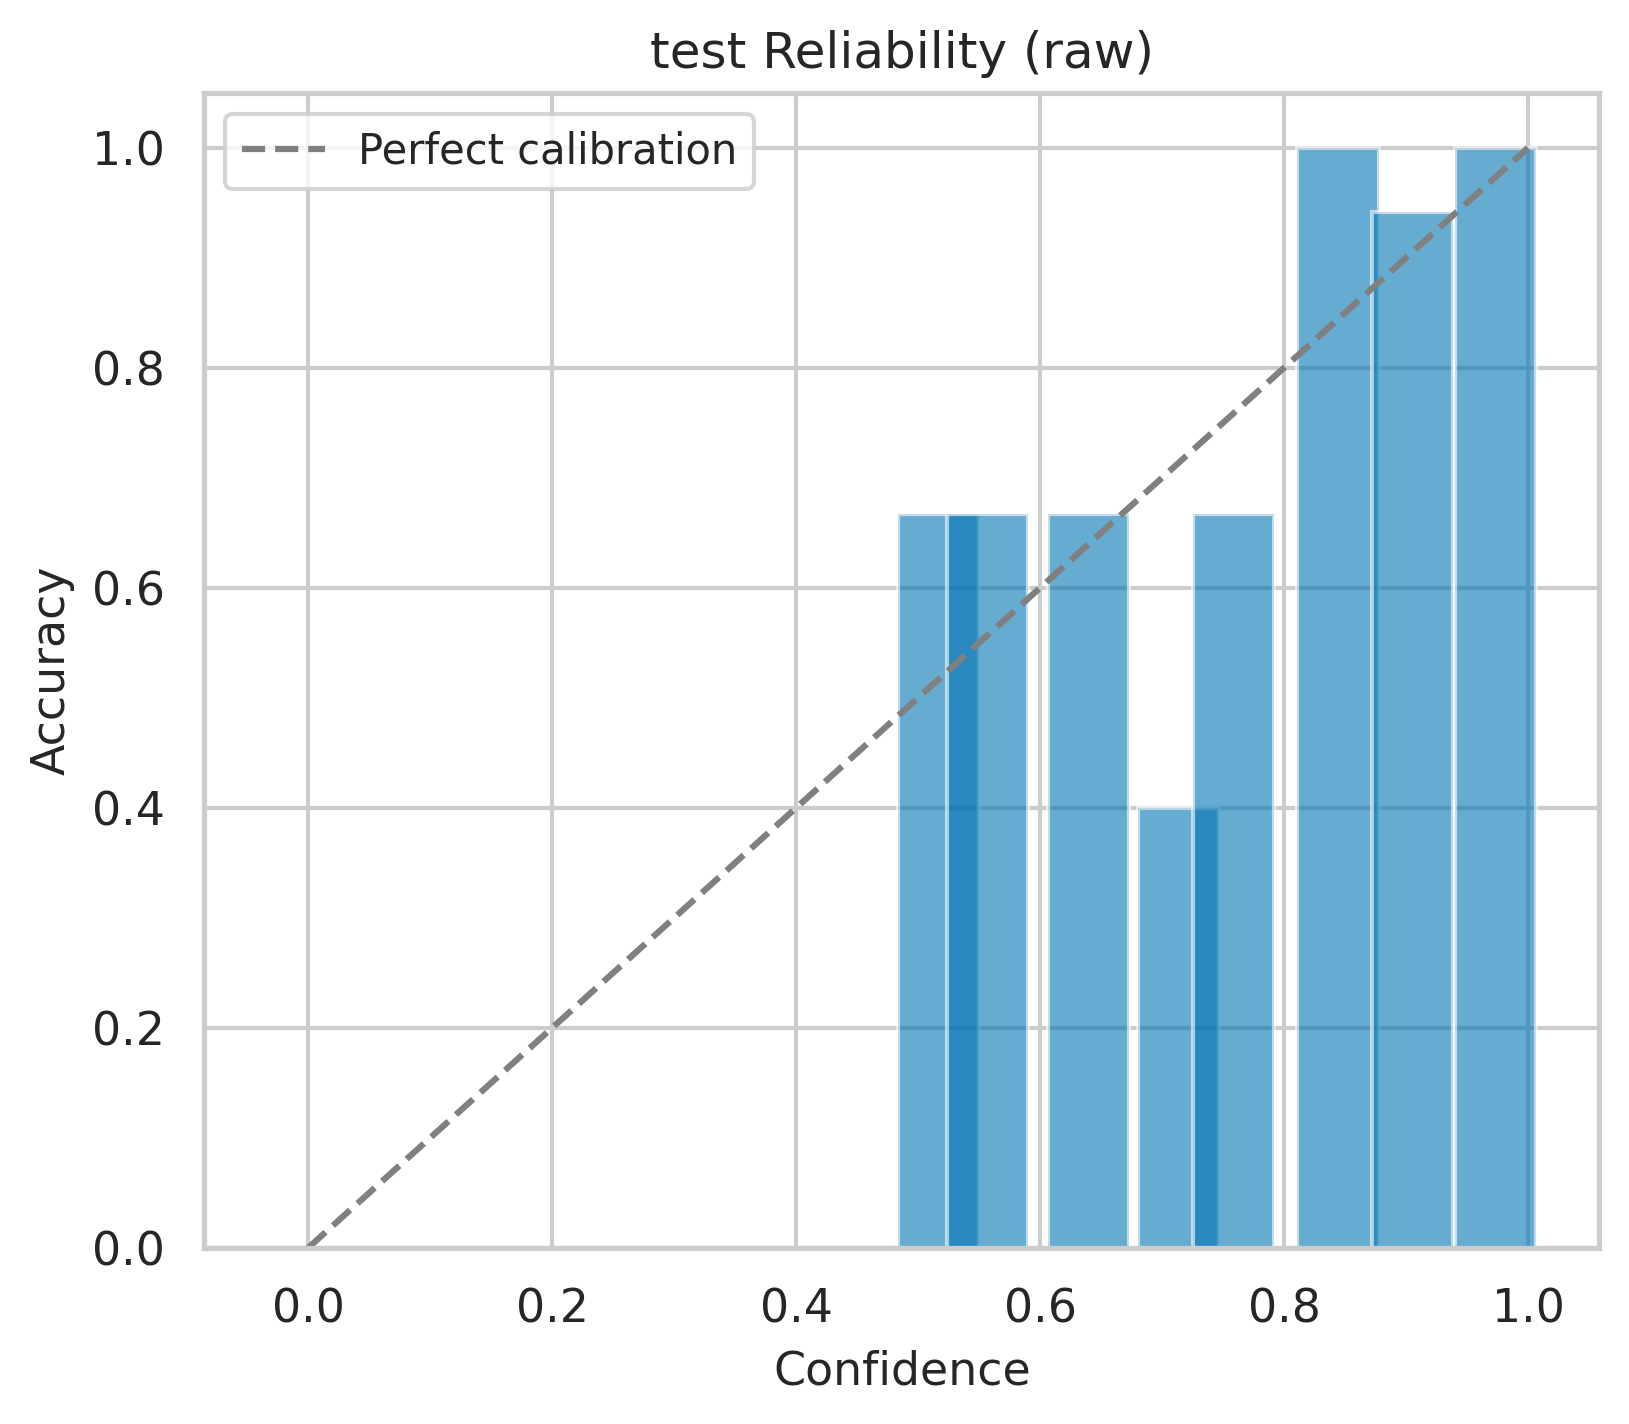

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b1/eval_plots/eval_val_calibrated_confusion.pdf


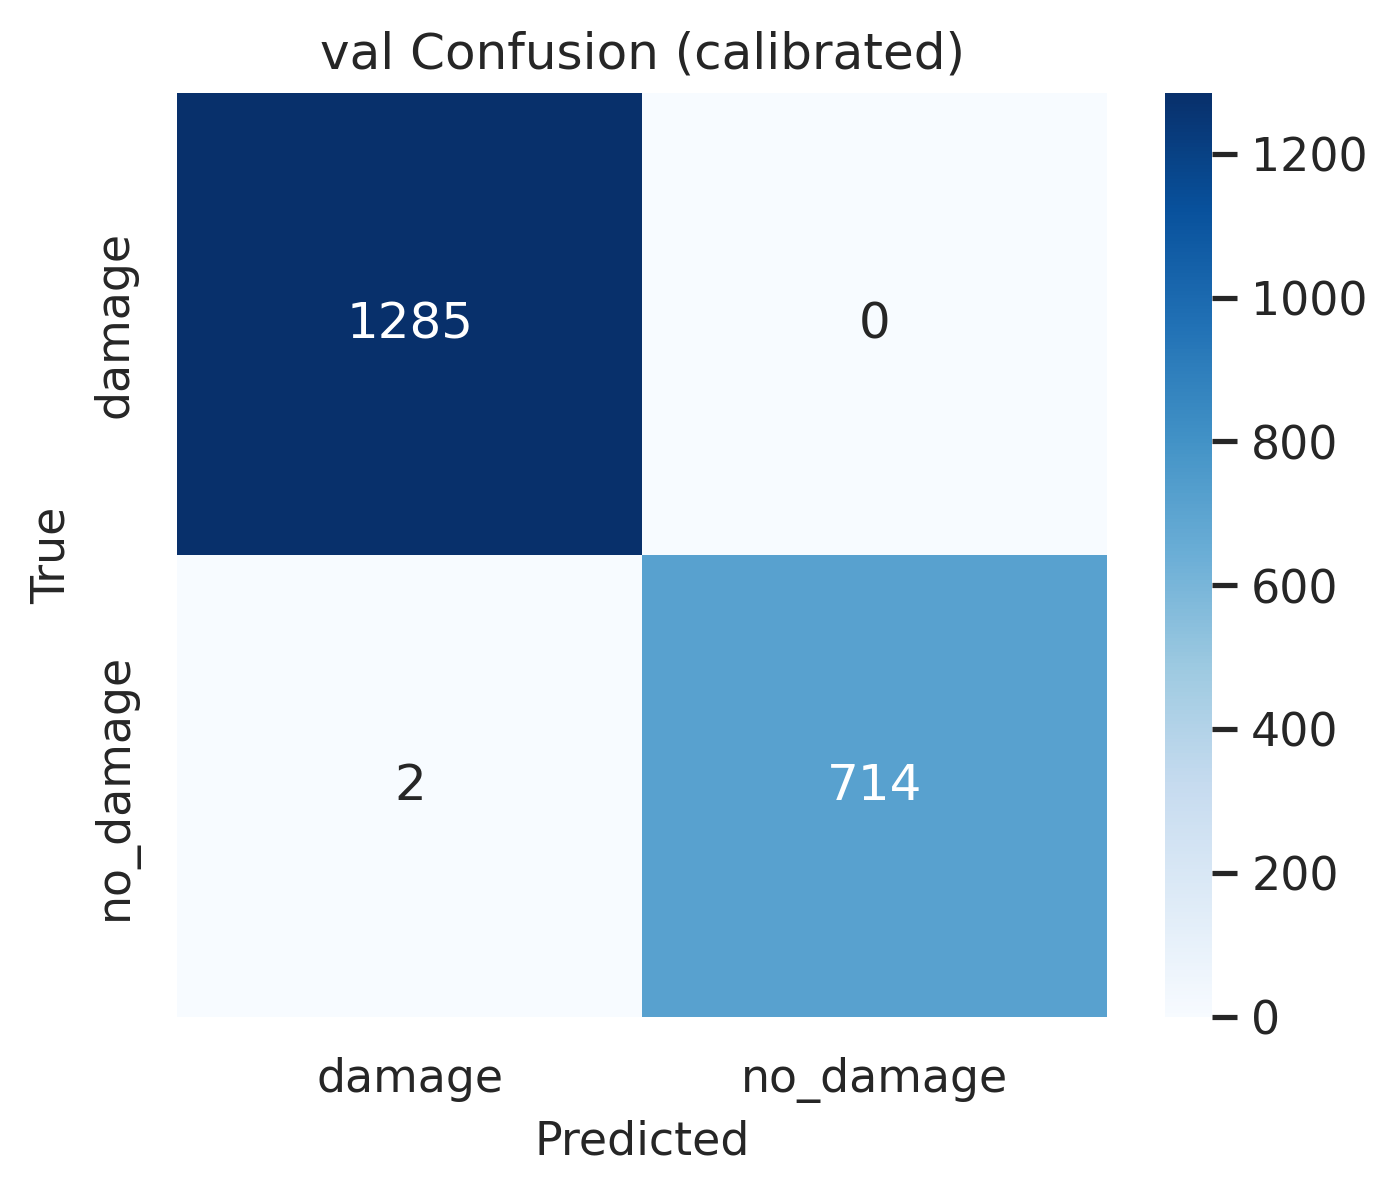

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b1/eval_plots/eval_val_calibrated_score_hist.pdf


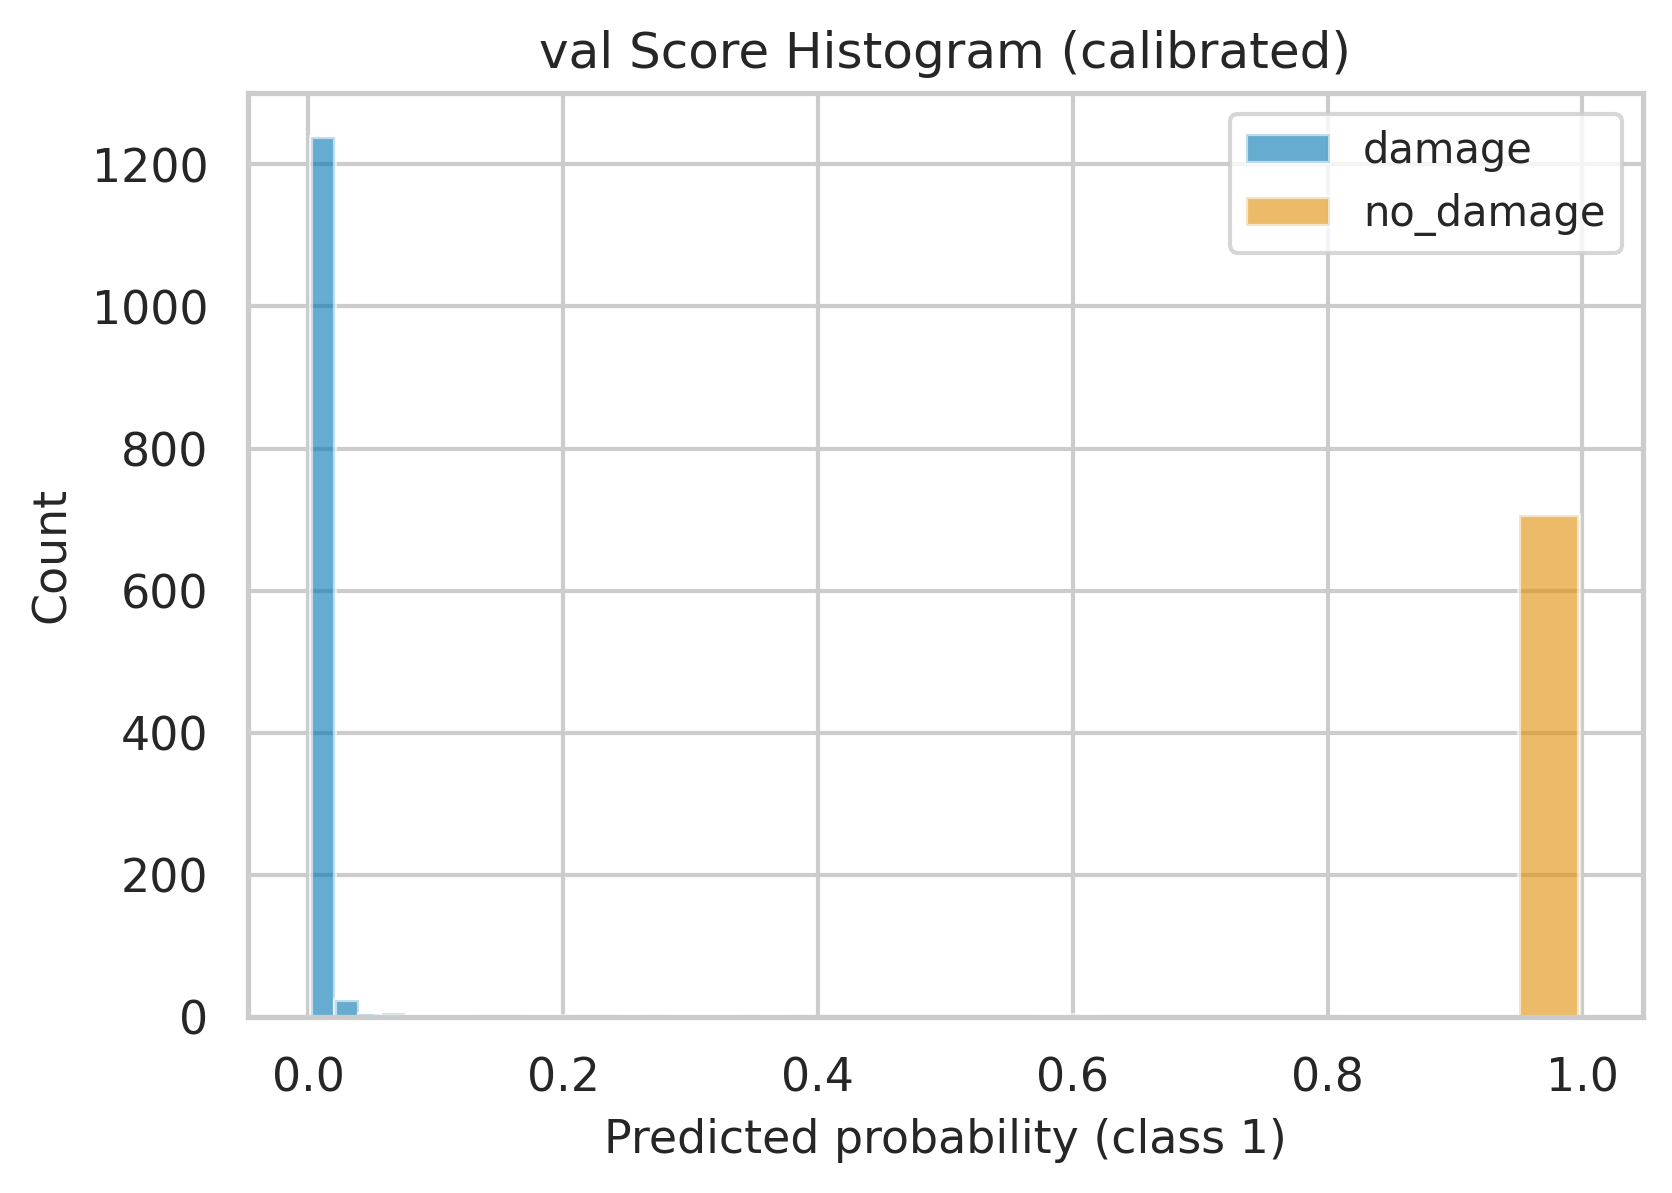

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b1/eval_plots/eval_val_calibrated_reliability.pdf


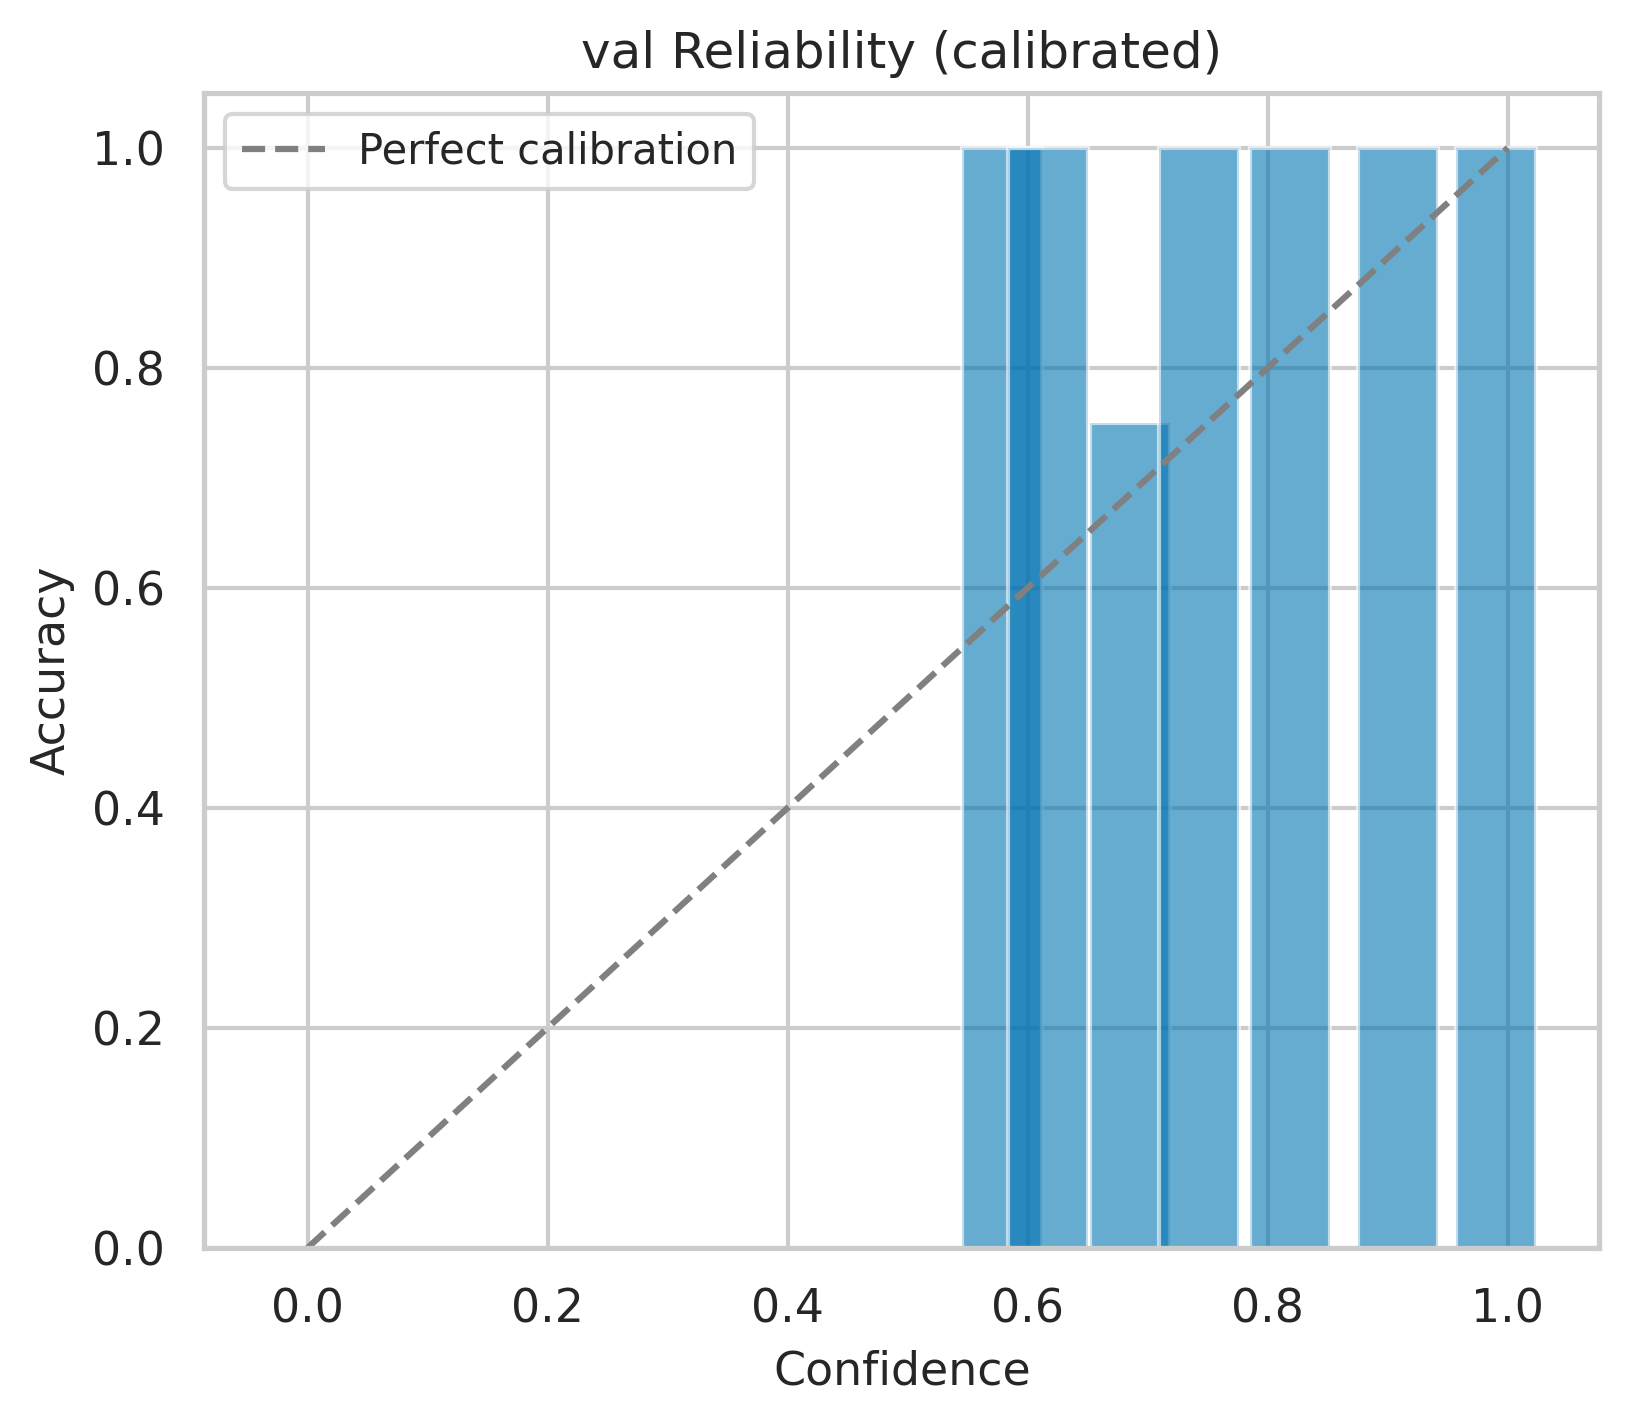

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b1/eval_plots/eval_test_calibrated_confusion.pdf


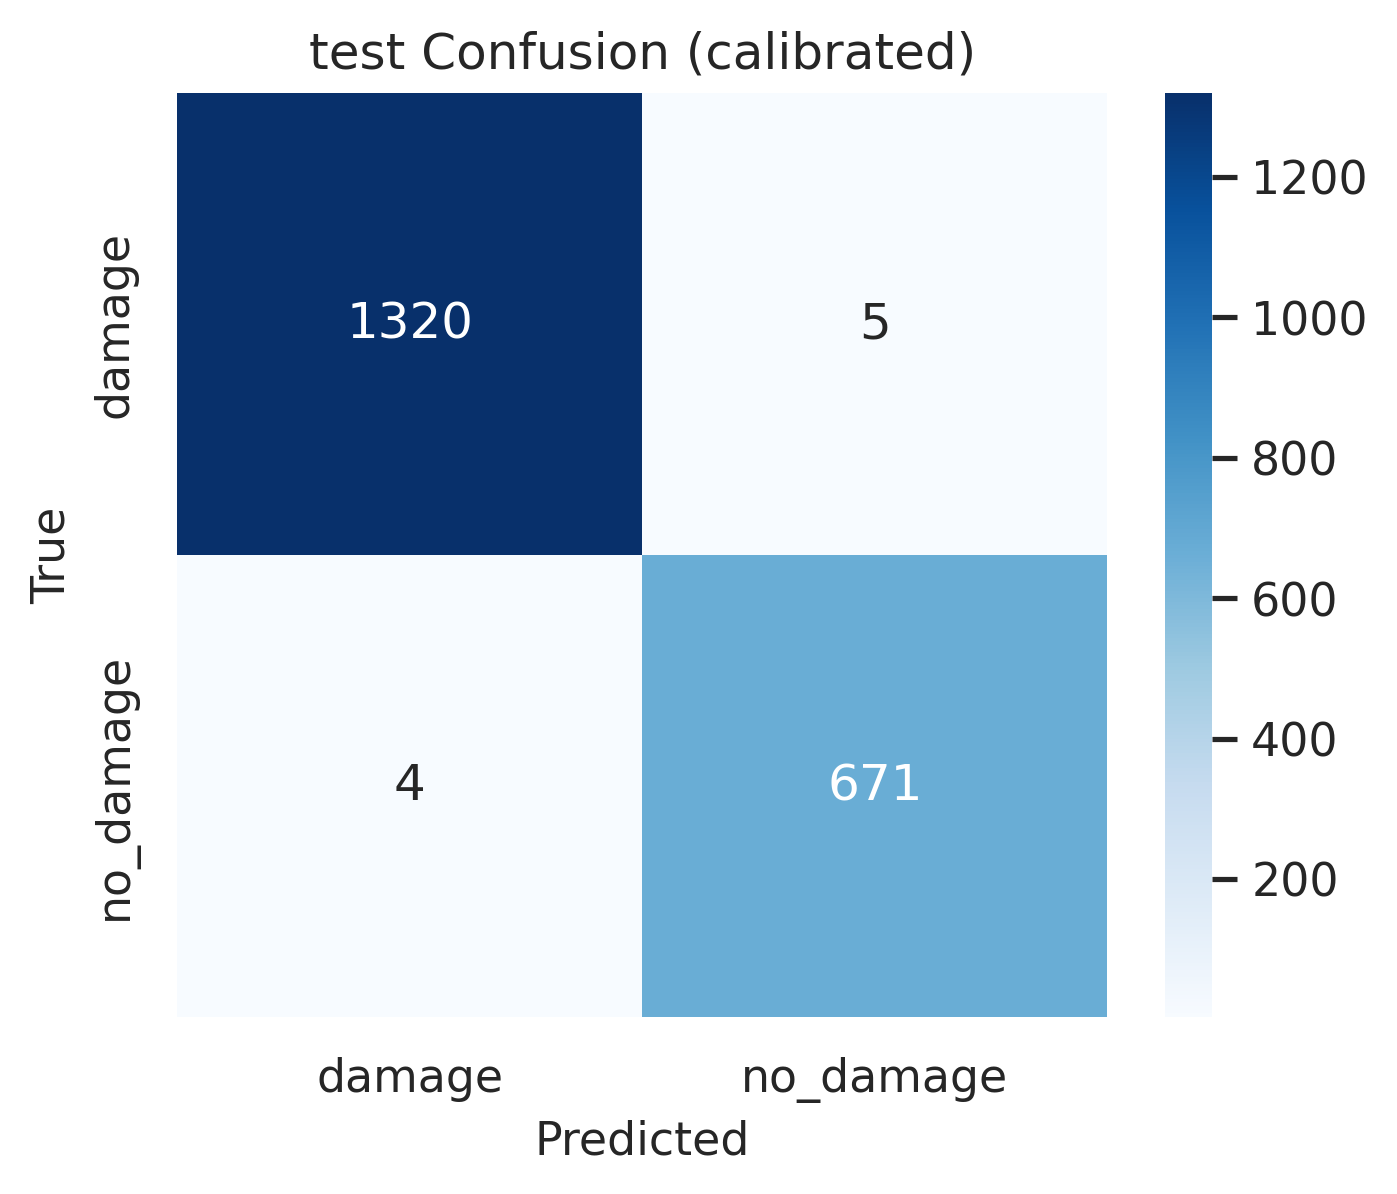

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b1/eval_plots/eval_test_calibrated_score_hist.pdf


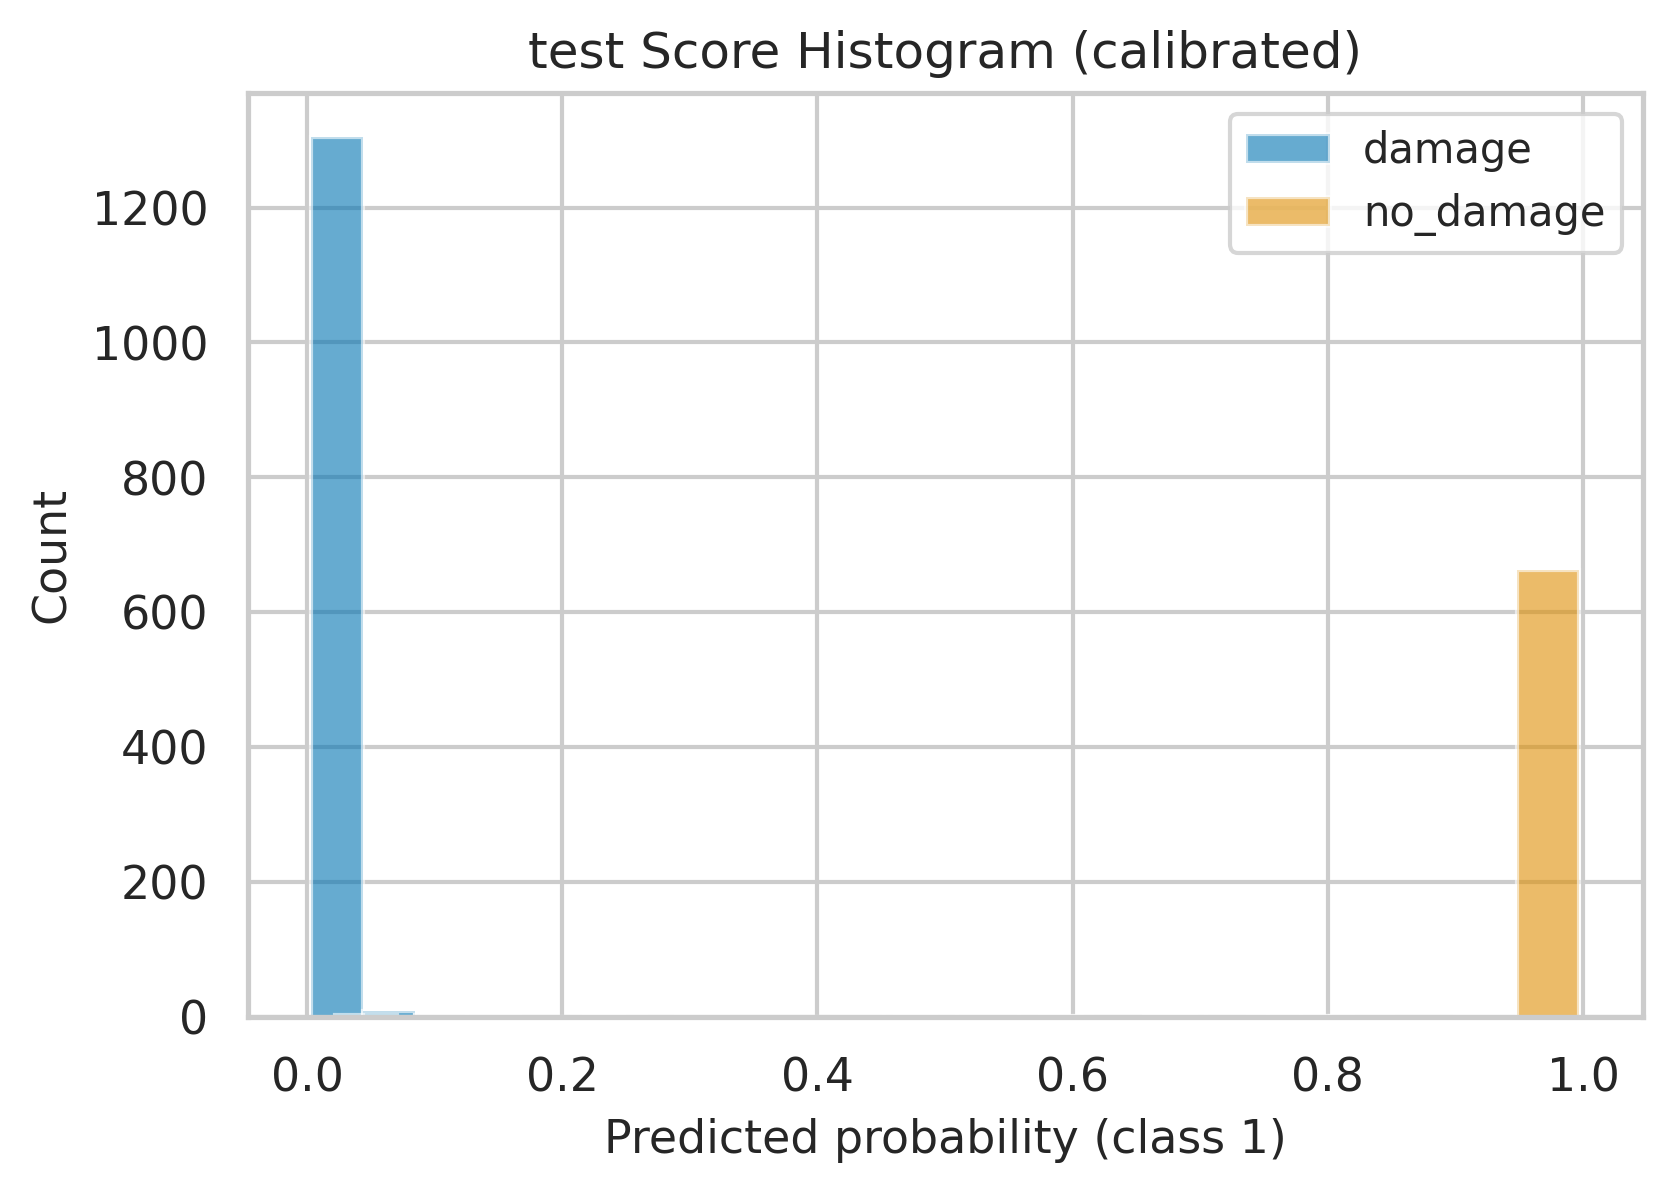

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b1/eval_plots/eval_test_calibrated_reliability.pdf


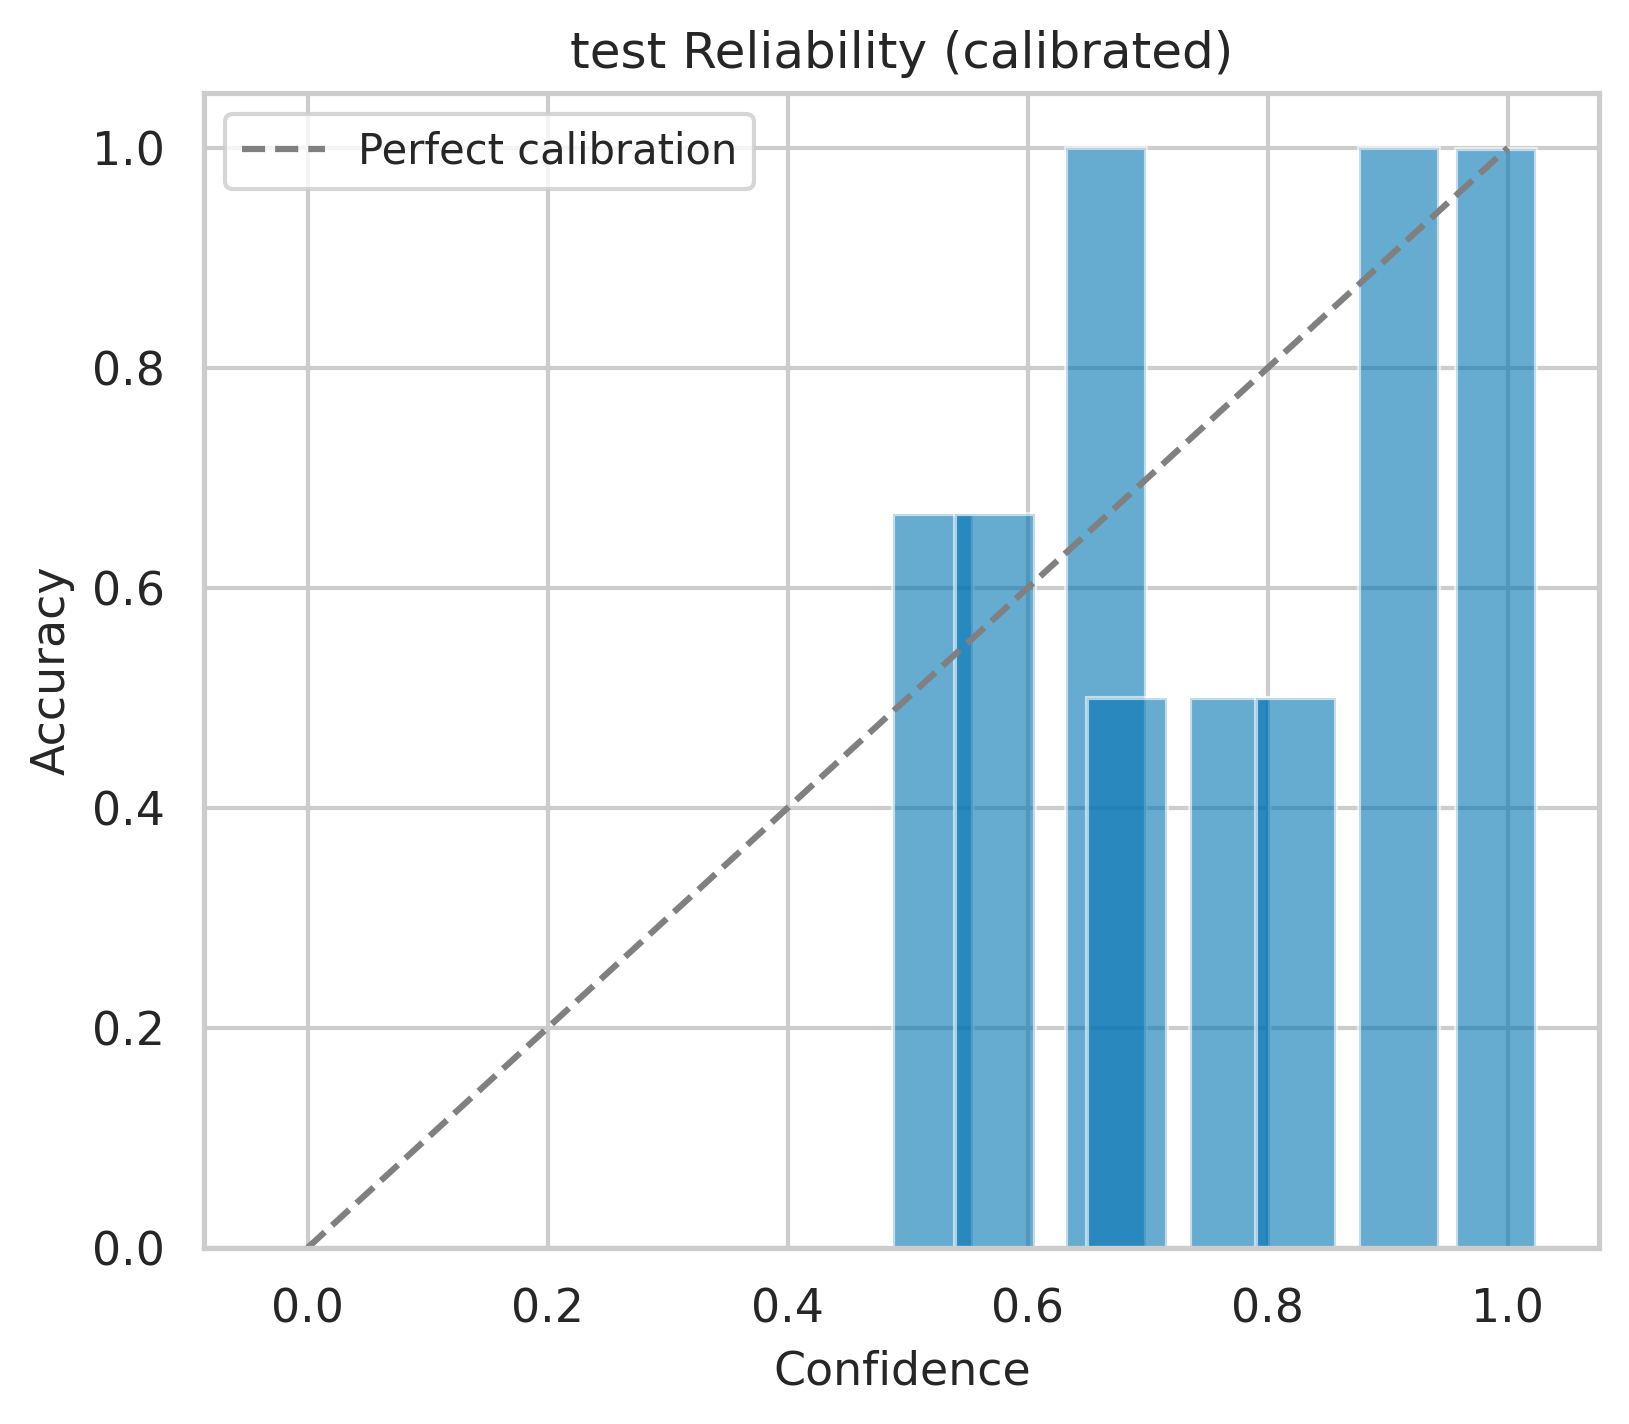

Saved eval metrics to ../training_runs/resampled_20251206-154401_efficientnet_b1/eval_metrics.json
Fitted temperature: 0.7761
Test metrics (raw): {'accuracy': 0.9955, 'macro_precision': 0.9947912011298021, 'macro_recall': 0.9951502445842069, 'macro_f1': 0.9949703797279479, 'brier': 0.004008849220399063, 'ece': 0.02799324256181722}
Test metrics (calibrated): {'accuracy': 0.9955, 'macro_precision': 0.9947912011298021, 'macro_recall': 0.9951502445842069, 'macro_f1': 0.9949703797279479, 'brier': 0.0034401503363977845, 'ece': 0.011224190622568115}


In [8]:
efficientnet_b1_eval = evaluate_run("efficientnet_b1")

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b2/eval_plots/eval_val_raw_confusion.pdf


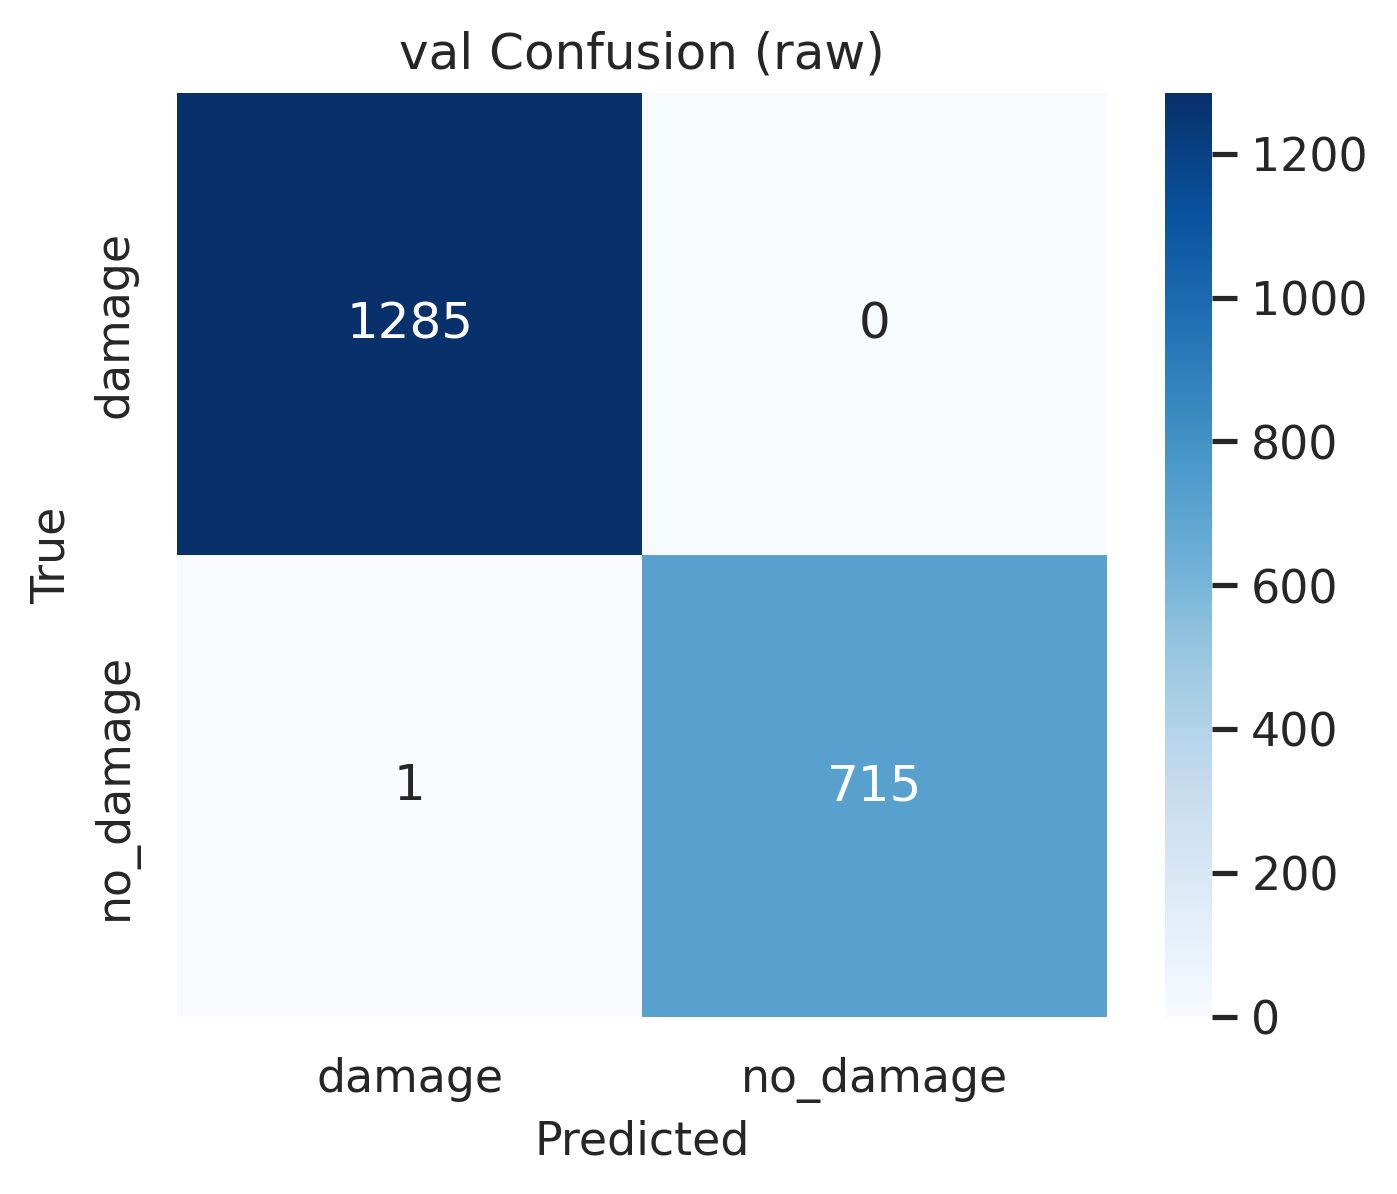

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b2/eval_plots/eval_val_raw_score_hist.pdf


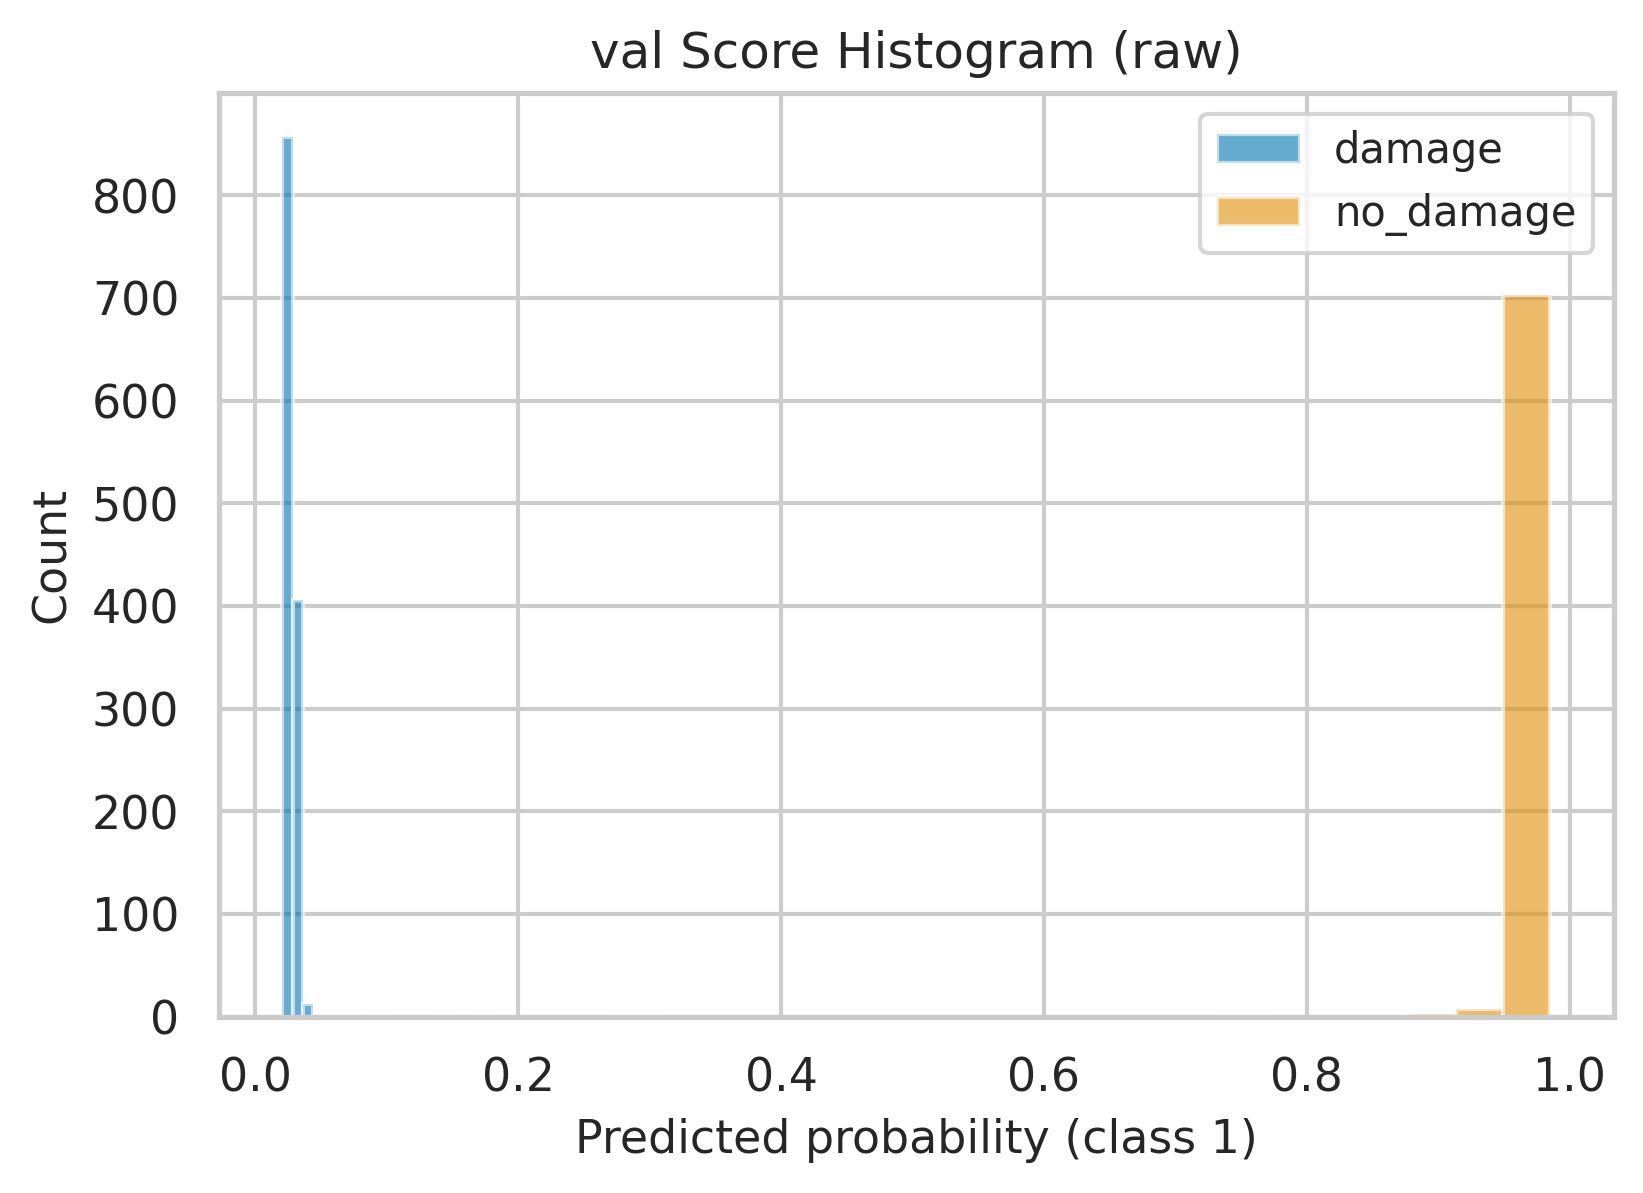

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b2/eval_plots/eval_val_raw_reliability.pdf


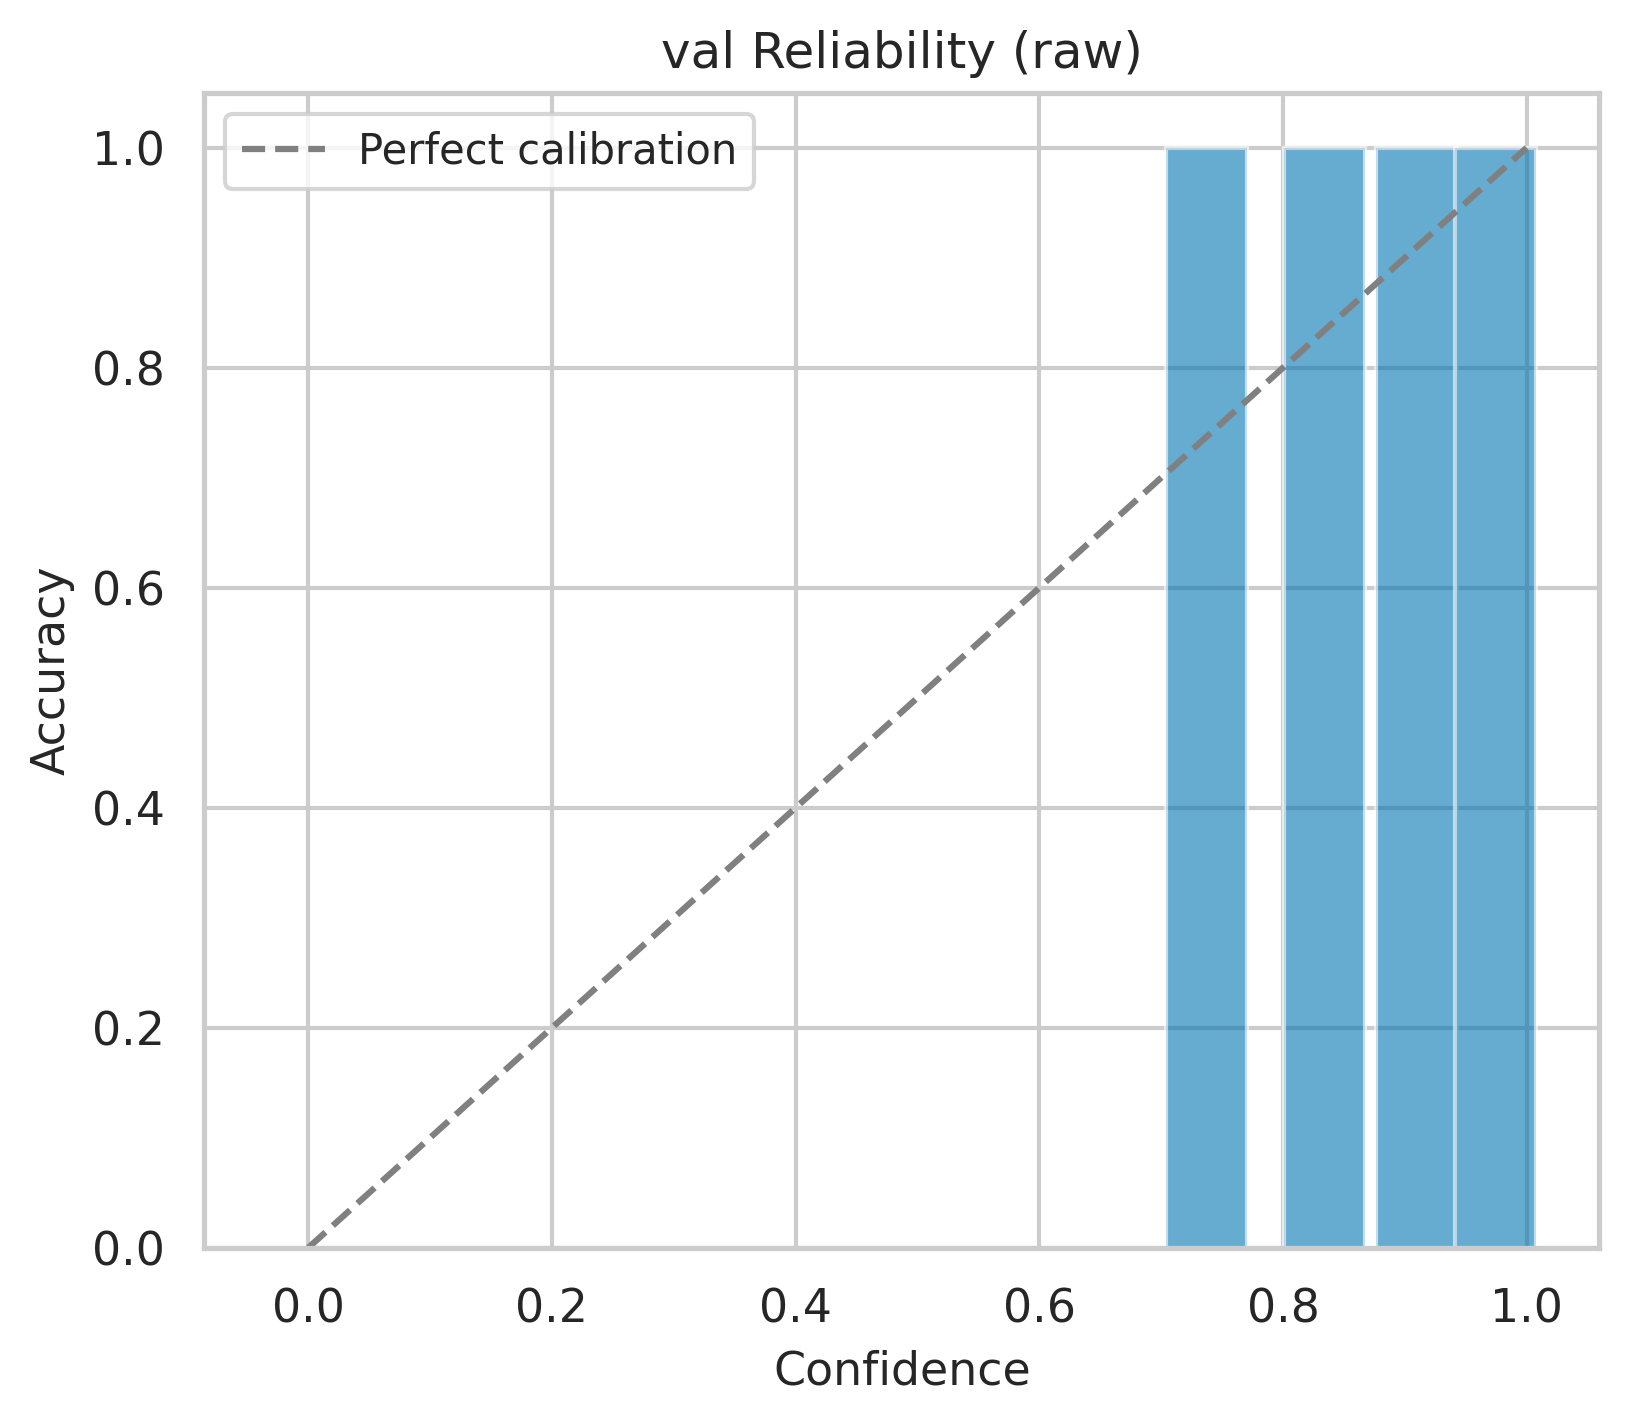

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b2/eval_plots/eval_test_raw_confusion.pdf


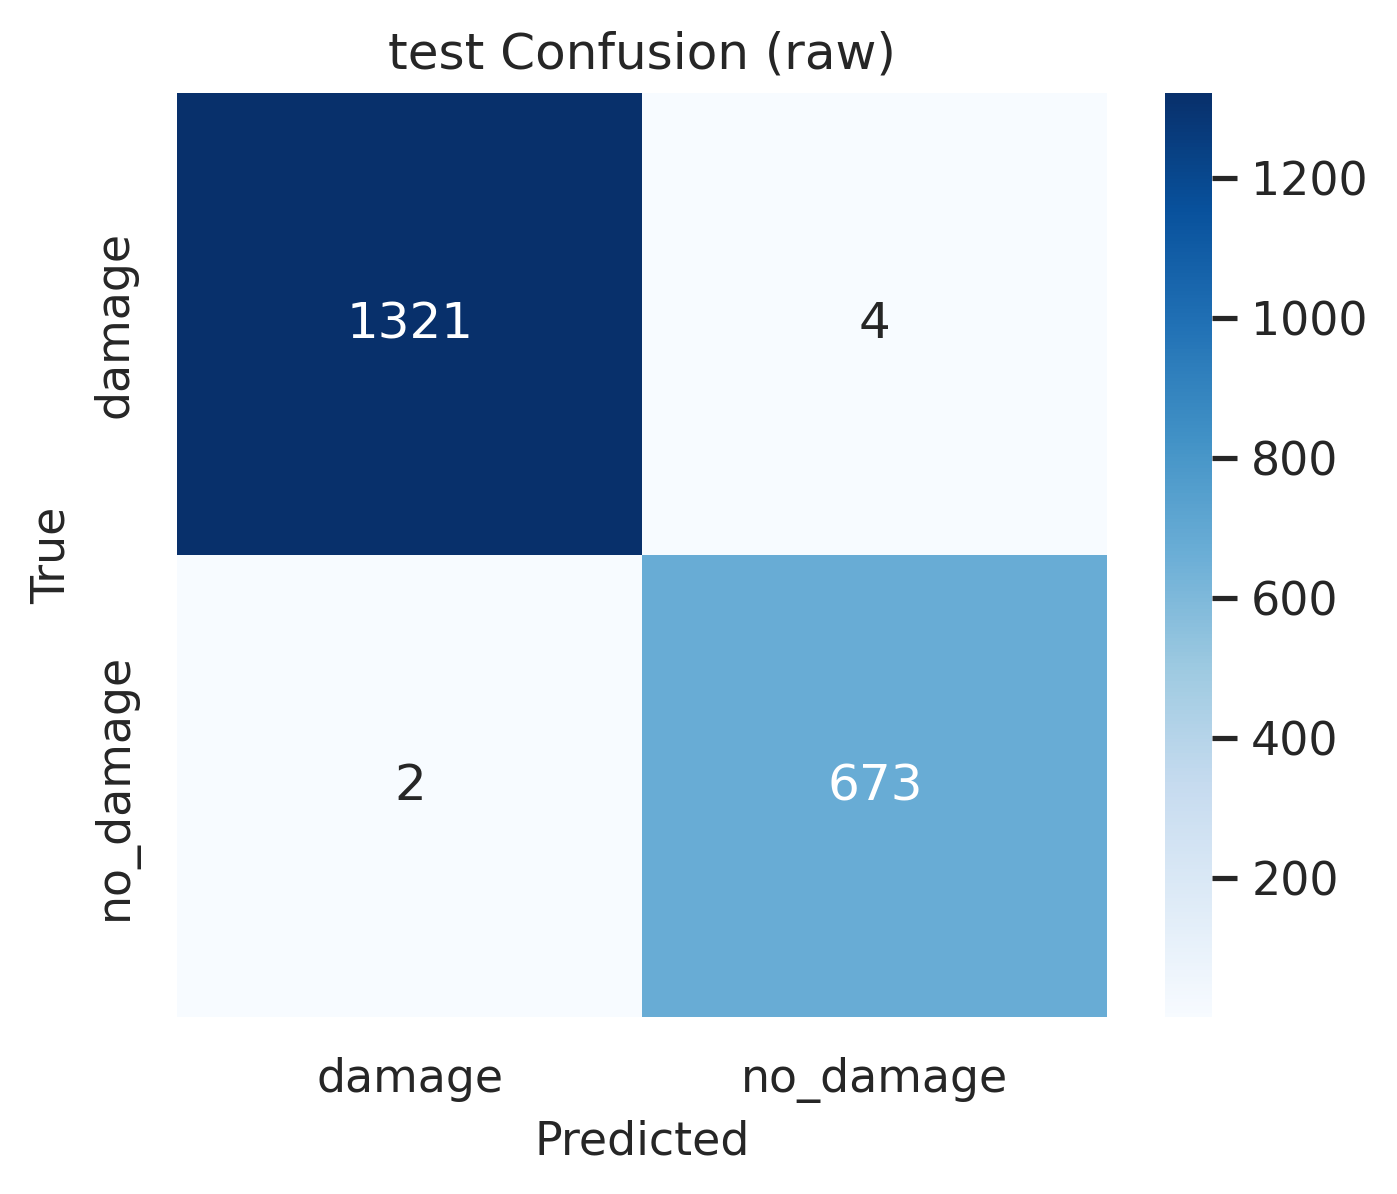

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b2/eval_plots/eval_test_raw_score_hist.pdf


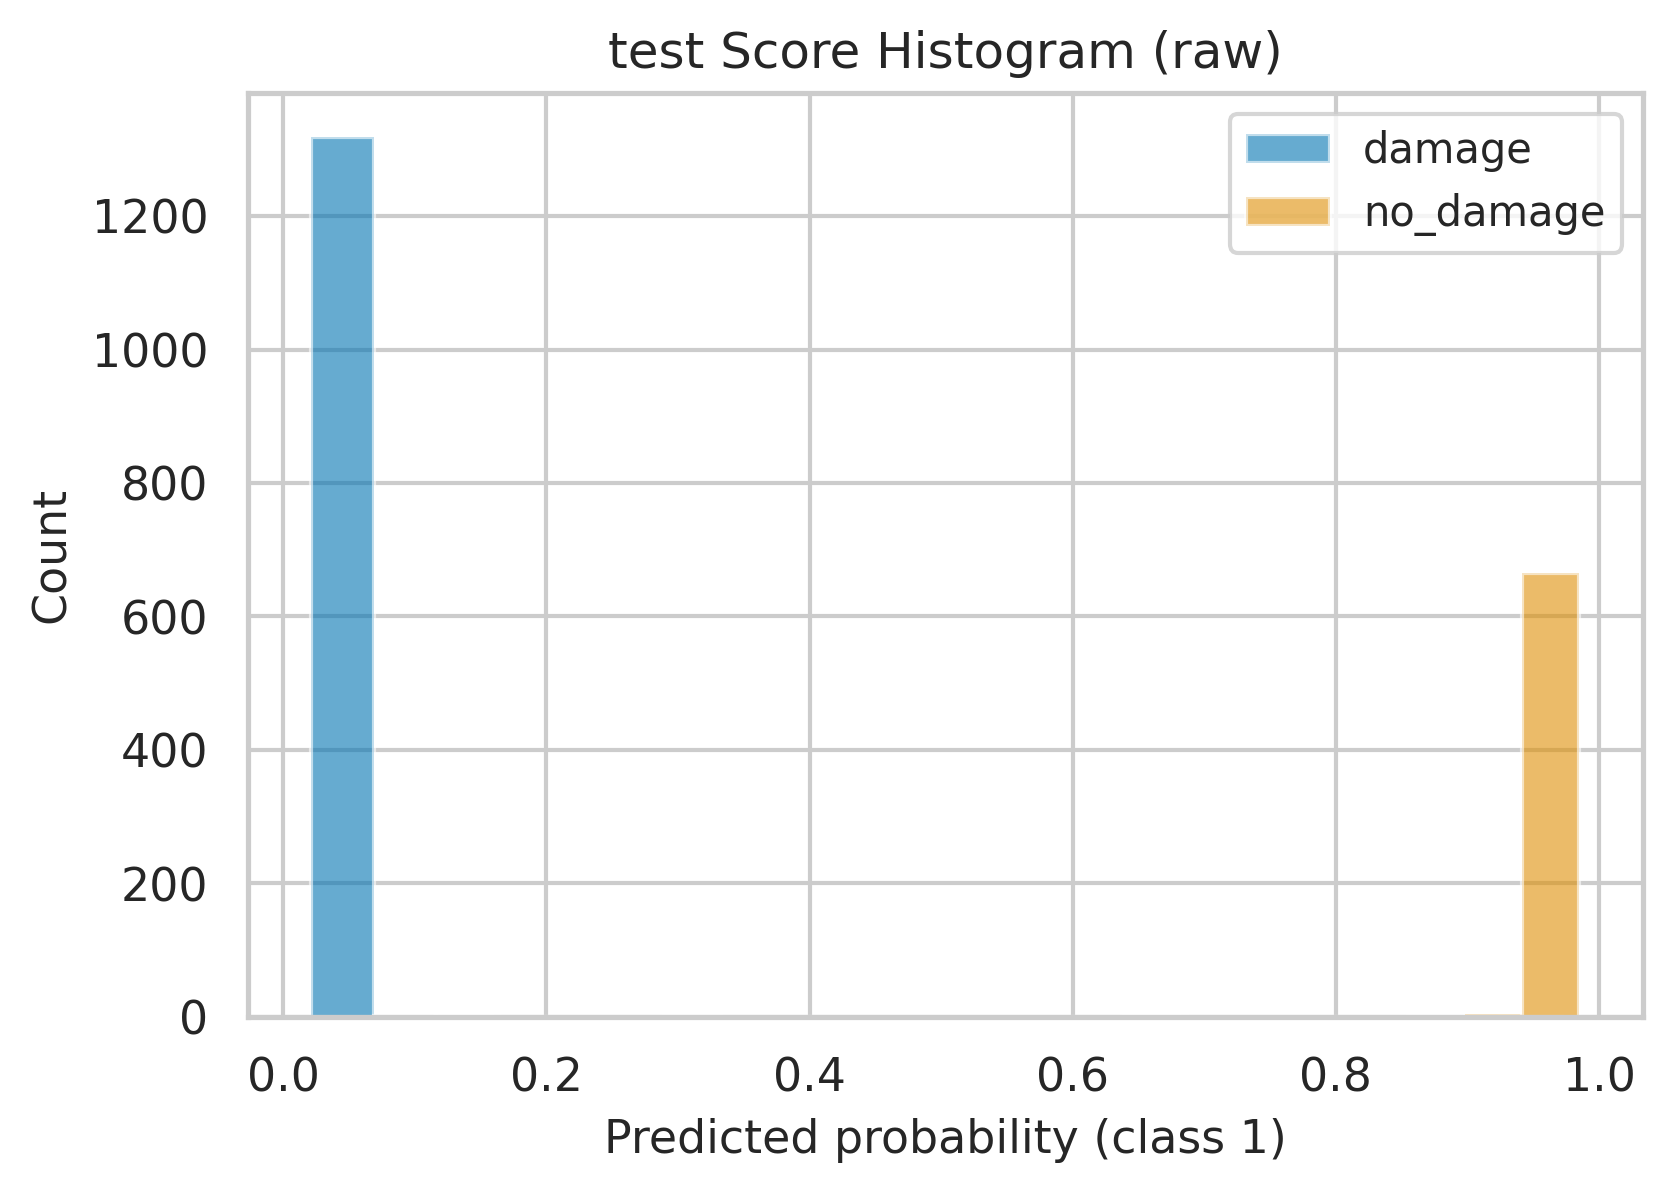

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b2/eval_plots/eval_test_raw_reliability.pdf


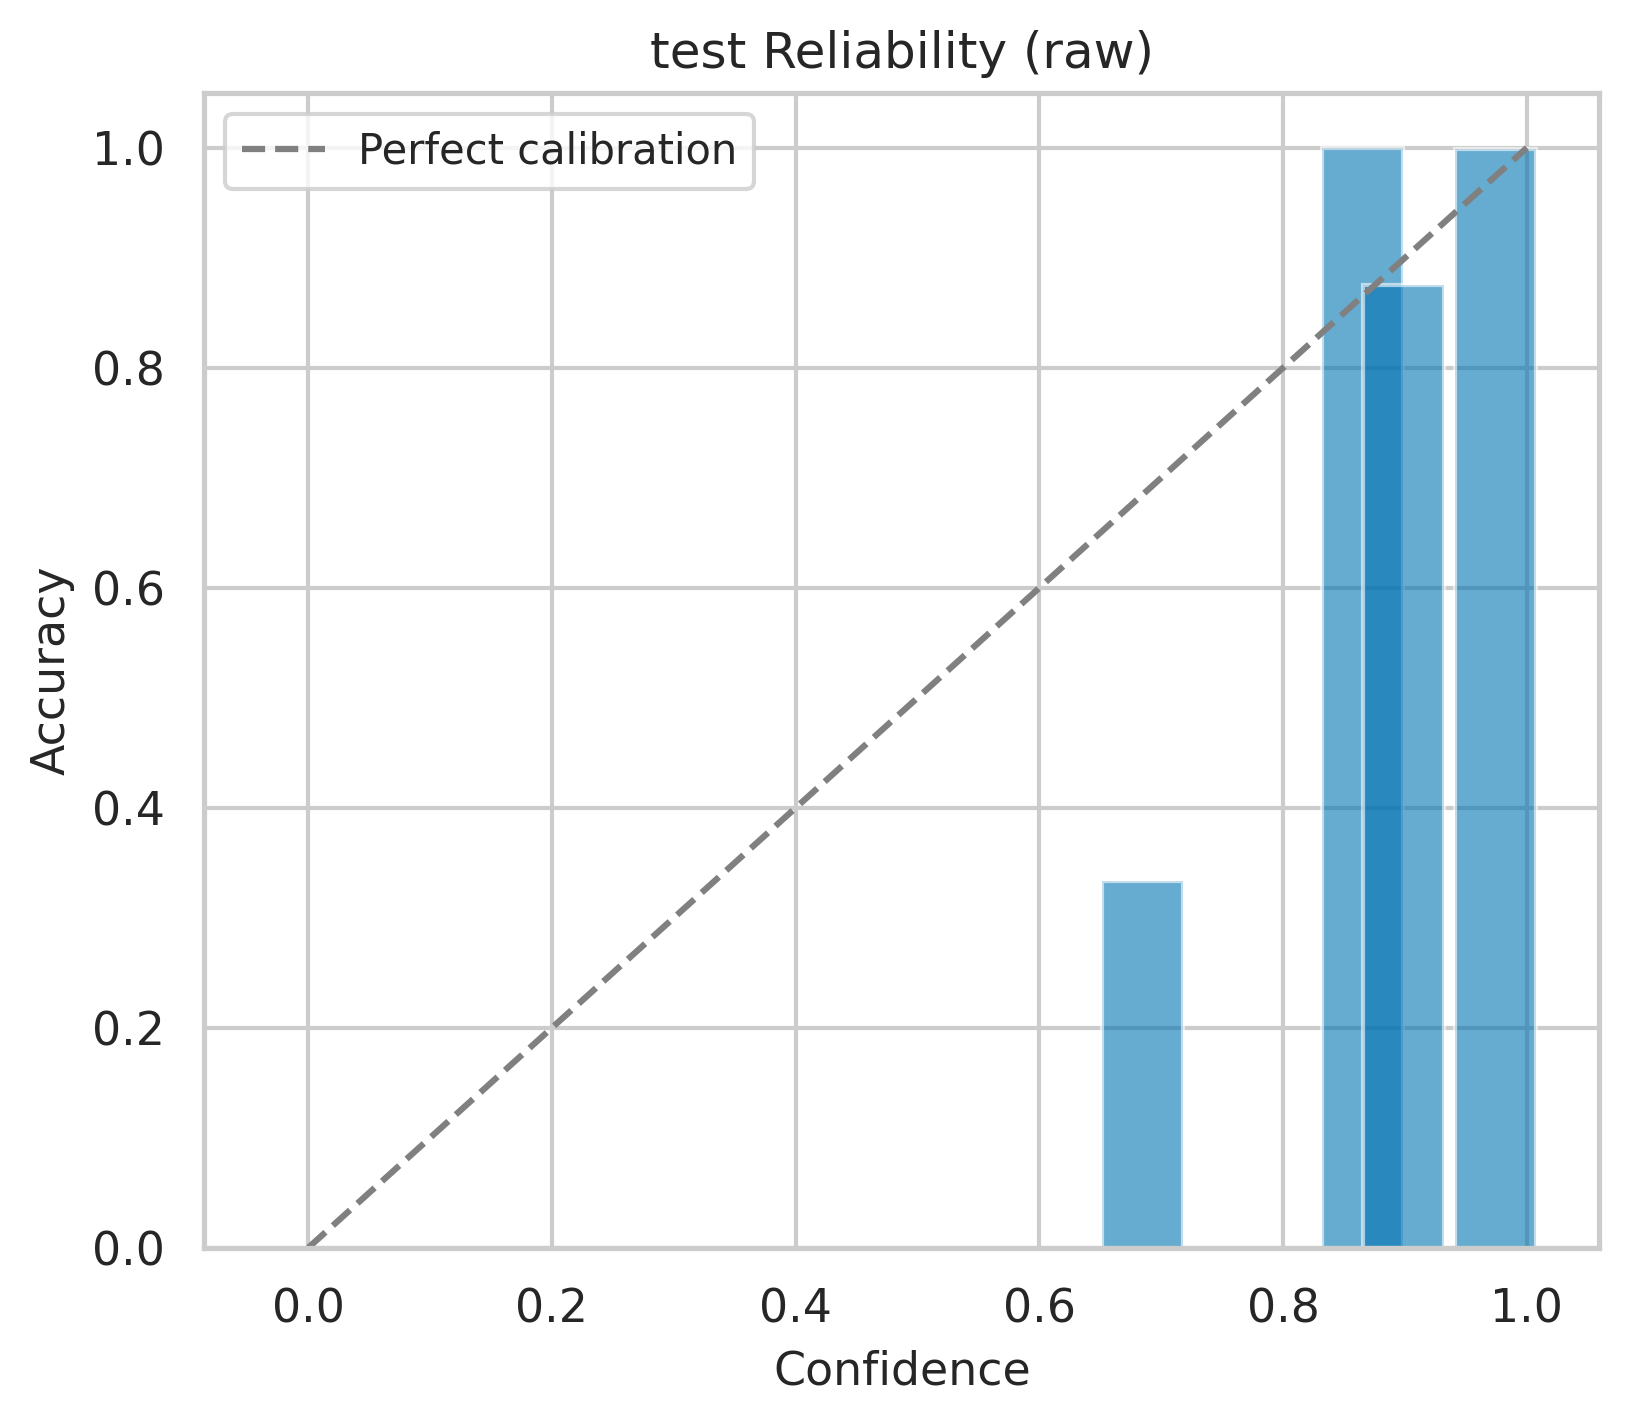

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b2/eval_plots/eval_val_calibrated_confusion.pdf


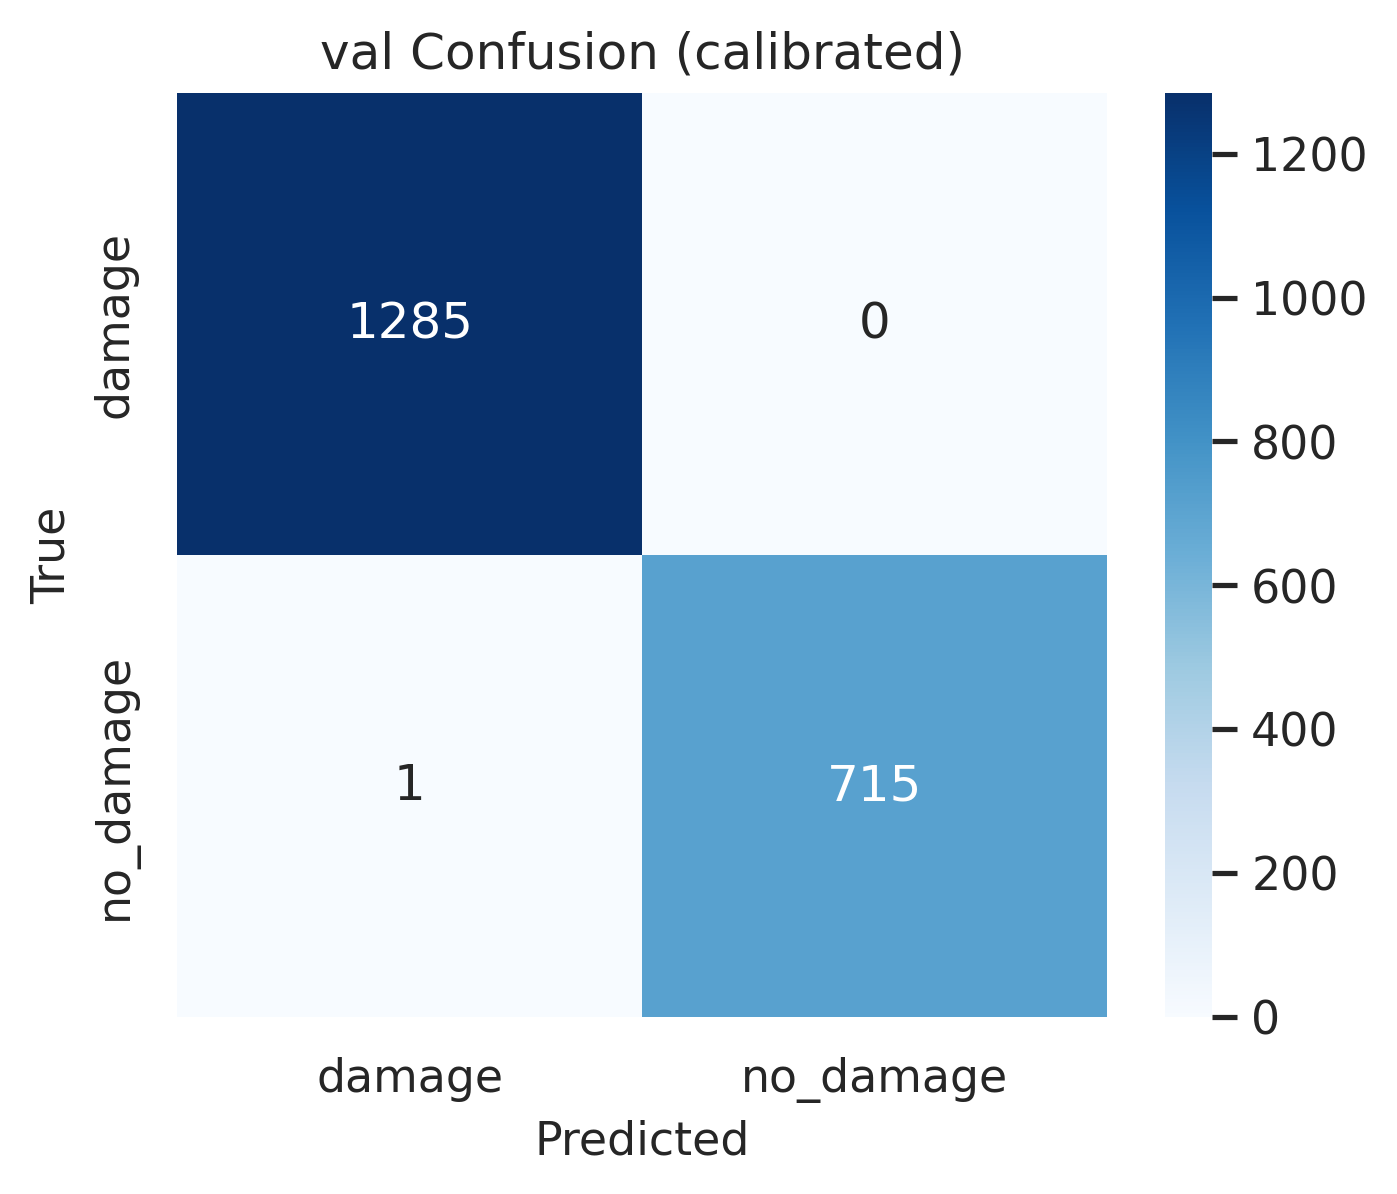

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b2/eval_plots/eval_val_calibrated_score_hist.pdf


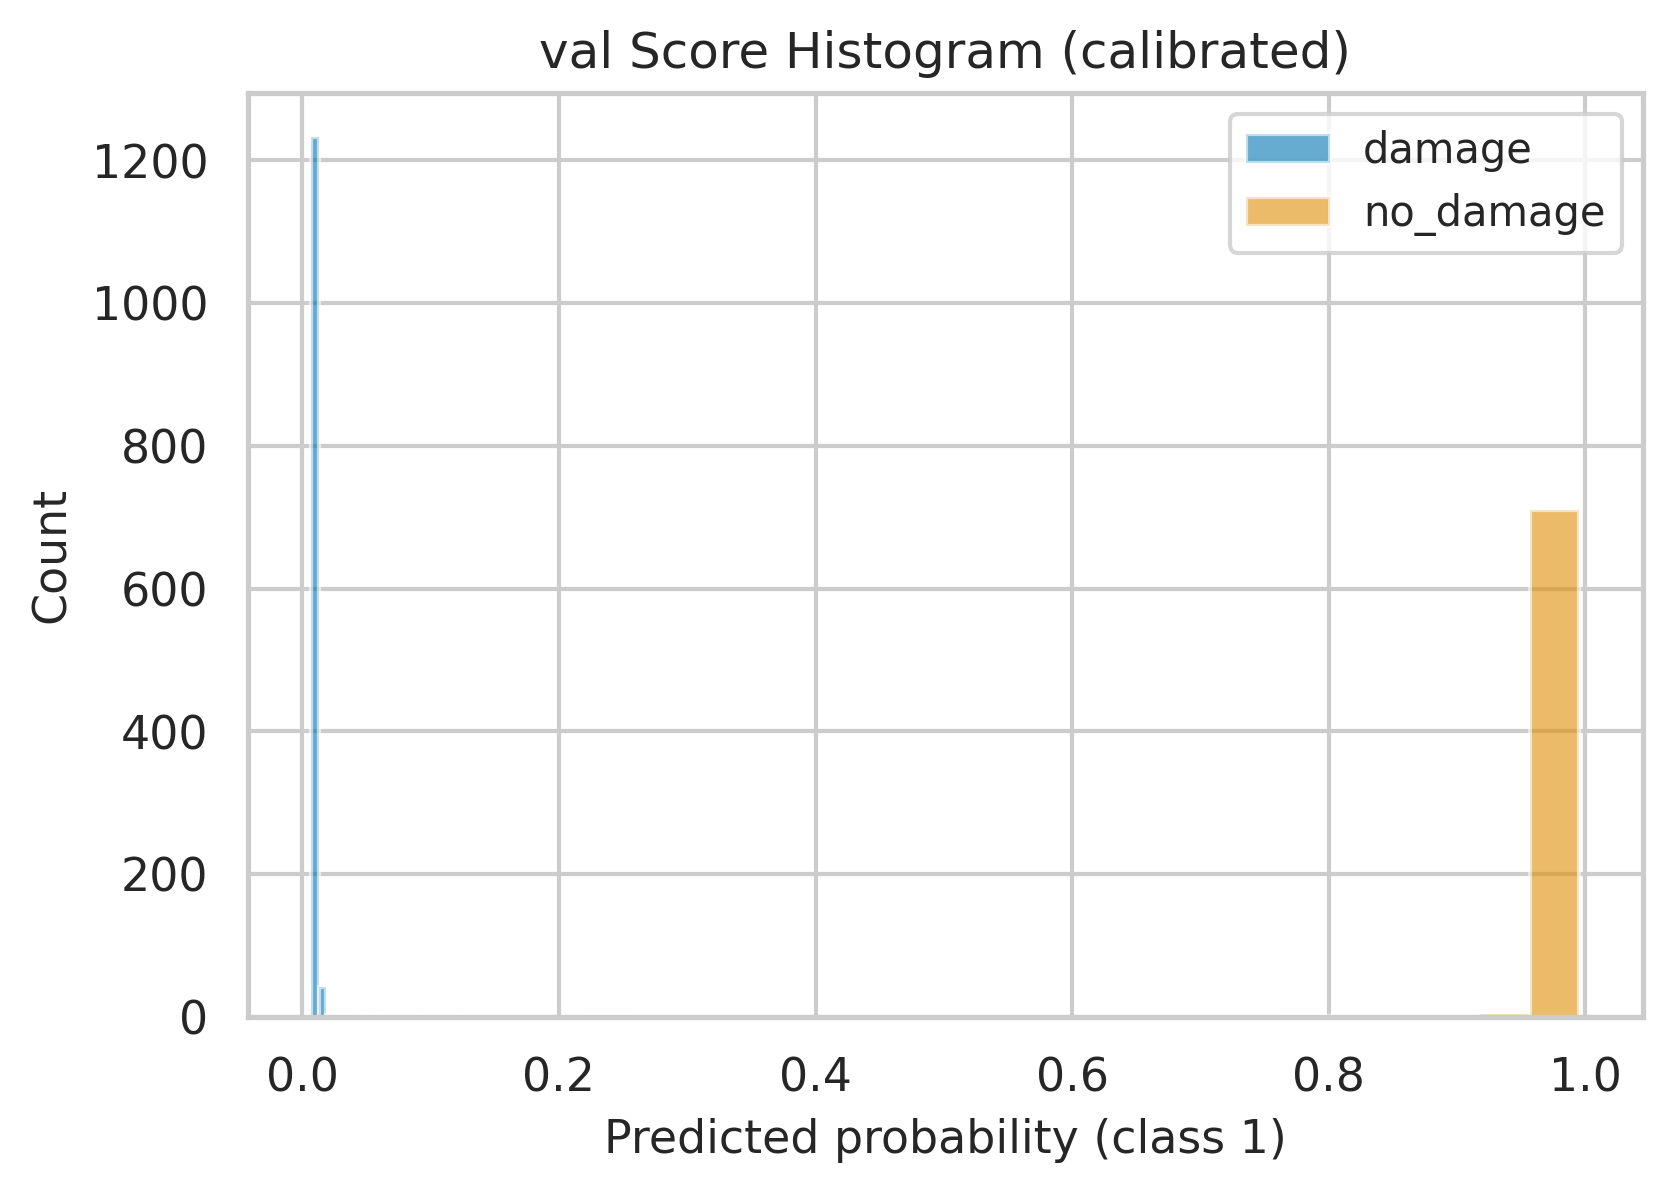

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b2/eval_plots/eval_val_calibrated_reliability.pdf


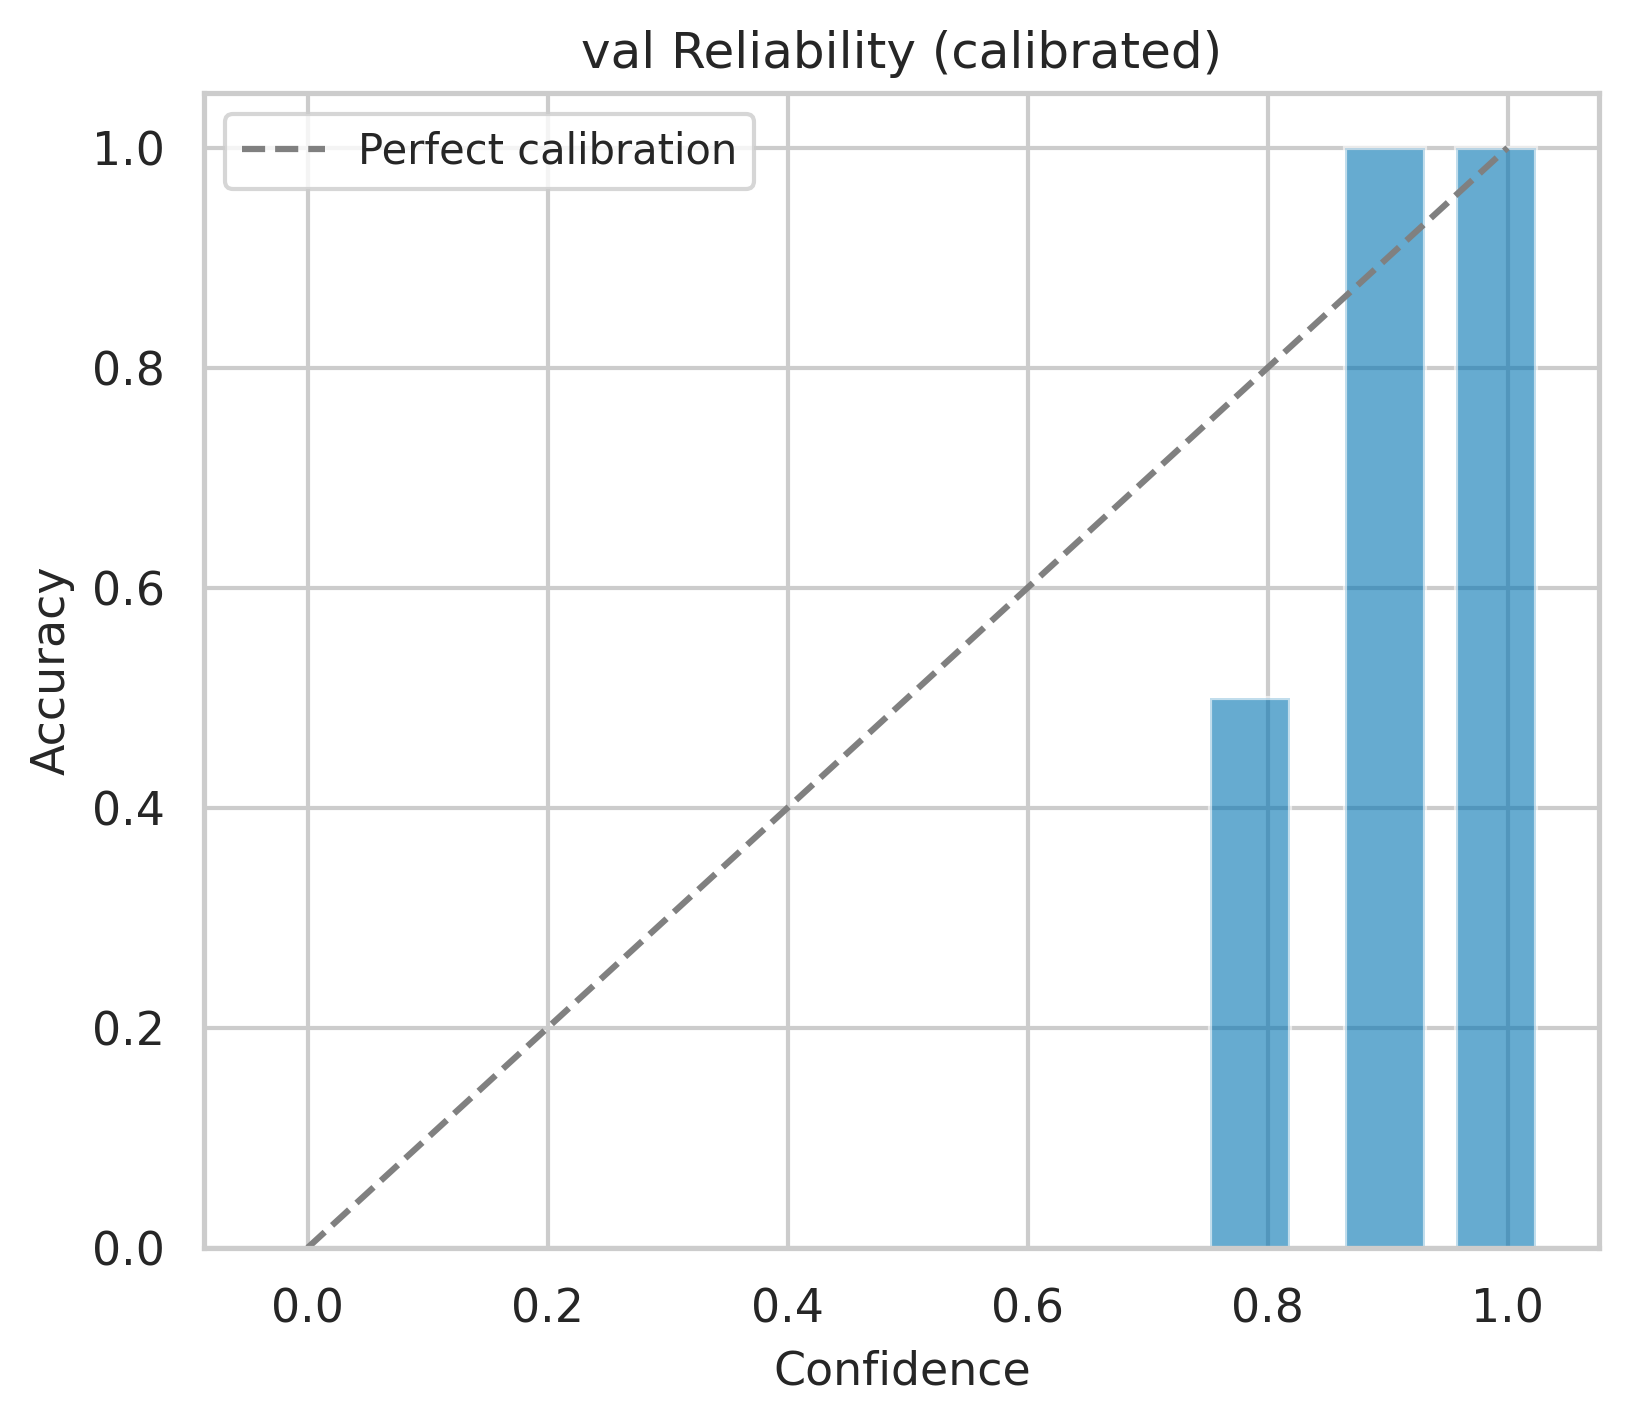

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b2/eval_plots/eval_test_calibrated_confusion.pdf


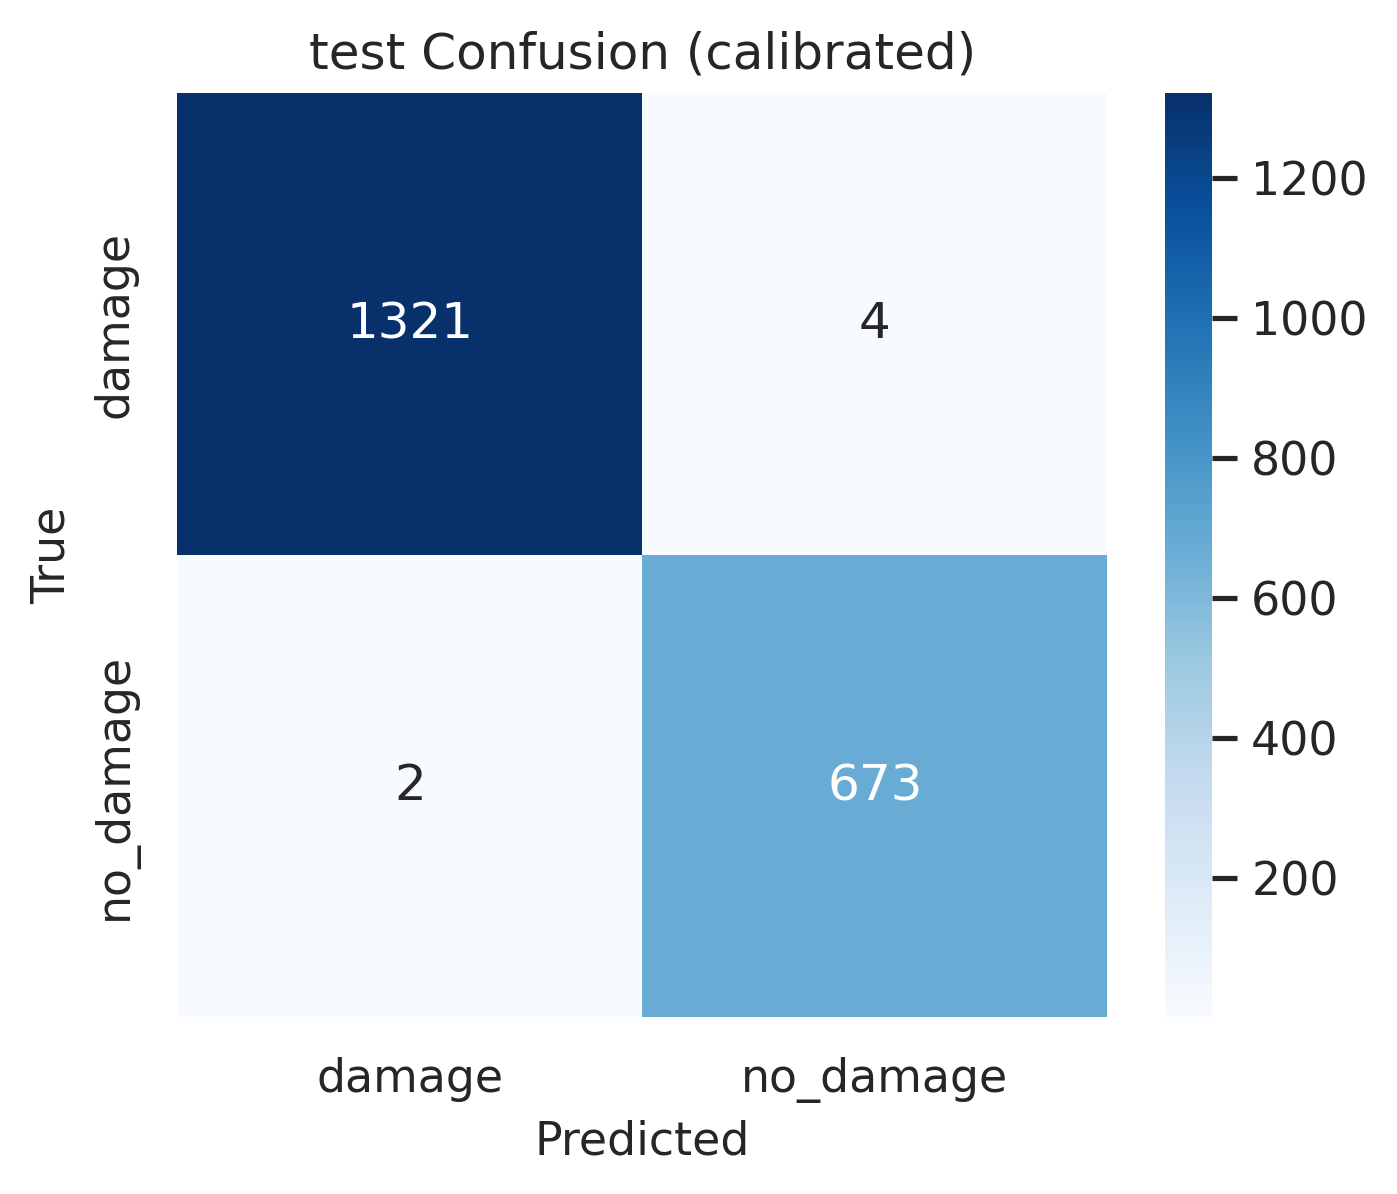

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b2/eval_plots/eval_test_calibrated_score_hist.pdf


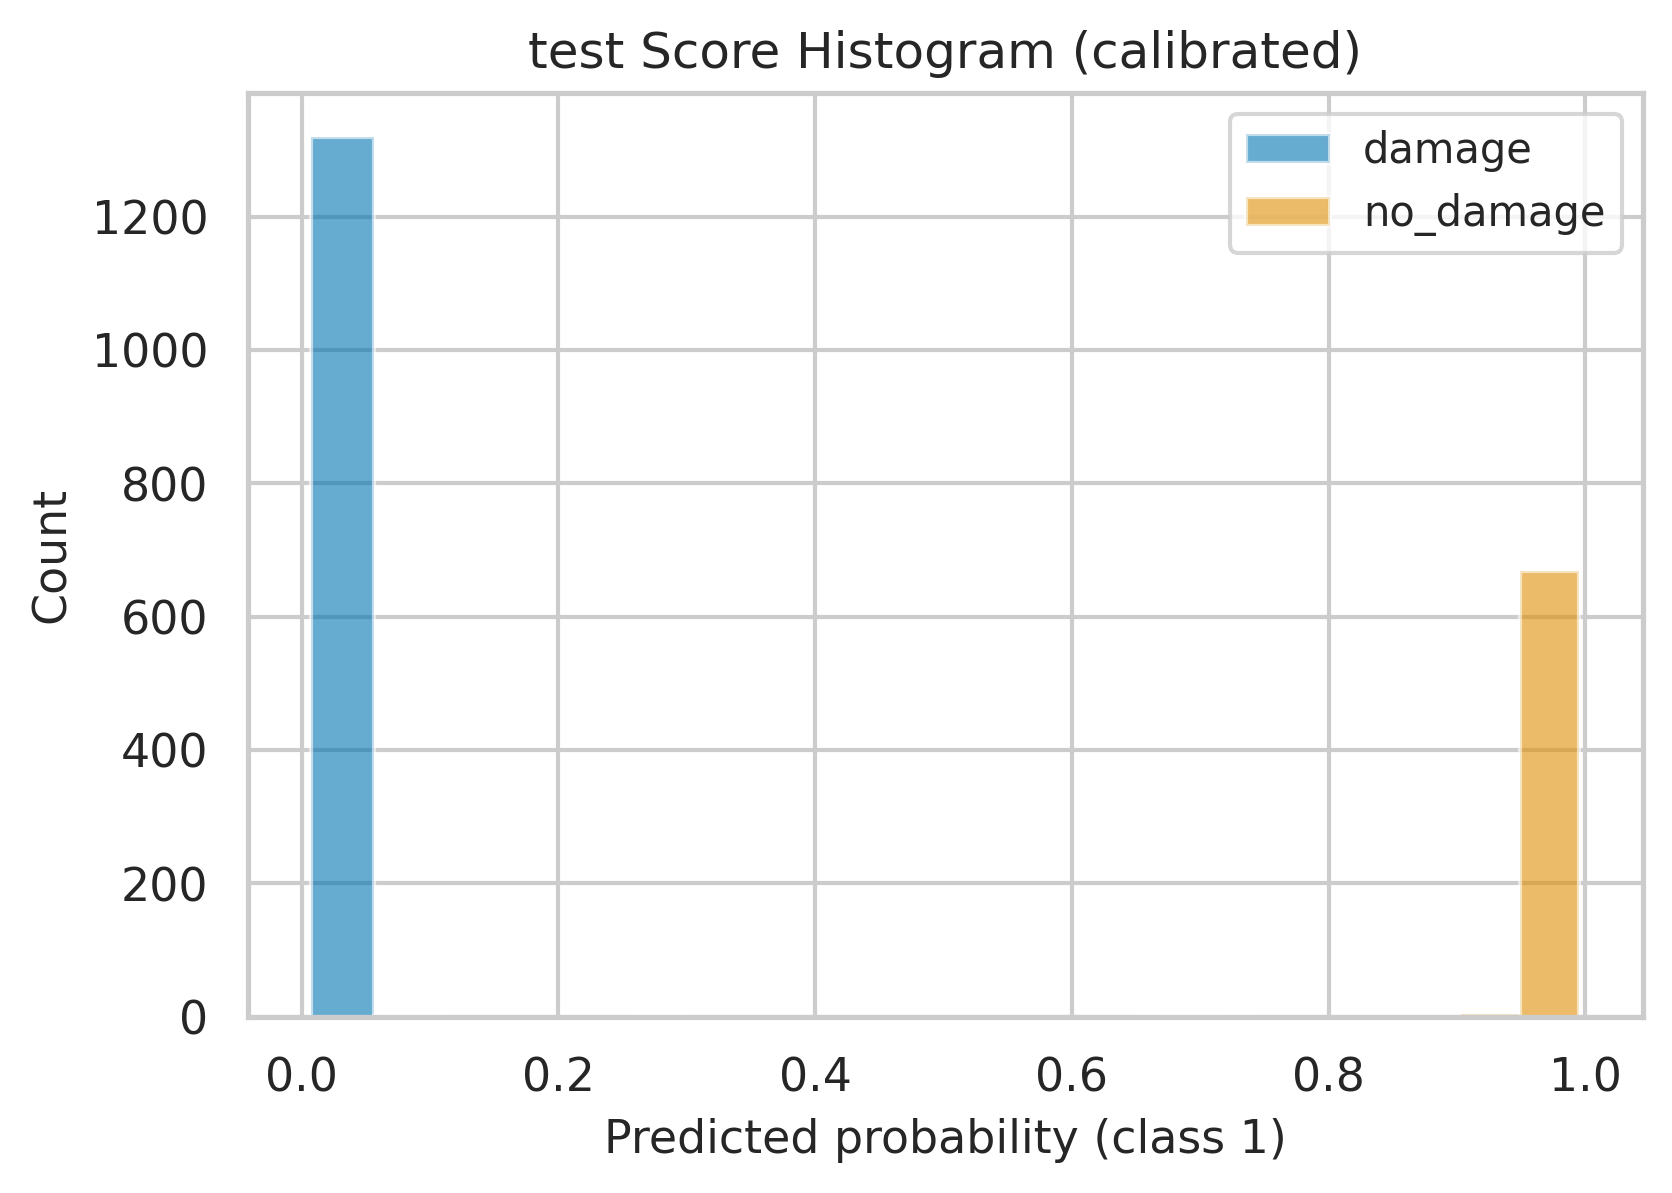

Saved figure to ../training_runs/resampled_20251206-154401_efficientnet_b2/eval_plots/eval_test_calibrated_reliability.pdf


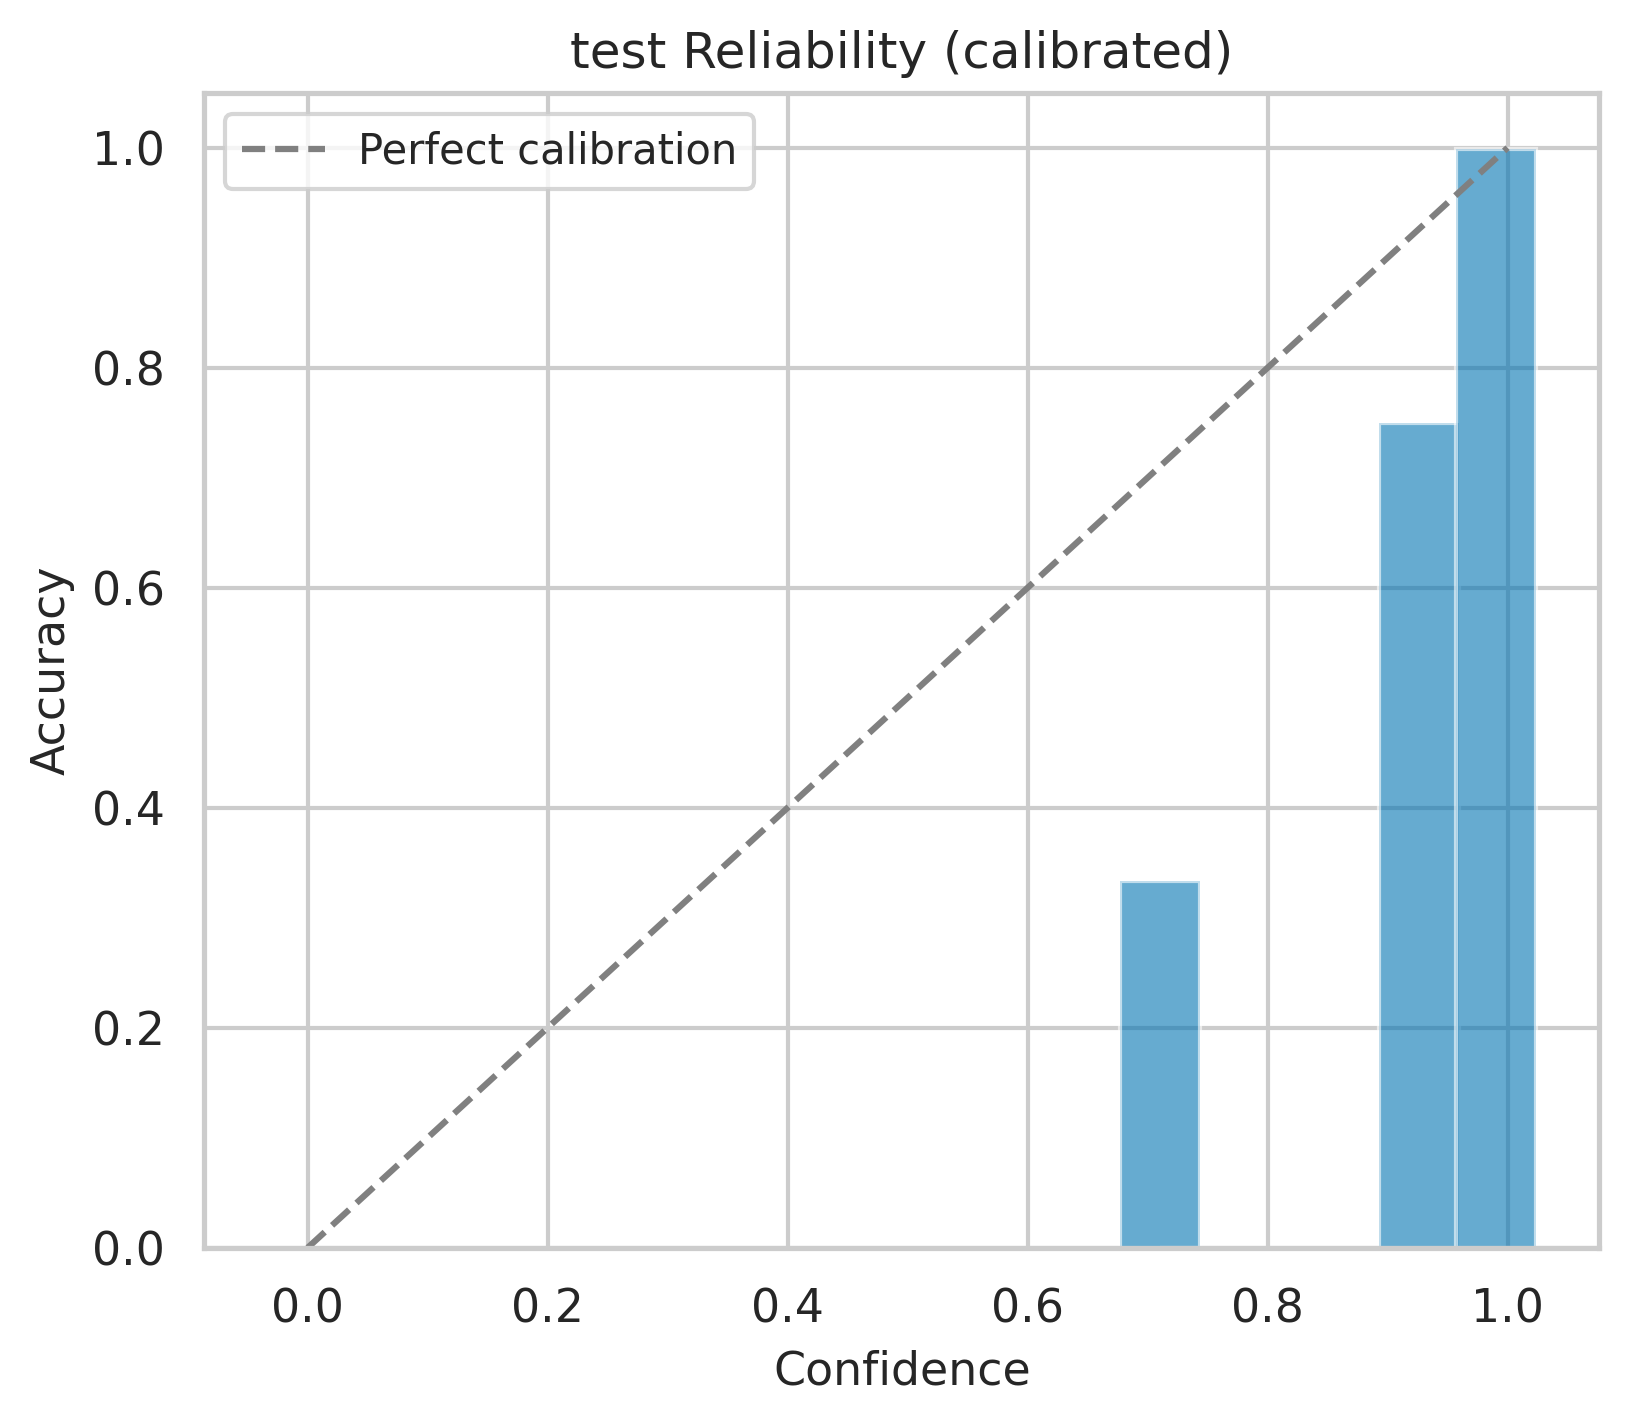

Saved eval metrics to ../training_runs/resampled_20251206-154401_efficientnet_b2/eval_metrics.json
Fitted temperature: 0.7823
Test metrics (raw): {'accuracy': 0.997, 'macro_precision': 0.9962899323523928, 'macro_recall': 0.9970090845562544, 'macro_f1': 0.9966481345751623, 'brier': 0.0027864215978107695, 'ece': 0.02581883227825165}
Test metrics (calibrated): {'accuracy': 0.997, 'macro_precision': 0.9962899323523928, 'macro_recall': 0.9970090845562544, 'macro_f1': 0.9966481345751623, 'brier': 0.002333307663864846, 'ece': 0.010034853786230076}


In [9]:
efficientnet_b2_eval = evaluate_run("efficientnet_b2")

In [10]:
convnext_tiny_eval = evaluate_run("convnext_tiny")

FileNotFoundError: Checkpoint not found: ../training_runs/resampled_20251206-154401_convnext_tiny/artifacts/checkpoints/best.pt

In [ ]:
convnext_small_eval = evaluate_run("convnext_small")

In [ ]:
custom_cnn_eval = evaluate_run("custom_cnn")